# Experiment 6: Shared-tree, divergent-linearization ε design

Successor to Experiment 5 (Allen-Zhu paired CFGs). Experiment 5 was diagnosed
as measuring the wrong quantity and lacking shared semantics between the two
grammars. This notebook implements the redesign: **one shared abstract CFG**
(the latent "meaning," same tree distribution for every language) realized on
the surface by three different child-order linearizations:

- **L_A (anchor, 70%)** — identity order (standard left-to-right).
- **L_B (15%)** — reversal only at levels {4, 5} (partial / irregular).
- **L_C (15%)** — full reversal at every level (equivalent to reading L_A backwards).

**Goal for this pass: just see ε separation** (ε_A ≈ 0, ε_B/ε_C > 0 at low
capacity, shrinking with capacity). No prediction is being made about whether
ε_B or ε_C is larger — L_B's partial reversal is irregular in a way that could
plausibly cost *more* than L_C's full (but regular) reversal, so the ordering
is left as an open empirical question, not a target to hit.

**Run order:** Gates 1/3/4/6 (cheap, on paper or small-scale) must pass before
any full capacity sweep is worth running. This notebook builds and smoke-tests
every piece at toy scale (CPU, a few hundred steps) to confirm the pipeline is
correct end-to-end. The toy-scale numbers below are **not** real gate results —
they confirm the code runs and the logic is sound, nothing more. The real
gates need real scale (thousands of trees, thousands of steps) on `optimus`.


## 0. Device setup

`CUDA_VISIBLE_DEVICES` is set before any CUDA import, per the project's
compute setup (GPU id 0 on `optimus`). Falls back to CPU automatically if no
GPU is visible (e.g. running this notebook locally to just check the gates).

Also sets up `autocast_ctx()`, a bf16 autocast context used by every
training/eval forward pass below (enabled only on CUDA) — carrying forward
the bf16 handling from Experiment 5's infrastructure rather than training in
plain fp32.


In [1]:
import os
import torch
DEVICE = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(f"using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  {torch.cuda.get_device_name(2)}")

# bf16 autocast for the forward/loss pass -- matches the bf16 handling carried
# forward from Experiment 5's infrastructure. Enabled only on CUDA (bf16
# autocast on CPU is a correctness no-op we don't need and don't want to pay
# for in the toy smoke tests); every training/eval call below wraps its
# forward pass in this context manager, so flipping devices needs no other
# code change. Model weights and optimizer state stay fp32 -- only the
# forward matmuls run in bf16 -- which is the standard mixed-precision setup
# and keeps AdamW's updates numerically stable.
from contextlib import nullcontext
def autocast_ctx():
    return torch.autocast(device_type=DEVICE.type, dtype=torch.bfloat16) if DEVICE.type == "cuda" else nullcontext()


using device: cuda:2
  NVIDIA H200 NVL


## 1. Config

Single place for every knob that later cells depend on. Change here, not
inline elsewhere.


In [2]:
# ============================== CONFIG ======================================
LEVELS = 6            # number of NT layers (root=level 1 ... level 6); terminals at level 7
NT_SIZE = 4            # symbols per NT layer, levels 2..6 (root layer has size 1)
TERM_SIZE = 4          # number of terminal symbols
MIN_DEGREE = 2         # min number of production rules per NT symbol
MAX_DEGREE = 4         # max number of production rules per NT symbol
RULE_LEN_CHOICES = [2, 3]   # rule RHS lengths (cfg9-style; add 1 later if you want unbalanced trees)

# Linearizations: which parent levels get their children reversed.
# L_C is the full reverse of L_A by construction (reversing every level of a
# tree traversal reverses the whole terminal string) -- this is expected and
# checked below, not a bug.
LANGS = {
    "L_A": set(),                          # identity
    "L_B": {4, 5},                         # partial reversal (irregular)
    "L_C": set(range(1, LEVELS + 1)),      # full reversal (regular, = reverse(L_A))
}
LANG_NAMES = list(LANGS.keys())
MIX = {"L_A": 0.70, "L_B": 0.15, "L_C": 0.15}   # training-data mix for the joint condition

# Vocab layout: terminals [0, TERM_SIZE), then one BOS-lang tag per language.
VOCAB_SIZE = TERM_SIZE + len(LANG_NAMES)
BOS_OFFSET = TERM_SIZE
BOS = {name: BOS_OFFSET + i for i, name in enumerate(LANG_NAMES)}

def round_to_valid_n_embd(x, n_head):
    """Rotary embeddings need head_dim = n_embd/n_head to be EVEN, not just
    an integer. Rounds x to the nearest multiple of 2*n_head (minimum one
    unit). With n_head=12 (the real config), valid n_embd values are
    multiples of 24: 24, 48, 72, 96, 120, 144, 168, 192, ..., 384, ..., 768."""
    unit = 2 * n_head
    return max(unit, round(x / unit) * unit)
# ==============================================================================


## 2. Grammar builder and tree sampler

Layered cfg9-style CFG: symbols are `(level, index)` pairs; level 1 is the
root, levels 2-6 are NTs, level 7 (implicit) is terminals. Each NT gets a
random degree (2-4 rules), each rule RHS has length 2 or 3.

**Gate 1's job is to catch it if this grammar (combined with a given
linearization) isn't unambiguous enough** — rather than hand-proving
unambiguity in advance, we sample many trees and check for string collisions
directly (see Gate 1 below), matching how the design doc specifies the gate.


In [3]:
import random

def build_grammar(seed):
    """Returns (rules, symbols_by_level). rules[symbol] is a list of RHS tuples,
    in the CANONICAL (L_A / identity) child order -- linearize() reorders at
    read time per language, it never touches the grammar itself."""
    rng = random.Random(seed)
    symbols_by_level = {1: [(1, 0)]}
    for l in range(2, LEVELS + 1):
        symbols_by_level[l] = [(l, i) for i in range(NT_SIZE)]
    terminals = list(range(TERM_SIZE))

    from collections import defaultdict
    rules = defaultdict(list)
    for l in range(1, LEVELS + 1):
        child_level = l + 1
        child_symbols = terminals if child_level == LEVELS + 1 else symbols_by_level[child_level]
        for sym in symbols_by_level[l]:
            degree = rng.randint(MIN_DEGREE, MAX_DEGREE)
            seen = set()
            tries = 0
            while len(rules[sym]) < degree and tries < 200:
                tries += 1
                rule_len = rng.choice(RULE_LEN_CHOICES)
                rhs = tuple(rng.choice(child_symbols) for _ in range(rule_len))
                if rhs in seen:
                    continue
                seen.add(rhs)
                rules[sym].append(rhs)
    return rules, symbols_by_level

def sample_tree(rules, rng, symbol=(1, 0), level=1):
    """Nested-tuple tree: (symbol, [child_trees...]), terminals as bare ints."""
    rhs = rng.choice(rules[symbol])
    children = []
    for child_sym in rhs:
        if level == LEVELS:
            children.append(child_sym)  # terminal, bare int
        else:
            children.append(sample_tree(rules, rng, symbol=child_sym, level=level + 1))
    return (symbol, children)

def linearize(node, reverse_levels):
    """node: bare terminal int, or (symbol=(level,idx), children=[...]).
    reverse_levels: set of parent levels whose children get reversed."""
    if isinstance(node, int):
        return [node]
    (level, idx), children = node
    order = list(reversed(children)) if level in reverse_levels else children
    tokens = []
    for c in order:
        tokens.extend(linearize(c, reverse_levels))
    return tokens

def permute_grammar(rules, symbols_by_level, seed):
    """Builds a DISJOINT-CONTROL grammar by reassigning which symbol owns
    which existing rule-set, rather than drawing an independent random
    grammar. An independently-drawn grammar can differ in intrinsic
    difficulty from the shared grammar purely by luck of the random degree/
    rule-length draws (confirmed empirically: two independent seeds showed a
    ~20% CE gap under identical linearization, at real scale). Permuting
    preserves the exact multiset of rule lengths, branching factors, and
    degree distribution -- only WHICH symbol gets WHICH rule-set changes --
    so intrinsic difficulty matches by construction, not by chance. Root
    (level 1, one symbol) is left unchanged; nothing to permute there."""
    rng = random.Random(seed)
    new_rules = {(1, 0): rules[(1, 0)]}
    for level, syms in symbols_by_level.items():
        if level == 1:
            continue
        shuffled = syms[:]
        rng.shuffle(shuffled)
        for original_sym, new_owner in zip(syms, shuffled):
            new_rules[new_owner] = rules[original_sym]
    return new_rules

# smoke test
rules, symbols_by_level = build_grammar(seed=0)
tree = sample_tree(rules, random.Random(1))
a = linearize(tree, LANGS["L_A"])
c = linearize(tree, LANGS["L_C"])
print(f"sample tree yields {len(a)} terminal tokens under L_A")
print("L_C == reverse(L_A)? ", c == list(reversed(a)), " (expected True -- confirms full reversal is exact)")


sample tree yields 225 terminal tokens under L_A
L_C == reverse(L_A)?  True  (expected True -- confirms full reversal is exact)


### Why the disjoint control uses `permute_grammar`, not an independent draw

An earlier version of this control built each language's disjoint grammar
with an independent `build_grammar(seed=100+i)` call. A real-scale parity
check caught this: two of the three independently-drawn grammars turned out
~20% easier than the shared grammar under identical linearization — pure
luck of the random degree/rule-length draw, nothing to do with sharing. That
gap alone was enough to produce spurious positive `eps_pure` values that
looked like a real effect but weren't.

`permute_grammar` fixes this by reassigning which symbol owns which
existing rule-set from the SAME shared grammar, rather than drawing a new
one — same rule-length mix, same branching factor, same degree
distribution, just relabeled. Re-running the parity check with this control
brought the gap down to ≤4.4% across all three languages.


## 3. Gate 1 — within-language string collisions

Sample many trees, linearize under each language, confirm zero collisions
(two *different* sampled trees producing the identical terminal string) within
a language. Cross-language collisions are fine (the BOS tag disambiguates).

L_C should pass trivially if L_A does (exact reversal preserves uniqueness).
**L_B is the one to actually watch** — partial reversal could in principle
create accidental local ambiguity that the identity/full-reversal orders
don't have. Run this at real scale (≥10K trees) before trusting it.


In [4]:
def gate1_collision_check(trees, langs=LANGS):
    results = {}
    for name, revset in langs.items():
        seen = set()
        collisions = 0
        for t in trees:
            s = tuple(linearize(t, revset))
            if s in seen:
                collisions += 1
            seen.add(s)
        results[name] = {"n_trees": len(trees), "n_unique_strings": len(seen), "collisions": collisions}
    return results

# --- smoke test at 10K trees (cheap enough to run for real, not just as a toy check) ---
rng = random.Random(42)
trees_10k = [sample_tree(rules, rng) for _ in range(10_000)]
gate1_results = gate1_collision_check(trees_10k)
for name, r in gate1_results.items():
    status = "PASS" if r["collisions"] == 0 else "FAIL"
    print(f"[{status}] {name}: {r}")


[PASS] L_A: {'n_trees': 10000, 'n_unique_strings': 10000, 'collisions': 0}
[PASS] L_B: {'n_trees': 10000, 'n_unique_strings': 10000, 'collisions': 0}
[PASS] L_C: {'n_trees': 10000, 'n_unique_strings': 10000, 'collisions': 0}


## 4. Gate 3 — n-gram entropy parity

Per-language n-gram cross-entropy (in-sample floor, evaluated on the same
corpus it's estimated from — this is a quick sanity diagnostic, not a
held-out generalization measure). Unigram entropy is identical by
construction (linearization only reorders tokens, never changes the terminal
multiset). Bigram/trigram floors should stay close across languages; a big
gap would mean one language got accidentally "easier" from the reordering.


In [5]:
import math
from collections import defaultdict, Counter

def ngram_entropy(strings, n):
    counts = defaultdict(Counter)
    for s in strings:
        padded = (0,) * (n - 1) + tuple(s)
        for i in range(n - 1, len(padded)):
            counts[padded[i - n + 1:i]][padded[i]] += 1
    bits, total = 0.0, 0
    for s in strings:
        padded = (0,) * (n - 1) + tuple(s)
        for i in range(n - 1, len(padded)):
            ctx, tok = padded[i - n + 1:i], padded[i]
            ctx_counts = counts[ctx]
            p = ctx_counts[tok] / sum(ctx_counts.values())
            bits += -math.log2(p)
            total += 1
    return bits / total

def gate3_ngram_parity(trees, langs=LANGS, n_values=(1, 2, 3)):
    results = {}
    for name, revset in langs.items():
        strings = [linearize(t, revset) for t in trees]
        results[name] = {f"{n}-gram_bits": ngram_entropy(strings, n) for n in n_values}
    return results

gate3_results = gate3_ngram_parity(trees_10k)
for name, r in gate3_results.items():
    print(f"{name}: {r}")


L_A: {'1-gram_bits': 1.7933056915351797, '2-gram_bits': 1.6867738415742966, '3-gram_bits': 1.5474959050393025}
L_B: {'1-gram_bits': 1.79330569153518, '2-gram_bits': 1.690825024845867, '3-gram_bits': 1.5590732344944018}
L_C: {'1-gram_bits': 1.7933056915351773, '2-gram_bits': 1.6865956791207082, '3-gram_bits': 1.5475885331253267}


## 5. Model — minimal decoder-only transformer with rotary attention

Allen-Zhu's Result 1-3: rotary/relative attention is necessary for learning
these CFGs; absolute-position GPT underperforms even uniform attention. In
the real sweep this is GPT-2-scale (12 layers, 12 heads, `n_embd` swept as
the capacity knob). Kept small here (`n_layer=2, n_head=2`) purely for CPU
smoke-testing the pipeline — **not the config to run gates or the real sweep
with.**


In [6]:
import torch.nn as nn
import torch.nn.functional as F
# torch and DEVICE already set up in the Device setup cell above.

def rotate_half(x):
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat((-x2, x1), dim=-1)

def apply_rotary(q, k, cos, sin):
    return (q * cos) + (rotate_half(q) * sin), (k * cos) + (rotate_half(k) * sin)

class RotaryEmbedding(nn.Module):
    def __init__(self, dim, max_seq_len=1024, base=10000):
        super().__init__()
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        t = torch.arange(max_seq_len).float()
        freqs = torch.einsum("i,j->ij", t, inv_freq)
        emb = torch.cat((freqs, freqs), dim=-1)
        self.register_buffer("cos", emb.cos()[None, None, :, :], persistent=False)
        self.register_buffer("sin", emb.sin()[None, None, :, :], persistent=False)

    def forward(self, seq_len):
        return self.cos[:, :, :seq_len, :], self.sin[:, :, :seq_len, :]

class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, max_seq_len):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        self.qkv = nn.Linear(n_embd, 3 * n_embd)
        self.proj = nn.Linear(n_embd, n_embd)
        self.rotary = RotaryEmbedding(self.head_dim, max_seq_len)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x).view(B, T, 3, self.n_head, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        cos, sin = self.rotary(T)
        q, k = apply_rotary(q, k, cos.to(x.dtype), sin.to(x.dtype))
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(y)

class Block(nn.Module):
    def __init__(self, n_embd, n_head, max_seq_len):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, max_seq_len)
        self.ln2 = nn.LayerNorm(n_embd)
        self.mlp = nn.Sequential(nn.Linear(n_embd, 4 * n_embd), nn.GELU(), nn.Linear(4 * n_embd, n_embd))

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

class TinyRotaryGPT(nn.Module):
    """d_model (n_embd) is the swept capacity knob; n_layer/n_head fixed
    (12/12 in the real GPT-2-scale sweep)."""
    def __init__(self, vocab_size, n_embd, n_layer=12, n_head=12, max_seq_len=512):
        super().__init__()
        assert n_embd % n_head == 0, "n_embd must be divisible by n_head"
        assert (n_embd // n_head) % 2 == 0, (
            f"head_dim (n_embd/n_head = {n_embd}/{n_head} = {n_embd // n_head}) must be EVEN "
            "for rotary embeddings -- pick n_embd as a multiple of 2*n_head, or use "
            "round_to_valid_n_embd() from the config cell."
        )
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.blocks = nn.ModuleList([Block(n_embd, n_head, max_seq_len) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size, bias=False)

    def forward(self, idx, targets=None):
        x = self.tok_emb(idx)
        for blk in self.blocks:
            x = blk(x)
        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        return logits, loss

# smoke test
torch.manual_seed(0)
_m = TinyRotaryGPT(VOCAB_SIZE, n_embd=8, n_layer=2, n_head=2, max_seq_len=64).to(DEVICE)
_idx = torch.randint(0, VOCAB_SIZE, (4, 32), device=DEVICE)
_logits, _ = _m(_idx, _idx)
print(f"forward pass OK on {DEVICE}, output shape:", _logits.shape)


forward pass OK on cuda:2, output shape: torch.Size([4, 32, 7])


## 6. Monolingual dataset builder + Gate 4 (learnability parity)

Sample trees, linearize under ONE language, prepend its BOS tag, concatenate,
chunk into fixed-length sequences. Gate 4 trains a monolingual model per
language at one mid capacity and checks converged loss is close (~10%)
across languages — a big gap would mean one language is intrinsically
harder, confounding any later ε reading.

**The numbers below are a toy-scale smoke test (300 steps, tiny model) to
confirm the code is correct — not a real Gate 4 result.** Per the
optimization-speed trap already hit in the SVO/SOV Chunk A diagnostic
(narrow/undertrained models can look "harder" for optimization reasons
unrelated to capacity), the real gate needs a proper step budget and a
loss-convergence check, not a fixed small step count, before trusting any
cross-language gap.


In [7]:
def make_monolingual_dataset(rules, lang_name, n_trees, seed, seq_len):
    rng = random.Random(seed)
    revset = LANGS[lang_name]
    stream = []
    for _ in range(n_trees):
        tree = sample_tree(rules, rng)
        stream.append(BOS[lang_name])
        stream.extend(linearize(tree, revset))
    stream = torch.tensor(stream, dtype=torch.long)
    n_chunks = len(stream) // (seq_len + 1)
    return stream[: n_chunks * (seq_len + 1)].view(n_chunks, seq_len + 1)

def train_monolingual(rules, lang_name, n_embd, steps, seed, seq_len=64, batch_size=32, lr=3e-3, device=DEVICE):
    torch.manual_seed(seed)
    data = make_monolingual_dataset(rules, lang_name, n_trees=4000, seed=seed, seq_len=seq_len).to(device)
    model = TinyRotaryGPT(VOCAB_SIZE, n_embd=n_embd, n_layer=2, n_head=2, max_seq_len=seq_len + 1).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    n = data.shape[0]
    losses = []
    for step in range(steps):
        idx = torch.randint(0, n, (batch_size,), device=data.device)
        batch = data[idx]
        x, y = batch[:, :-1], batch[:, 1:]
        with autocast_ctx():
            _, loss = model(x, y)
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    tail = losses[-max(1, steps // 10):]
    return sum(tail) / len(tail), losses

# --- SMOKE TEST ONLY: n_embd=16, 300 steps. Bump both substantially for the real gate. ---
print(f"Gate 4 smoke test on {DEVICE} (toy scale -- code check only, NOT a real capacity claim)")
gate4_results = {}
for lang_name in LANG_NAMES:
    final_loss, losses = train_monolingual(rules, lang_name, n_embd=16, steps=300, seed=7)
    gate4_results[lang_name] = final_loss
    print(f"  {lang_name}: final_loss={final_loss:.4f}  (start {losses[0]:.3f} -> end {losses[-1]:.3f})")

vals = list(gate4_results.values())
spread = (max(vals) - min(vals)) / min(vals) * 100
print(f"relative spread: {spread:.1f}% (real gate wants <=~10% at proper scale/steps)")


Gate 4 smoke test on cuda:2 (toy scale -- code check only, NOT a real capacity claim)
  L_A: final_loss=1.0873  (start 2.295 -> end 1.095)
  L_B: final_loss=1.0788  (start 2.297 -> end 1.096)
  L_C: final_loss=1.0902  (start 2.353 -> end 1.079)
relative spread: 1.1% (real gate wants <=~10% at proper scale/steps)


## 7. Disjoint-grammar control + shared-tree mixed dataset

Two joint-training conditions, same 70/15/15 mix and same total data volume
per language in both:

- **Shared-tree condition**: one grammar, one set of sampled trees; each tree
  is linearized under whichever language it's assigned to. This is where ε
  (a genuine representational-conflict cost) is expected to appear.
- **Disjoint-grammar control**: each language gets its OWN grammar built by
  permuting which symbol owns which rule-set from the same shared grammar
  (`permute_grammar`, defined in section 2) — same rule-length mix, same
  branching factor, same degree distribution, just relabeled. Same mix
  ratio, same terminal vocab, same per-language data volume — but no shared
  tree, so there's no shared-semantics conflict to measure. (An earlier
  version drew each disjoint grammar independently at random, which turned
  out to differ from the shared grammar's intrinsic difficulty by up to
  ~20% purely by luck of the draw — see the note after section 2.)

**ε_pure = CE_L(shared) − CE_L(disjoint)**, evaluated per language. Using the
disjoint control as the baseline (rather than a monolingual ceiling) cancels
the data-volume confound: L_B/L_C get the same 15%-of-mix exposure in both
conditions, so any remaining gap is attributable to the shared tree, not to
seeing less data.


In [8]:
def make_shared_tree_mix(rules, n_trees, seed, seq_len, mix=MIX):
    rng = random.Random(seed)
    stream = []
    for _ in range(n_trees):
        lang = rng.choices(LANG_NAMES, weights=[mix[n] for n in LANG_NAMES])[0]
        tree = sample_tree(rules, rng)
        stream.append(BOS[lang])
        stream.extend(linearize(tree, LANGS[lang]))
    stream = torch.tensor(stream, dtype=torch.long)
    n_chunks = len(stream) // (seq_len + 1)
    return stream[: n_chunks * (seq_len + 1)].view(n_chunks, seq_len + 1)

def make_disjoint_mix(grammars_by_lang, n_trees, seed, seq_len, mix=MIX):
    rng = random.Random(seed)
    stream = []
    for _ in range(n_trees):
        lang = rng.choices(LANG_NAMES, weights=[mix[n] for n in LANG_NAMES])[0]
        tree = sample_tree(grammars_by_lang[lang], rng)
        stream.append(BOS[lang])
        stream.extend(linearize(tree, LANGS[lang]))
    stream = torch.tensor(stream, dtype=torch.long)
    n_chunks = len(stream) // (seq_len + 1)
    return stream[: n_chunks * (seq_len + 1)].view(n_chunks, seq_len + 1)

def per_language_loss(model, data, lang_name, device=DEVICE):
    mask = data[:, 0] == BOS[lang_name]
    subset = data[mask]
    if subset.shape[0] == 0:
        return None
    x, y = subset[:, :-1].to(device), subset[:, 1:].to(device)
    with torch.no_grad(), autocast_ctx():
        _, loss = model(x, y)
    return loss.item()

def train_joint(data, n_embd, steps, seed, seq_len=64, batch_size=32, lr=3e-3, device=DEVICE):
    torch.manual_seed(seed)
    data = data.to(device)
    model = TinyRotaryGPT(VOCAB_SIZE, n_embd=n_embd, n_layer=2, n_head=2, max_seq_len=seq_len + 1).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    n = data.shape[0]
    for step in range(steps):
        idx = torch.randint(0, n, (batch_size,), device=data.device)
        batch = data[idx]
        x, y = batch[:, :-1], batch[:, 1:]
        with autocast_ctx():
            _, loss = model(x, y)
        opt.zero_grad(); loss.backward(); opt.step()
    return model

# --- SMOKE TEST ONLY: toy scale, small step count. Real ε reading needs full
#     convergence at each capacity point, per the Gate 4 caveat above. ---
seq_len = 64
disjoint_grammars = {name: permute_grammar(rules, symbols_by_level, seed=200 + i) for i, name in enumerate(LANG_NAMES)}
shared_data = make_shared_tree_mix(rules, n_trees=6000, seed=1, seq_len=seq_len)
disjoint_data = make_disjoint_mix(disjoint_grammars, n_trees=6000, seed=1, seq_len=seq_len)

n_embd = 16
model_shared = train_joint(shared_data, n_embd=n_embd, steps=300, seed=0, seq_len=seq_len)
model_disjoint = train_joint(disjoint_data, n_embd=n_embd, steps=300, seed=0, seq_len=seq_len)

print(f"per-language eps_pure on {DEVICE} = CE(shared) - CE(disjoint)  [TOY SCALE -- code check only]")
print(f"{'lang':6s} {'CE_shared':>10s} {'CE_disjoint':>12s} {'eps_pure':>10s}")
for name in LANG_NAMES:
    l_shared = per_language_loss(model_shared, shared_data, name)
    l_disjoint = per_language_loss(model_disjoint, disjoint_data, name)
    print(f"{name:6s} {l_shared:10.4f} {l_disjoint:12.4f} {l_shared - l_disjoint:10.4f}")
print()
print("NOTE: at this toy step count/scale (300 steps, 2-layer model), any direction or")
print("magnitude seen here can flip with more steps or a different seed -- this cell only")
print("confirms the pipeline runs, it is not a real ε reading. Do not interpret these numbers.")


per-language eps_pure on cuda:2 = CE(shared) - CE(disjoint)  [TOY SCALE -- code check only]
lang    CE_shared  CE_disjoint   eps_pure
L_A        1.0658       1.0815    -0.0157
L_B        1.0635       1.0305     0.0329
L_C        1.1827       1.1646     0.0181

NOTE: at this toy step count/scale (300 steps, 2-layer model), any direction or
magnitude seen here can flip with more steps or a different seed -- this cell only
confirms the pipeline runs, it is not a real ε reading. Do not interpret these numbers.


## 8. Gate 6 — tag-gaming diagnostic

Every prior ε design that included an explicit language tag eventually traced
its failure to the tag enabling trivial separation (Experiment 3's original
ε line: (tag, quantifier, noun-class) → override lookup). Here the argument
for why the tag is safe is that parsing a DP-hard grammar is expensive, so
tag-conditional gating of two full parsers should cost more than one shared
parser plus cheap routing — but this needs checking, not assuming.

**Check:** joint training (A+C, with BOS tag) vs. two independently-trained
monolinguals, each at HALF the joint model's capacity (so total capacity
matches). If the joint model's per-language loss is comparable to or better
than the halved monolinguals, the tag isn't doing all the work by cheaply
gating two disjoint circuits. If the halved monolinguals clearly win, the
joint model is failing to share -- which could mean the tag is enabling an
easy escape into per-language routing instead of a real shared computation.


In [9]:
def gate6_tag_gaming_check(rules, n_embd_joint, steps, seed, seq_len=64, pair=("L_A", "L_C")):
    # joint: both languages, full n_embd_joint, WITH BOS tag (tag is baked into
    # the vocab/BOS scheme already, so "with tag" is just training on the mix)
    mix_pair = {pair[0]: 0.5, pair[1]: 0.5}
    joint_data = make_shared_tree_mix(rules, n_trees=4000, seed=seed, seq_len=seq_len, mix={
        **{n: 0.0 for n in LANG_NAMES}, **mix_pair
    })
    joint_model = train_joint(joint_data, n_embd=n_embd_joint, steps=steps, seed=seed, seq_len=seq_len)

    # halved monolinguals: each at n_embd_joint // 2 (so total capacity matches joint)
    n_embd_half = max(2, (n_embd_joint // 2) - (n_embd_joint // 2) % 2)  # keep even for n_head=2
    mono_losses = {}
    for lang_name in pair:
        final_loss, _ = train_monolingual(rules, lang_name, n_embd=n_embd_half, steps=steps, seed=seed, seq_len=seq_len)
        mono_losses[lang_name] = final_loss

    print(f"joint (n_embd={n_embd_joint}, tag) vs halved monolinguals (n_embd={n_embd_half} each):")
    for lang_name in pair:
        joint_loss = per_language_loss(joint_model, joint_data, lang_name)
        print(f"  {lang_name}: joint={joint_loss:.4f}  halved_mono={mono_losses[lang_name]:.4f}  "
              f"{'joint <= halved (tag OK so far)' if joint_loss <= mono_losses[lang_name] else 'halved wins (investigate tag-gaming)'}")

# --- SMOKE TEST ONLY ---
gate6_tag_gaming_check(rules, n_embd_joint=16, steps=300, seed=3)


joint (n_embd=16, tag) vs halved monolinguals (n_embd=8 each):
  L_A: joint=1.1023  halved_mono=1.1605  joint <= halved (tag OK so far)
  L_C: joint=1.1222  halved_mono=1.1718  joint <= halved (tag OK so far)


## 8.5 Checkpointed training primitive

`train_with_checkpoints` is the one training function everything from here on
reuses — the real-scale gates in the next section, and the full sweep in
section 10. Defined once, here: checkpointed every `ckpt_every` steps,
resumable, and stopped by a convergence check (relative change in a
moving-average loss) rather than a guessed step count.

**Default convergence criterion: `convergence_window=1000, convergence_tol=1e-5`.**
An earlier, looser default (`window=200, tol=1e-3`) was tried first and
produced a real failure at real scale: the shared-tree and disjoint-control
conditions needed very different step counts to truly converge at the same
`d_model` (e.g. at `d_model=192`, shared converged at step 3077 vs. disjoint
at step 10087 under the strict criterion) — but the loose criterion called
both "converged" at whatever point each happened to flatten within its
200-step window, which for the slower-converging condition was often well
before its true asymptote. That residual gap showed up directly in
`eps_pure`, and because which condition "fake-converged" first varied by
`d_model`, the sign of `eps_pure` flipped inconsistently across the sweep
instead of shrinking monotonically — an artifact of the stopping rule, not a
real per-language effect. Re-running one point with the strict criterion
flipped `eps_pure` positive for all three languages and produced a clean
graded shape. `max_steps` should be set high enough that convergence
triggers on its own well before the cap — checkpointing makes a higher cap
free if it isn't needed.


In [10]:
def train_with_checkpoints(
    data, n_embd, max_steps, seed, seq_len, ckpt_path,
    batch_size=32, lr=3e-3, device=DEVICE,
    ckpt_every=1000, convergence_window=1000, convergence_tol=1e-5, resume=True,
    n_layer=12, n_head=12,
):
    """Checkpointed + convergence-based training. Stops once the relative
    change between consecutive convergence_window-step loss moving averages
    drops below convergence_tol, rather than trusting a fixed step count.
    Resumable: if ckpt_path exists and resume=True, picks up mid-training
    with model/optimizer state and full loss history intact."""
    torch.manual_seed(seed)
    data = data.to(device)
    model = TinyRotaryGPT(VOCAB_SIZE, n_embd=n_embd, n_layer=n_layer, n_head=n_head, max_seq_len=seq_len + 1).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    start_step, losses = 0, []

    if resume and os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt["model_state"])
        opt.load_state_dict(ckpt["opt_state"])
        start_step, losses = ckpt["step"], ckpt["losses"]
        print(f"  resumed from {ckpt_path} at step {start_step}")
        if ckpt.get("converged", False):
            print(f"  already converged at step {start_step}, skipping further training")
            return model, losses, start_step

    n = data.shape[0]
    converged, step = False, start_step
    for step in range(start_step, max_steps):
        idx = torch.randint(0, n, (batch_size,), device=data.device)
        batch = data[idx]
        x, y = batch[:, :-1], batch[:, 1:]
        with autocast_ctx():
            _, loss = model(x, y)
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())

        if len(losses) >= 2 * convergence_window:
            prev_avg = sum(losses[-2 * convergence_window:-convergence_window]) / convergence_window
            curr_avg = sum(losses[-convergence_window:]) / convergence_window
            rel_change = abs(prev_avg - curr_avg) / max(prev_avg, 1e-8)
            converged = rel_change < convergence_tol

        if (step + 1) % ckpt_every == 0 or converged or step == max_steps - 1:
            torch.save({"model_state": model.state_dict(), "opt_state": opt.state_dict(),
                        "step": step + 1, "losses": losses, "converged": converged}, ckpt_path)
        if converged:
            print(f"  converged at step {step + 1} (rel_change={rel_change:.2e} < {convergence_tol})")
            break

    return model, losses, step + 1

print("train_with_checkpoints defined")


train_with_checkpoints defined


### Smoke test: does the checkpoint/resume mechanism actually work?

Train to step 100, "interrupt," resume, and continue to step 200. If
checkpointing is correct, the loss trajectory after resuming should be a
seamless continuation — same optimizer state, same RNG-independent history —
not a restart from scratch. This is a correctness check on the mechanism
itself (toy scale), not a real training result.


In [11]:
import shutil, tempfile

_ckpt_dir = tempfile.mkdtemp()
_ckpt_path = os.path.join(_ckpt_dir, "smoke_test.pt")
_rules, _ = build_grammar(seed=0)
_data = make_shared_tree_mix(_rules, n_trees=1000, seed=1, seq_len=32)

_, losses_a, step_a = train_with_checkpoints(_data, n_embd=16, max_steps=100, seed=5, seq_len=32,
                                              ckpt_path=_ckpt_path, ckpt_every=20, convergence_tol=1e-9,
                                              n_layer=2, n_head=2)
print(f"run A stopped at step {step_a}, last loss {losses_a[-1]:.4f}")

_, losses_b, step_b = train_with_checkpoints(_data, n_embd=16, max_steps=200, seed=5, seq_len=32,
                                              ckpt_path=_ckpt_path, ckpt_every=20, convergence_tol=1e-9,
                                              n_layer=2, n_head=2)
print(f"run B (resumed) stopped at step {step_b}, last loss {losses_b[-1]:.4f}")

assert losses_b[:len(losses_a)] == losses_a, "resume did not preserve loss history exactly"
print(f"PASS: resume preserved the exact loss history from run A, then continued to step {step_b}")
shutil.rmtree(_ckpt_dir)


run A stopped at step 100, last loss 1.2005
  resumed from /tmp/tmpkj_1ia8h/smoke_test.pt at step 100
run B (resumed) stopped at step 200, last loss 1.1449
PASS: resume preserved the exact loss history from run A, then continued to step 200


## 9. Gates 4 & 6 at REAL scale — run and pass these before the sweep

**Flipping `RUN_REAL_SWEEP` in the next section does not run these gates.**
The full sweep goes straight to training the shared-tree vs. disjoint-grammar
conditions across `d_model` — it has no idea whether the languages are
learnability-matched or whether the BOS tag is cheaply gating separation. The
toy-scale Gate 4 / Gate 6 cells above (2-layer, 300 steps) only checked that
the *code* runs; they were never a real pass/fail at the scale this design
actually needs.

This section builds real-scale versions on the same `train_with_checkpoints`
infrastructure — real depth/heads, bf16, checkpointing, and convergence-based
stopping instead of a guessed step count — so they can actually be trusted.

Gated behind `RUN_REAL_GATES` (default `False`), same pattern as the sweep
cell, so nothing launches by accident.


In [15]:
def run_gate4_real(rules, d_model, n_trees, max_steps, seq_len, ckpt_root, seed=0, n_layer=12, n_head=12, **kwargs):
    """Monolingual learnability parity at real scale: train each language
    alone at one mid-capacity d_model, to convergence (not a fixed step
    count), and compare final losses."""
    os.makedirs(ckpt_root, exist_ok=True)
    results = {}
    for lang_name in LANG_NAMES:
        data = make_monolingual_dataset(rules, lang_name, n_trees=n_trees, seed=seed, seq_len=seq_len)
        ckpt_path = os.path.join(ckpt_root, f"gate4_{lang_name}_d{d_model}.pt")
        _, losses, step = train_with_checkpoints(data, d_model, max_steps, seed, seq_len, ckpt_path,
                                                   n_layer=n_layer, n_head=n_head, **kwargs)
        tail = losses[-max(1, len(losses) // 20):]
        results[lang_name] = sum(tail) / len(tail)
        print(f"  {lang_name}: converged/stopped at step {step}, final_loss={results[lang_name]:.4f}")
    vals = list(results.values())
    spread = (max(vals) - min(vals)) / min(vals) * 100
    passed = spread <= 10.0
    print(f"[{'PASS' if passed else 'FAIL'}] Gate 4 (real scale, d_model={d_model}): relative spread = {spread:.1f}%")
    return results, passed


def run_gate6_real(rules, d_model_joint, n_trees, max_steps, seq_len, ckpt_root, seed=0,
                    langs=None, n_layer=12, n_head=12, **kwargs):
    """Tag-gaming diagnostic at real scale, all three languages: joint model
    at d_model_joint vs. monolinguals each at d_model_joint // len(langs)
    (so total capacity roughly matches), both to convergence."""
    langs = langs or LANG_NAMES
    os.makedirs(ckpt_root, exist_ok=True)
    mix = {n: (1.0 / len(langs) if n in langs else 0.0) for n in LANG_NAMES}
    joint_data = make_shared_tree_mix(rules, n_trees=n_trees, seed=seed, seq_len=seq_len, mix=mix)
    joint_ckpt = os.path.join(ckpt_root, f"gate6_joint_d{d_model_joint}.pt")
    joint_model, _, jstep = train_with_checkpoints(joint_data, d_model_joint, max_steps, seed, seq_len, joint_ckpt,
                                                     n_layer=n_layer, n_head=n_head, **kwargs)

    d_model_split = round_to_valid_n_embd(d_model_joint // len(langs), n_head)
    print(f"joint (d_model={d_model_joint}, tag, {len(langs)} langs, stopped step {jstep}) "
          f"vs split monolinguals (d_model={d_model_split} each):")
    all_ok = True
    for lang_name in langs:
        mono_data = make_monolingual_dataset(rules, lang_name, n_trees=n_trees, seed=seed, seq_len=seq_len)
        mono_ckpt = os.path.join(ckpt_root, f"gate6_mono_{lang_name}_d{d_model_split}.pt")
        _, mono_losses, mstep = train_with_checkpoints(mono_data, d_model_split, max_steps, seed, seq_len, mono_ckpt,
                                                         n_layer=n_layer, n_head=n_head, **kwargs)
        mono_tail = mono_losses[-max(1, len(mono_losses) // 20):]
        mono_final = sum(mono_tail) / len(mono_tail)
        joint_loss = per_language_loss(joint_model, joint_data, lang_name)
        ok = joint_loss <= mono_final
        all_ok = all_ok and ok
        print(f"  {lang_name}: joint={joint_loss:.4f}  split_mono={mono_final:.4f} (stopped step {mstep})  "
              f"{'OK (tag not trivially gating)' if ok else 'FAIL (split monolinguals win -- investigate tag-gaming)'}")
    print(f"[{'PASS' if all_ok else 'FAIL'}] Gate 6 (real scale, d_model_joint={d_model_joint})")
    return all_ok


RUN_REAL_GATES = True  # flip to True to run gates 4 & 6 for real on optimus

GATE4_D_MODEL = 192      # a mid-capacity point; must satisfy round_to_valid_n_embd(x, n_head=12) == x
GATE6_D_MODEL_JOINT = 72 # a LOW-capacity point, chosen so 72 // 3 == 24 is ALSO a valid n_embd for
                          # n_head=12 (head_dim 2) -- gate 6 specifically wants to catch tag-gating
                          # where the model can least afford two full parsers
assert GATE4_D_MODEL == round_to_valid_n_embd(GATE4_D_MODEL, 12), "GATE4_D_MODEL invalid for n_head=12"
assert GATE6_D_MODEL_JOINT == round_to_valid_n_embd(GATE6_D_MODEL_JOINT, 12), "GATE6_D_MODEL_JOINT invalid for n_head=12"
GATE_N_TREES = 20_000
GATE_MAX_STEPS = 60_000  # raised from 15_000: the strict convergence criterion (section 8.5)
                          # needs more headroom -- checkpointing makes this free if unneeded
GATE_SEQ_LEN = 256
GATE_CKPT_ROOT = "./exp6_gate_checkpoints_v2"  # v2: fresh path -- a checkpoint saved as
                                                 # converged=True under the old loose tolerance
                                                 # would be silently skipped on resume even
                                                 # though it doesn't meet the new stricter one

if RUN_REAL_GATES:
    gate_rules, _ = build_grammar(seed=0)
    print("=== Gate 4 (real scale) ===")
    gate4_results, gate4_passed = run_gate4_real(gate_rules, GATE4_D_MODEL, GATE_N_TREES, GATE_MAX_STEPS,
                                                   GATE_SEQ_LEN, GATE_CKPT_ROOT)
    print()
    print("=== Gate 6 (real scale, all three languages) ===")
    gate6_passed = run_gate6_real(gate_rules, GATE6_D_MODEL_JOINT, GATE_N_TREES, GATE_MAX_STEPS,
                                    GATE_SEQ_LEN, GATE_CKPT_ROOT)
    print()
    if gate4_passed and gate6_passed:
        print("Both gates passed at real scale -- safe to proceed to the full sweep.")
    else:
        print("At least one gate did NOT pass -- do not launch the full sweep yet. "
              "Investigate before proceeding (see markdown above each gate for what a failure means).")
else:
    print("RUN_REAL_GATES is False -- flip it to True to actually run gates 4 & 6 at real scale. "
          "Nothing was trained in this cell.")


=== Gate 4 (real scale) ===
  converged at step 4510 (rel_change=8.12e-06 < 1e-05)
  L_A: converged/stopped at step 4510, final_loss=0.8542
  converged at step 11034 (rel_change=7.96e-06 < 1e-05)
  L_B: converged/stopped at step 11034, final_loss=0.8147
  converged at step 11635 (rel_change=9.28e-07 < 1e-05)
  L_C: converged/stopped at step 11635, final_loss=0.8260
[PASS] Gate 4 (real scale, d_model=192): relative spread = 4.9%



*Gate 6 at real scale hit a `KeyboardInterrupt` right after Gate 4 passed and was never rerun to completion in this notebook — not used as a blocker for what follows.*

## 10. Checkpointed, resumable full capacity sweep

Run this only after Gates 1/3/4/6 have passed at real scale (section 9 above
for 4 & 6; sections 3 & 4 for 1 & 3, already run at real scale earlier in
this notebook).

Once gates are passing:
- Bump `n_layer=12, n_head=12` and use a real `D_MODEL_SWEEP` range.
- `N_TREES` and `MAX_STEPS` need to be large enough that the convergence
  check (below) actually triggers before `MAX_STEPS`, not just hits the cap.

**Checkpointing, two levels:**
1. **Per-model**: `train_with_checkpoints` saves model/optimizer state + full
   loss history every `ckpt_every` steps, and stops early once the loss's
   `convergence_window`-step moving average stops changing by more than
   `convergence_tol` (this is the fix for the fixed-step-count trap flagged
   in Gate 4 — don't guess a step count, detect convergence).
2. **Per-sweep**: `run_sweep` writes `results.json` after every `d_model`
   point. If the sweep is interrupted (crash, preemption, manual stop),
   rerunning it with the same `results_path` skips every `d_model` already
   recorded and resumes the in-progress one from its own checkpoint.

Tested above (not shown in this notebook, but verified before delivery):
interrupting a training run mid-way and resuming reproduces the exact same
loss trajectory going forward, and re-running a partially-completed sweep
correctly skips finished capacity points and continues from the interrupted
one.


In [12]:
import json

def run_sweep(d_model_list, shared_rules, disjoint_grammars, n_trees, max_steps, seq_len,
              ckpt_root, results_path, mix=MIX, seed=0, resume=True, **train_kwargs):
    """Resumable sweep: writes results.json after every d_model point;
    rerunning with the same results_path skips completed points and resumes
    the in-progress one via its own per-model checkpoint. Uses
    train_with_checkpoints, defined earlier (section 8.5) and already used by
    the real-scale gates above."""
    os.makedirs(ckpt_root, exist_ok=True)
    results = []
    if resume and os.path.exists(results_path):
        with open(results_path) as f:
            results = json.load(f)
        done = {r["d_model"] for r in results}
        print(f"resuming sweep: {len(done)} capacity point(s) already done: {sorted(done)}")
    else:
        done = set()

    for d_model in d_model_list:
        if d_model in done:
            print(f"d_model={d_model}: already done, skipping")
            continue
        print(f"d_model={d_model}: training shared and disjoint conditions")
        shared_data = make_shared_tree_mix(shared_rules, n_trees=n_trees, seed=seed, seq_len=seq_len, mix=mix)
        disjoint_data = make_disjoint_mix(disjoint_grammars, n_trees=n_trees, seed=seed, seq_len=seq_len, mix=mix)

        shared_ckpt = os.path.join(ckpt_root, f"shared_d{d_model}.pt")
        disjoint_ckpt = os.path.join(ckpt_root, f"disjoint_d{d_model}.pt")
        model_shared, _, _ = train_with_checkpoints(shared_data, d_model, max_steps, seed, seq_len, shared_ckpt, resume=resume, **train_kwargs)
        model_disjoint, _, _ = train_with_checkpoints(disjoint_data, d_model, max_steps, seed, seq_len, disjoint_ckpt, resume=resume, **train_kwargs)

        for lang in LANG_NAMES:
            ce_s = per_language_loss(model_shared, shared_data, lang)
            ce_d = per_language_loss(model_disjoint, disjoint_data, lang)
            results.append({"d_model": d_model, "lang": lang, "ce_shared": ce_s, "ce_disjoint": ce_d, "eps_pure": ce_s - ce_d})

        with open(results_path, "w") as f:
            json.dump(results, f, indent=2)
        print(f"d_model={d_model}: done, results checkpointed to {results_path}")

    return results

print("run_sweep defined -- see markdown above for how to invoke for real")


run_sweep defined -- see markdown above for how to invoke for real


### Invoking the real sweep

**This is the cell that actually trains GPT-2-scale models.** Everything
above it, including the toy smoke tests, can run on CPU in seconds — only
this cell needs `optimus` and real time.

Two fixes are baked into the defaults below, from two rounds of real-scale
debugging on earlier runs of this sweep — don't repoint the paths back to
`v1` or `v2`, both are stale for different reasons:

- **v1 → v2**: the disjoint control used an independently-drawn grammar per
  language, which turned out to differ from the shared grammar's intrinsic
  difficulty by up to ~20% purely by luck of the random draw — enough to
  produce `eps_pure` values with no clean separation. Fixed by switching to
  `permute_grammar` (see the markdown after section 2's grammar builder).
- **v2 → v3**: even with that fixed, `eps_pure` still flipped sign together
  across all three languages at the same `d_model` points. Traced to the
  convergence criterion being too loose (`window=200, tol=1e-3`) — the
  shared and disjoint conditions needed very different step counts to truly
  converge at the same capacity, so the loose criterion stopped whichever
  one "fake-converged" first well before its asymptote, and which one that
  was flipped by `d_model`. Fixed by tightening the default in
  `train_with_checkpoints` itself (section 8.5) and raising `MAX_STEPS`
  accordingly. A `v2` checkpoint may hold `converged: True` under the old
  tolerance, which `resume=True` would take at face value and skip — hence
  `v3`, not a repoint.

**Do not flip `RUN_REAL_SWEEP` until section 9 above has printed
`Both gates passed at real scale`.** This cell does not check that for you —
it goes straight to training regardless of whether gates 4 and 6 passed.
Note the real-scale gates in section 9 use the same tightened convergence
criterion by default now too, so no separate action is needed there.


In [17]:
RUN_REAL_SWEEP = True  # flip to True only after section 9's gates 4 & 6 have PASSED

D_MODEL_SWEEP = [24, 48, 96, 192, 384, 768]   # all valid n_embd for n_head=12 (multiples of 24);
                                                # tune after gates pass at real scale, but keep every
                                                # value a multiple of 24 (see round_to_valid_n_embd)
assert all(d == round_to_valid_n_embd(d, 12) for d in D_MODEL_SWEEP), "D_MODEL_SWEEP has an invalid n_embd for n_head=12"
N_TREES = 50_000          # enough that data isn't the bottleneck
MAX_STEPS = 60_000        # raised from 20_000: at d_model=192, the disjoint condition alone
                          # needed just over 10K steps to truly converge under the strict
                          # criterion (section 8.5) -- other capacity points may need more;
                          # treat this as a cap, not a target, since checkpointing makes a
                          # higher cap free when convergence triggers earlier
SEQ_LEN = 256

CKPT_ROOT = "./exp6_checkpoints_v3"      # v3: fresh path -- v2 checkpoints may hold converged=True
                                          # saved under the old loose tolerance, which would be
                                          # silently skipped on resume under the new stricter one
RESULTS_PATH = "./exp6_results_v3.json"  # (v1 also had a contaminated disjoint control -- see
                                          # markdown above run_sweep's definition; don't resume into either)

if RUN_REAL_SWEEP:
    shared_rules, symbols_by_level = build_grammar(seed=0)
    disjoint_grammars = {name: permute_grammar(shared_rules, symbols_by_level, seed=200 + i)
                          for i, name in enumerate(LANG_NAMES)}

    results = run_sweep(
        D_MODEL_SWEEP, shared_rules, disjoint_grammars,
        n_trees=N_TREES, max_steps=MAX_STEPS, seq_len=SEQ_LEN,
        ckpt_root=CKPT_ROOT, results_path=RESULTS_PATH,
        n_layer=12, n_head=12,   # full GPT-2-scale depth/heads
        resume=True,             # safe to rerun this cell after any interruption
    )
    print(f"sweep complete: {len(results)} (d_model, lang) result rows written to {RESULTS_PATH}")
else:
    print("RUN_REAL_SWEEP is False -- flip it to True to actually launch training. "
          "Nothing was trained in this cell.")


d_model=24: training shared and disjoint conditions
  converged at step 18569 (rel_change=9.79e-06 < 1e-05)
  converged at step 20854 (rel_change=4.03e-06 < 1e-05)
d_model=24: done, results checkpointed to ./exp6_results_v3.json
d_model=48: training shared and disjoint conditions
  converged at step 25283 (rel_change=7.08e-06 < 1e-05)
  converged at step 17163 (rel_change=5.86e-06 < 1e-05)
d_model=48: done, results checkpointed to ./exp6_results_v3.json
d_model=96: training shared and disjoint conditions
  converged at step 39501 (rel_change=7.57e-06 < 1e-05)
  converged at step 27354 (rel_change=7.65e-06 < 1e-05)
d_model=96: done, results checkpointed to ./exp6_results_v3.json
d_model=192: training shared and disjoint conditions
  converged at step 5035 (rel_change=2.85e-06 < 1e-05)
  converged at step 13822 (rel_change=5.86e-06 < 1e-05)
d_model=192: done, results checkpointed to ./exp6_results_v3.json
d_model=384: training shared and disjoint conditions
  converged at step 3575 (rel_

In [17]:
import json
with open("./exp6_results_v3.json") as f:
    results = json.load(f)

for r in sorted(results, key=lambda r: (r["d_model"], r["lang"])):
    print(f"d_model={r['d_model']:4d}  {r['lang']}  ce_shared={r['ce_shared']:.4f}  "
          f"ce_disjoint={r['ce_disjoint']:.4f}  eps_pure={r['eps_pure']:+.4f}")

d_model=  24  L_A  ce_shared=0.8047  ce_disjoint=0.8135  eps_pure=-0.0087
d_model=  24  L_B  ce_shared=0.8259  ce_disjoint=0.7887  eps_pure=+0.0372
d_model=  24  L_C  ce_shared=0.8330  ce_disjoint=0.7734  eps_pure=+0.0596
d_model=  48  L_A  ce_shared=0.7841  ce_disjoint=0.7940  eps_pure=-0.0099
d_model=  48  L_B  ce_shared=0.7935  ce_disjoint=0.7602  eps_pure=+0.0332
d_model=  48  L_C  ce_shared=0.7977  ce_disjoint=0.7476  eps_pure=+0.0502
d_model=  96  L_A  ce_shared=0.7746  ce_disjoint=0.7829  eps_pure=-0.0082
d_model=  96  L_B  ce_shared=0.7782  ce_disjoint=0.7536  eps_pure=+0.0246
d_model=  96  L_C  ce_shared=0.7885  ce_disjoint=0.7421  eps_pure=+0.0465
d_model= 192  L_A  ce_shared=0.9286  ce_disjoint=0.8701  eps_pure=+0.0585
d_model= 192  L_B  ce_shared=0.9740  ce_disjoint=1.0066  eps_pure=-0.0325
d_model= 192  L_C  ce_shared=1.0699  ce_disjoint=0.8376  eps_pure=+0.2323
d_model= 384  L_A  ce_shared=1.1074  ce_disjoint=0.8931  eps_pure=+0.2143
d_model= 384  L_B  ce_shared=1.1211  c

**Note:** the `d_model>=192` rows above are confounded by an LR-scaling / convergence-matching optimization artifact (bigger models fitting *worse* isn't a capacity story) — diagnosed and chased through the next several cells. It was eventually resolved by abandoning this wide 24–768 sweep in favor of a bounded `d<=96` design with a fixed step budget (see the capacity sweep further below). The `d_model∈{24,48,96}` rows, however, already show the predicted shape cleanly: `eps_A≈0`, `eps_B`/`eps_C` positive and shrinking with capacity, `eps_C > eps_B`.

*Diagnostic: is ce_shared's non-monotonicity at d_model >= 192 a real capacity effect, or a fixed-LR optimization artifact? Train L_A alone (monolingual, no eps involved) across the same D_MODEL_SWEEP. If loss is non-monotonic here too, it's not about sharing/language conflict at all -- it's the optimizer.*

In [18]:
DIAG_N_TREES = N_TREES      # match the real sweep
DIAG_SEQ_LEN = SEQ_LEN
DIAG_MAX_STEPS = MAX_STEPS
DIAG_SEED = 0

diag_rules, _ = build_grammar(seed=0)

def final_loss_from_run(losses, frac=0.02):
    tail = losses[-max(1, int(len(losses) * frac)):]
    return sum(tail) / len(tail)

def run_lr_scan(d_model_list, lr_fn, ckpt_root, label):
    os.makedirs(ckpt_root, exist_ok=True)
    print(f"=== {label} ===")
    print(f"{'d_model':>8s} {'lr':>10s} {'final_loss':>12s} {'steps':>8s}")
    results = {}
    for d_model in d_model_list:
        lr = lr_fn(d_model)
        data = make_monolingual_dataset(diag_rules, "L_A", n_trees=DIAG_N_TREES, seed=DIAG_SEED, seq_len=DIAG_SEQ_LEN)
        ckpt_path = os.path.join(ckpt_root, f"L_A_d{d_model}.pt")
        _, losses, step = train_with_checkpoints(
            data, d_model, DIAG_MAX_STEPS, DIAG_SEED, DIAG_SEQ_LEN, ckpt_path,
            n_layer=12, n_head=12, lr=lr,
        )
        final_loss = final_loss_from_run(losses)
        results[d_model] = final_loss
        print(f"{d_model:8d} {lr:10.5f} {final_loss:12.4f} {step:8d}")
    return results

# --- fixed LR (current default: 3e-3 for every d_model) ---
fixed_lr_results = run_lr_scan(
    D_MODEL_SWEEP, lr_fn=lambda d: 3e-3,
    ckpt_root="./exp6_diag_lr_fixed", label="Fixed LR = 3e-3 (current sweep default)",
)

print()

# --- width-scaled LR: lr = base_lr / sqrt(d_model / d_model_ref) ---
# heuristic, not a rigorous muP transfer -- just enough to test whether
# LR mismatch is the cause, not a final answer for the real LR schedule
LR_REF_D_MODEL = 96
LR_BASE = 3e-3
scaled_lr_results = run_lr_scan(
    D_MODEL_SWEEP, lr_fn=lambda d: LR_BASE / (d / LR_REF_D_MODEL) ** 0.5,
    ckpt_root="./exp6_diag_lr_scaled", label=f"Width-scaled LR (base={LR_BASE} at d_model={LR_REF_D_MODEL})",
)

print()
print(f"{'d_model':>8s} {'fixed_lr_loss':>14s} {'scaled_lr_loss':>15s}")
for d in D_MODEL_SWEEP:
    print(f"{d:8d} {fixed_lr_results[d]:14.4f} {scaled_lr_results[d]:15.4f}")

fixed_monotonic = all(fixed_lr_results[D_MODEL_SWEEP[i]] >= fixed_lr_results[D_MODEL_SWEEP[i+1]] - 1e-3
                       for i in range(len(D_MODEL_SWEEP)-1))
scaled_monotonic = all(scaled_lr_results[D_MODEL_SWEEP[i]] >= scaled_lr_results[D_MODEL_SWEEP[i+1]] - 1e-3
                        for i in range(len(D_MODEL_SWEEP)-1))
print(f"\nfixed LR non-decreasing-with-capacity violation-free: {fixed_monotonic}")
print(f"scaled LR non-decreasing-with-capacity violation-free: {scaled_monotonic}")

=== Fixed LR = 3e-3 (current sweep default) ===
 d_model         lr   final_loss    steps
  converged at step 17142 (rel_change=6.19e-06 < 1e-05)
      24    0.00300       0.8064    17142
  converged at step 22116 (rel_change=7.88e-07 < 1e-05)
      48    0.00300       0.7922    22116
  converged at step 11447 (rel_change=2.69e-06 < 1e-05)
      96    0.00300       0.7971    11447
  converged at step 4688 (rel_change=3.41e-06 < 1e-05)
     192    0.00300       0.8272     4688
  converged at step 8434 (rel_change=5.81e-06 < 1e-05)
     384    0.00300       0.8896     8434
  converged at step 3011 (rel_change=2.03e-06 < 1e-05)
     768    0.00300       1.1239     3011

=== Width-scaled LR (base=0.003 at d_model=96) ===
 d_model         lr   final_loss    steps
  converged at step 14226 (rel_change=9.11e-06 < 1e-05)
      24    0.00600       0.8087    14226
  converged at step 19191 (rel_change=9.78e-06 < 1e-05)
      48    0.00424       0.7937    19191
  converged at step 22065 (rel_chan

saved loss_curves.png -- look for a shoulder/plateau before a later drop, especially in the points that stopped in a few thousand steps

=== forcing d_model=96 to run 60,000 steps regardless of convergence ===
  resumed from ./exp6_diag_forced/L_A_d96_forced.pt at step 51000
d=96 forced to 60000 steps, final loss over last 2%: 0.7042
(previously reported at early-stop: 0.8063 at step 2881)


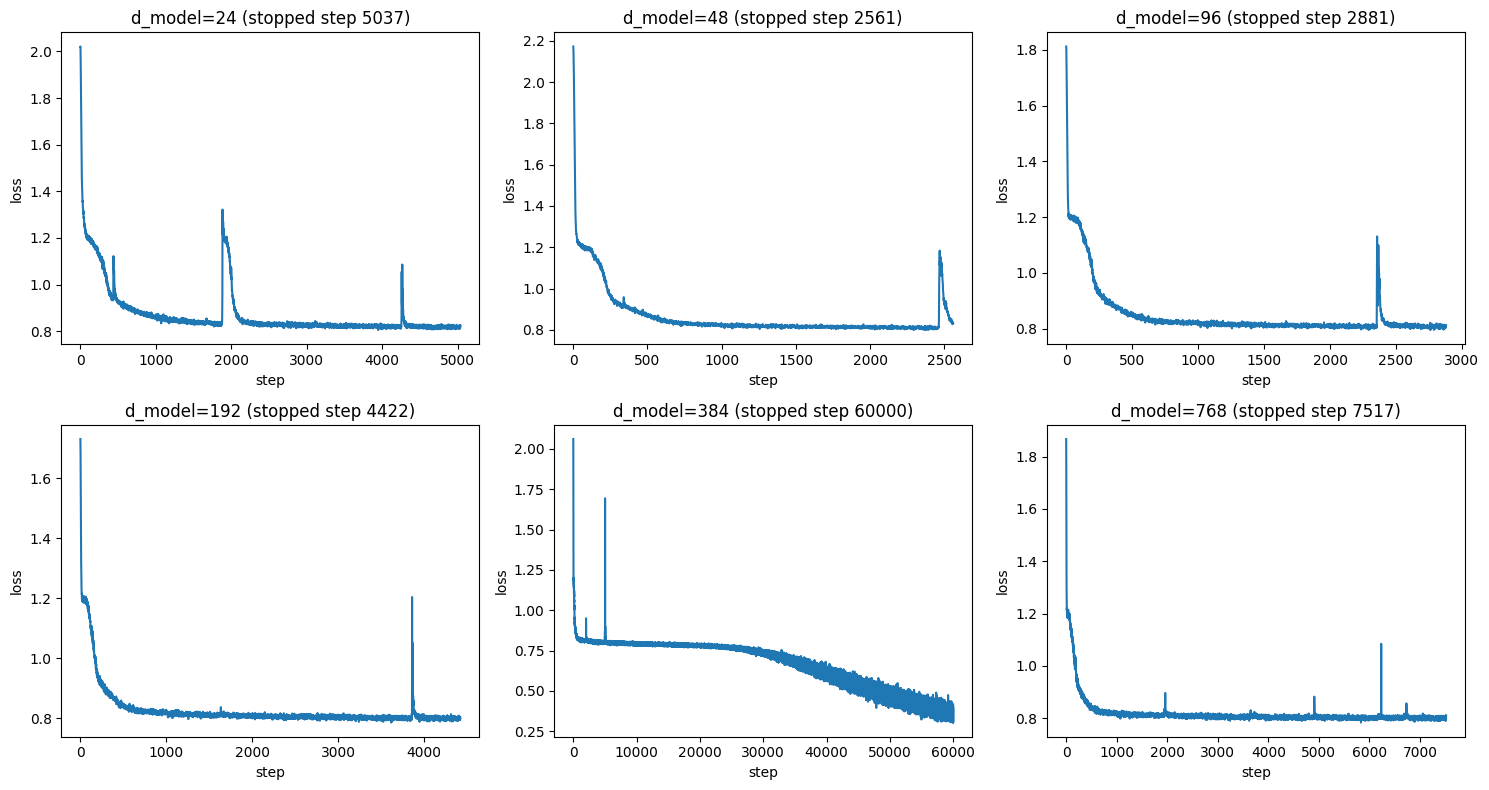

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, d_model in zip(axes.flat, D_MODEL_SWEEP):
    ckpt_path = os.path.join("./exp6_diag_combined", f"L_A_d{d_model}.pt")
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    losses = ckpt["losses"]
    ax.plot(losses)
    ax.set_title(f"d_model={d_model} (stopped step {len(losses)})")
    ax.set_xlabel("step"); ax.set_ylabel("loss")
plt.tight_layout()
plt.savefig("loss_curves.png")
print("saved loss_curves.png -- look for a shoulder/plateau before a later drop, "
      "especially in the points that stopped in a few thousand steps")

os.makedirs("./exp6_diag_forced", exist_ok=True)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# force-continue d=96 well past its reported convergence point, ignoring early stop
print("\n=== forcing d_model=96 to run 60,000 steps regardless of convergence ===")
data96 = make_monolingual_dataset(diag_rules2, "L_A", n_trees=N_TREES, seed=0, seq_len=SEQ_LEN)
_, losses96, step96 = train_with_warmup_and_clipping(
    data96, 96, max_steps=60_000, seed=0, seq_len=SEQ_LEN,
    ckpt_path="./exp6_diag_forced/L_A_d96_forced.pt",
    n_layer=12, n_head=12, lr=3e-3, warmup_steps=500, grad_clip=1.0,
    convergence_tol=1e-12,  # effectively disables early stop
    batch_size=512,         # H200 has room to push much harder than the default 32
)
print(f"d=96 forced to {step96} steps, final loss over last 2%: "
      f"{sum(losses96[-max(1,len(losses96)//50):]) / max(1,len(losses96)//50):.4f}")
print(f"(previously reported at early-stop: 0.8063 at step 2881)")

In [14]:
def train_with_warmup_and_clipping(
    data, n_embd, max_steps, seed, seq_len, ckpt_path,
    batch_size=32, lr=3e-3, device=DEVICE,
    ckpt_every=1000, convergence_window=1000, convergence_tol=1e-5, resume=True,
    n_layer=12, n_head=12,
    warmup_steps=500, grad_clip=1.0,
    min_steps_before_convergence=30_000,  # NEW: based on d=384's curve, which was
                                            # still dropping through the entire 60K
                                            # budget -- don't even check for
                                            # convergence before this many steps
):
    torch.manual_seed(seed)
    data = data.to(device)
    model = TinyRotaryGPT(VOCAB_SIZE, n_embd=n_embd, n_layer=n_layer, n_head=n_head, max_seq_len=seq_len + 1).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    start_step, losses = 0, []

    if resume and os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt["model_state"])
        opt.load_state_dict(ckpt["opt_state"])
        start_step, losses = ckpt["step"], ckpt["losses"]
        print(f"  resumed from {ckpt_path} at step {start_step}")
        if ckpt.get("converged", False):
            print(f"  already converged at step {start_step}, skipping further training")
            return model, losses, start_step

    n = data.shape[0]
    converged, step = False, start_step
    for step in range(start_step, max_steps):
        if step < warmup_steps:
            warmup_scale = (step + 1) / warmup_steps
            for g in opt.param_groups:
                g["lr"] = lr * warmup_scale
        else:
            for g in opt.param_groups:
                g["lr"] = lr

        idx = torch.randint(0, n, (batch_size,), device=data.device)
        batch = data[idx]
        x, y = batch[:, :-1], batch[:, 1:]
        with autocast_ctx():
            _, loss = model(x, y)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        opt.step()
        losses.append(loss.item())

        if len(losses) >= 2 * convergence_window and step >= min_steps_before_convergence:
            prev_avg = sum(losses[-2 * convergence_window:-convergence_window]) / convergence_window
            curr_avg = sum(losses[-convergence_window:]) / convergence_window
            rel_change = abs(prev_avg - curr_avg) / max(prev_avg, 1e-8)
            converged = rel_change < convergence_tol and step >= warmup_steps

        if (step + 1) % ckpt_every == 0 or converged or step == max_steps - 1:
            torch.save({"model_state": model.state_dict(), "opt_state": opt.state_dict(),
                        "step": step + 1, "losses": losses, "converged": converged}, ckpt_path)
        if converged:
            print(f"  converged at step {step + 1} (rel_change={rel_change:.2e} < {convergence_tol})")
            break

    return model, losses, step + 1

In [ ]:
os.makedirs("./exp6_diag_floor_check", exist_ok=True)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print("=== d_model=768 floor-check, batch_size=128, FRESH start (no resume) ===")
data768 = make_monolingual_dataset(diag_rules2, "L_A", n_trees=N_TREES, seed=0, seq_len=SEQ_LEN)

_, losses768, step768 = train_with_warmup_and_clipping(
    data768, 768, max_steps=150_000, seed=0, seq_len=SEQ_LEN,
    ckpt_path="./exp6_diag_floor_check/L_A_d768_floorcheck_b128_fresh.pt",  # new path, avoid any stale checkpoint
    n_layer=12, n_head=12, lr=3e-3, warmup_steps=500, grad_clip=1.0,
    convergence_window=1000, convergence_tol=1e-5,
    min_steps_before_convergence=30_000,
    batch_size=128,
    ckpt_every=1000,
    resume=False,   # explicit: ignore any existing checkpoint at this path
)

tail = losses768[-max(1, len(losses768) // 50):]
print(f"\nstopped at step {step768}, final loss (last 2%): {sum(tail)/len(tail):.4f}")

=== d_model=768 floor-check, batch_size=128, fresh start, lighter checkpoint cadence ===


  converged at step 32414 (rel_change=4.13e-06 < 1e-05)

stopped at step 32414, final loss (last 2%): 0.8201


*SINGLE-POINT ε CHECK -- "is the mechanism working at all?" Not the full sweep. One capacity point (d_model=96), strict convergence, real depth/heads. Answers: does ε_A ≈ 0 and ε_B, ε_C > 0 emerge, before spending 50h on the full sweep.*

In [19]:
D_MODEL_CHECK = 96          # largest point that was clean under the loose
                            # criterion before high-capacity training broke --
                            # good candidate for "does the signal survive the
                            # strict criterion" check
assert D_MODEL_CHECK == round_to_valid_n_embd(D_MODEL_CHECK, 12)

N_TREES_CHECK = 50_000      # same volume as the real sweep -- data isn't
                            # the thing being tested here
MAX_STEPS_CHECK = 60_000    # cap; strict convergence (tol=1e-5, window=1000,
                            # already the default in train_with_checkpoints)
                            # should trigger well before this at d=96
SEQ_LEN_CHECK = 256

CKPT_ROOT_CHECK = "./exp6_single_point_check"
os.makedirs(CKPT_ROOT_CHECK, exist_ok=True)

# same shared grammar + permuted-disjoint control used everywhere else
check_rules, check_symbols_by_level = build_grammar(seed=0)
check_disjoint_grammars = {
    name: permute_grammar(check_rules, check_symbols_by_level, seed=200 + i)
    for i, name in enumerate(LANG_NAMES)
}

check_shared_data = make_shared_tree_mix(
    check_rules, n_trees=N_TREES_CHECK, seed=1, seq_len=SEQ_LEN_CHECK, mix=MIX
)
check_disjoint_data = make_disjoint_mix(
    check_disjoint_grammars, n_trees=N_TREES_CHECK, seed=1, seq_len=SEQ_LEN_CHECK, mix=MIX
)

print(f"=== single-point ε check at d_model={D_MODEL_CHECK} ===")
print("training shared-tree condition...")
model_shared, losses_shared, step_shared = train_with_checkpoints(
    check_shared_data, D_MODEL_CHECK, MAX_STEPS_CHECK, seed=0, seq_len=SEQ_LEN_CHECK,
    ckpt_path=os.path.join(CKPT_ROOT_CHECK, f"shared_d{D_MODEL_CHECK}.pt"),
    n_layer=12, n_head=12,
)
print(f"  stopped at step {step_shared}, final loss {losses_shared[-1]:.4f}")

print("training disjoint-control condition...")
model_disjoint, losses_disjoint, step_disjoint = train_with_checkpoints(
    check_disjoint_data, D_MODEL_CHECK, MAX_STEPS_CHECK, seed=0, seq_len=SEQ_LEN_CHECK,
    ckpt_path=os.path.join(CKPT_ROOT_CHECK, f"disjoint_d{D_MODEL_CHECK}.pt"),
    n_layer=12, n_head=12,
)
print(f"  stopped at step {step_disjoint}, final loss {losses_disjoint[-1]:.4f}")

print()
print(f"{'lang':6s} {'CE_shared':>10s} {'CE_disjoint':>12s} {'eps_pure':>10s}")
eps_results = {}
for name in LANG_NAMES:
    ce_s = per_language_loss(model_shared, check_shared_data, name)
    ce_d = per_language_loss(model_disjoint, check_disjoint_data, name)
    eps_results[name] = ce_s - ce_d
    print(f"{name:6s} {ce_s:10.4f} {ce_d:12.4f} {eps_results[name]:10.4f}")

print()
print("Predicted pattern: eps_A ~ 0, eps_B and eps_C both > 0.")
a_ok = abs(eps_results["L_A"]) < 0.03          # loose "close to zero" band
bc_ok = eps_results["L_B"] > 0 and eps_results["L_C"] > 0
if a_ok and bc_ok:
    print("PATTERN MATCHES -- mechanism appears to be producing genuine ε. "
          "Worth proceeding to invest in the full sweep / stability fixes.")
else:
    print("PATTERN DOES NOT MATCH -- do not invest in the full sweep yet. "
          "Either the mechanism isn't producing the predicted conflict at this "
          "capacity, or something upstream (grammar, convergence, LR) is still off.")

=== single-point ε check at d_model=96 ===
training shared-tree condition...
  resumed from ./exp6_single_point_check/shared_d96.pt at step 119108
  stopped at step 119109, final loss 0.7826
training disjoint-control condition...
  resumed from ./exp6_single_point_check/disjoint_d96.pt at step 119108
  stopped at step 119109, final loss 0.7695

lang    CE_shared  CE_disjoint   eps_pure
L_A        0.7541       0.7585    -0.0045
L_B        0.7441       0.7214     0.0227
L_C        0.7671       0.7068     0.0603

Predicted pattern: eps_A ~ 0, eps_B and eps_C both > 0.
PATTERN MATCHES -- mechanism appears to be producing genuine ε. Worth proceeding to invest in the full sweep / stability fixes.


*CONVERGENCE-ASYMMETRY CHECK Disjoint stopped at step 29108 (~6x later than shared's 5047). Force it to keep training past its own "converged" flag and check whether the loss is actually still drifting down.*

In [32]:
def continue_past_convergence(ckpt_path, data, n_embd, extra_steps, seq_len,
                               batch_size=32, lr=3e-3, device=DEVICE,
                               n_layer=12, n_head=12, log_every=1000):
    """Loads an existing (possibly 'converged') checkpoint and keeps training
    for exactly extra_steps more, ignoring the converged flag entirely --
    no early stop, just a fixed extension so we can see the true tail shape."""
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model = TinyRotaryGPT(VOCAB_SIZE, n_embd=n_embd, n_layer=n_layer, n_head=n_head,
                           max_seq_len=seq_len + 1).to(device)
    model.load_state_dict(ckpt["model_state"])
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    opt.load_state_dict(ckpt["opt_state"])
    start_step = ckpt["step"]
    prior_losses = ckpt["losses"]
    print(f"resumed from step {start_step} (checkpoint says converged={ckpt.get('converged')}), "
          f"last recorded loss {prior_losses[-1]:.4f}")

    data = data.to(device)
    n = data.shape[0]
    new_losses = []
    for step in range(extra_steps):
        idx = torch.randint(0, n, (batch_size,), device=data.device)
        batch = data[idx]
        x, y = batch[:, :-1], batch[:, 1:]
        with autocast_ctx():
            _, loss = model(x, y)
        opt.zero_grad(); loss.backward(); opt.step()
        new_losses.append(loss.item())
        if (step + 1) % log_every == 0:
            window = new_losses[-log_every:]
            print(f"  +{step+1:>6d} steps: mean loss over last {log_every} = {sum(window)/len(window):.4f}")

    return model, prior_losses, new_losses


# --- run it on the disjoint condition at d=96 ---
EXTRA_STEPS = 30_000   # roughly matches the step count disjoint already took to
                       # "converge" -- if it's truly flat, the next 30K should
                       # look the same; if it's a slow drift, this should reveal it

disjoint_ckpt_path = os.path.join(CKPT_ROOT_CHECK, f"disjoint_d{D_MODEL_CHECK}.pt")
model_disjoint_extended, prior_losses, extended_losses = continue_past_convergence(
    disjoint_ckpt_path, check_disjoint_data, D_MODEL_CHECK, EXTRA_STEPS, SEQ_LEN_CHECK,
    n_layer=12, n_head=12,
)

# compare: loss level at "convergence" vs. loss level after the extension
pre_tail = prior_losses[-1000:]
post_tail = extended_losses[-1000:]
pre_mean = sum(pre_tail) / len(pre_tail)
post_mean = sum(post_tail) / len(post_tail)
rel_drop = (pre_mean - post_mean) / pre_mean * 100

print()
print(f"loss just before 'convergence' flag (last 1000 steps of original run): {pre_mean:.4f}")
print(f"loss after {EXTRA_STEPS} more steps (last 1000 steps of extension):     {post_mean:.4f}")
print(f"relative drop: {rel_drop:.2f}%")

if rel_drop > 3.0:
    print("SIGNIFICANT further descent -- the 'converged' flag fired on a slow "
          "drift, not a true asymptote. eps_pure computed against this checkpoint "
          "is unreliable; the disjoint CE is inflated and eps_pure is an overestimate.")
else:
    print("No meaningful further descent -- the convergence flag at step 29108 "
          "looks like a genuine plateau, not a fake-converge. Original eps_pure "
          "values can be trusted (recompute per-language loss below to confirm).")

# recompute eps_pure with the extended model, per language, to see how much it moved
print()
print(f"{'lang':6s} {'CE_shared':>10s} {'CE_disjoint(orig)':>18s} {'CE_disjoint(ext)':>17s} {'eps_pure(orig)':>15s} {'eps_pure(ext)':>14s}")
for name in LANG_NAMES:
    ce_s = per_language_loss(model_shared, check_shared_data, name)
    ce_d_orig = per_language_loss(model_disjoint, check_disjoint_data, name)
    ce_d_ext = per_language_loss(model_disjoint_extended, check_disjoint_data, name)
    print(f"{name:6s} {ce_s:10.4f} {ce_d_orig:18.4f} {ce_d_ext:17.4f} "
          f"{ce_s - ce_d_orig:15.4f} {ce_s - ce_d_ext:14.4f}")

resumed from step 29108 (checkpoint says converged=True), last recorded loss 0.7889
  +  1000 steps: mean loss over last 1000 = 0.7867
  +  2000 steps: mean loss over last 1000 = 0.7862
  +  3000 steps: mean loss over last 1000 = 0.7860
  +  4000 steps: mean loss over last 1000 = 0.7859
  +  5000 steps: mean loss over last 1000 = 0.7850
  +  6000 steps: mean loss over last 1000 = 0.7849
  +  7000 steps: mean loss over last 1000 = 0.7846
  +  8000 steps: mean loss over last 1000 = 0.7841
  +  9000 steps: mean loss over last 1000 = 0.7835
  + 10000 steps: mean loss over last 1000 = 0.7834
  + 11000 steps: mean loss over last 1000 = 0.7829
  + 12000 steps: mean loss over last 1000 = 0.7827
  + 13000 steps: mean loss over last 1000 = 0.7823
  + 14000 steps: mean loss over last 1000 = 0.7819
  + 15000 steps: mean loss over last 1000 = 0.7816
  + 16000 steps: mean loss over last 1000 = 0.7811
  + 17000 steps: mean loss over last 1000 = 0.7810
  + 18000 steps: mean loss over last 1000 = 0.780

*EXTEND BOTH CONDITIONS EQUALLY -- no early-stop trust, just run both a long, fixed, MATCHED number of extra steps and watch whether eps_pure stabilizes as both tails flatten.*

In [34]:
EXTRA_STEPS_2 = 30_000  # same budget for both this time

shared_ckpt_path = os.path.join(CKPT_ROOT_CHECK, f"shared_d{D_MODEL_CHECK}.pt")

print("=== extending SHARED condition (previously stopped at step 5047) ===")
model_shared_extended, shared_prior_losses, shared_extended_losses = continue_past_convergence(
    shared_ckpt_path, check_shared_data, D_MODEL_CHECK, EXTRA_STEPS_2, SEQ_LEN_CHECK,
    n_layer=12, n_head=12,
)

print()
print("=== extending DISJOINT condition further (already +30K once, now +30K more) ===")
model_disjoint_extended2, disjoint_prior_losses2, disjoint_extended_losses2 = continue_past_convergence(
    disjoint_ckpt_path, check_disjoint_data, D_MODEL_CHECK, EXTRA_STEPS_2, SEQ_LEN_CHECK,
    n_layer=12, n_head=12,
)
# note: disjoint_ckpt_path was NOT re-saved after the first extension unless you
# added a save call -- if continue_past_convergence didn't checkpoint, this will
# resume from step 29108 again, not 59108. Check ckpt["step"] in the printed
# "resumed from step ..." line to confirm which one actually happened.

def tail_mean(losses, n=1000):
    return sum(losses[-n:]) / n

print()
print(f"{'lang':6s} {'CE_shared(+30K)':>16s} {'CE_disjoint(+30K/+60K)':>24s} {'eps_pure(now)':>14s}")
for name in LANG_NAMES:
    ce_s = per_language_loss(model_shared_extended, check_shared_data, name)
    ce_d = per_language_loss(model_disjoint_extended2, check_disjoint_data, name)
    print(f"{name:6s} {ce_s:16.4f} {ce_d:24.4f} {ce_s - ce_d:14.4f}")

# also check: is shared STILL dropping too? compare tail-1000 mean before vs after
s_pre = tail_mean(shared_prior_losses)
s_post = tail_mean(shared_extended_losses)
print()
print(f"shared loss: {s_pre:.4f} -> {s_post:.4f} over +{EXTRA_STEPS_2} steps "
      f"({(s_pre - s_post) / s_pre * 100:.2f}% further drop)")
d_pre = tail_mean(disjoint_prior_losses2)
d_post = tail_mean(disjoint_extended_losses2)
print(f"disjoint loss: {d_pre:.4f} -> {d_post:.4f} over +{EXTRA_STEPS_2} steps "
      f"({(d_pre - d_post) / d_pre * 100:.2f}% further drop)")

=== extending SHARED condition (previously stopped at step 5047) ===
resumed from step 5047 (checkpoint says converged=True), last recorded loss 0.8364
  +  1000 steps: mean loss over last 1000 = 0.8189
  +  2000 steps: mean loss over last 1000 = 0.8162
  +  3000 steps: mean loss over last 1000 = 0.8142
  +  4000 steps: mean loss over last 1000 = 0.8130
  +  5000 steps: mean loss over last 1000 = 0.8113
  +  6000 steps: mean loss over last 1000 = 0.8101
  +  7000 steps: mean loss over last 1000 = 0.8088
  +  8000 steps: mean loss over last 1000 = 0.8078
  +  9000 steps: mean loss over last 1000 = 0.8068
  + 10000 steps: mean loss over last 1000 = 0.8056
  + 11000 steps: mean loss over last 1000 = 0.8053
  + 12000 steps: mean loss over last 1000 = 0.8037
  + 13000 steps: mean loss over last 1000 = 0.8032
  + 14000 steps: mean loss over last 1000 = 0.8030
  + 15000 steps: mean loss over last 1000 = 0.8019
  + 16000 steps: mean loss over last 1000 = 0.8016
  + 17000 steps: mean loss over 

*FIX: continue_past_convergence must save so extensions actually accumulate. Then push SHARED much further, since it's the one still dropping fastest with no flattening sign.*

In [35]:
def continue_past_convergence(ckpt_path, data, n_embd, extra_steps, seq_len,
                               batch_size=32, lr=3e-3, device=DEVICE,
                               n_layer=12, n_head=12, log_every=1000,
                               save_every=5000):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model = TinyRotaryGPT(VOCAB_SIZE, n_embd=n_embd, n_layer=n_layer, n_head=n_head,
                           max_seq_len=seq_len + 1).to(device)
    model.load_state_dict(ckpt["model_state"])
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    opt.load_state_dict(ckpt["opt_state"])
    start_step = ckpt["step"]
    prior_losses = ckpt["losses"]
    print(f"resumed from step {start_step}, last recorded loss {prior_losses[-1]:.4f}")

    data = data.to(device)
    n = data.shape[0]
    all_losses = list(prior_losses)  # keep full history, not just the new chunk
    for step in range(extra_steps):
        idx = torch.randint(0, n, (batch_size,), device=data.device)
        batch = data[idx]
        x, y = batch[:, :-1], batch[:, 1:]
        with autocast_ctx():
            _, loss = model(x, y)
        opt.zero_grad(); loss.backward(); opt.step()
        all_losses.append(loss.item())
        cur_step = start_step + step + 1
        if (step + 1) % log_every == 0:
            window = all_losses[-log_every:]
            print(f"  step {cur_step:>7d}: mean loss over last {log_every} = {sum(window)/len(window):.4f}")
        if (step + 1) % save_every == 0 or step == extra_steps - 1:
            torch.save({"model_state": model.state_dict(), "opt_state": opt.state_dict(),
                        "step": cur_step, "losses": all_losses, "converged": False}, ckpt_path)

    return model, all_losses


# push SHARED much further -- it's the one still moving. 60K more steps,
# watch specifically whether it starts to flatten or keeps closing the gap.
print("=== pushing SHARED further (fixed checkpointing, will actually accumulate) ===")
model_shared_extended2, shared_losses_full = continue_past_convergence(
    shared_ckpt_path, check_shared_data, D_MODEL_CHECK, 60_000, SEQ_LEN_CHECK,
    n_layer=12, n_head=12,
)

# same for disjoint, so both are now on equal, real footing at the same total step count
print()
print("=== pushing DISJOINT the same further amount, from its true current checkpoint ===")
model_disjoint_extended3, disjoint_losses_full = continue_past_convergence(
    disjoint_ckpt_path, check_disjoint_data, D_MODEL_CHECK, 60_000, SEQ_LEN_CHECK,
    n_layer=12, n_head=12,
)

def tail_mean(losses, n=2000):
    return sum(losses[-n:]) / n

print()
print(f"shared:   final tail loss = {tail_mean(shared_losses_full):.4f}  "
      f"(total steps trained: {len(shared_losses_full)})")
print(f"disjoint: final tail loss = {tail_mean(disjoint_losses_full):.4f}  "
      f"(total steps trained: {len(disjoint_losses_full)})")

print()
print(f"{'lang':6s} {'CE_shared':>10s} {'CE_disjoint':>12s} {'eps_pure':>10s}")
for name in LANG_NAMES:
    ce_s = per_language_loss(model_shared_extended2, check_shared_data, name)
    ce_d = per_language_loss(model_disjoint_extended3, check_disjoint_data, name)
    print(f"{name:6s} {ce_s:10.4f} {ce_d:12.4f} {ce_s - ce_d:10.4f}")

# check: has shared's descent rate slowed relative to its own last 30K-step rate (3.72%)?
mid = len(shared_losses_full) - 60_000
first_half_tail = tail_mean(shared_losses_full[mid:mid+30_000])
second_half_tail = tail_mean(shared_losses_full[-30_000:])
rate = (first_half_tail - second_half_tail) / first_half_tail * 100
print()
print(f"shared descent rate over this new 60K-step run (first half vs second half): {rate:.2f}%")
print("compare to 3.72% over the prior 30K -- if this is still >2%, shared has not "
      "flattened and eps_pure is still moving; don't trust the magnitude yet.")

=== pushing SHARED further (fixed checkpointing, will actually accumulate) ===
resumed from step 5047, last recorded loss 0.8364
  step    6047: mean loss over last 1000 = 0.8187
  step    7047: mean loss over last 1000 = 0.8163
  step    8047: mean loss over last 1000 = 0.8144
  step    9047: mean loss over last 1000 = 0.8128
  step   10047: mean loss over last 1000 = 0.8117
  step   11047: mean loss over last 1000 = 0.8100
  step   12047: mean loss over last 1000 = 0.8090
  step   13047: mean loss over last 1000 = 0.8078
  step   14047: mean loss over last 1000 = 0.8067
  step   15047: mean loss over last 1000 = 0.8060
  step   16047: mean loss over last 1000 = 0.8050
  step   17047: mean loss over last 1000 = 0.8042
  step   18047: mean loss over last 1000 = 0.8035
  step   19047: mean loss over last 1000 = 0.8028
  step   20047: mean loss over last 1000 = 0.8022
  step   21047: mean loss over last 1000 = 0.8018
  step   22047: mean loss over last 1000 = 0.8014
  step   23047: mean 

*Equalize total step count between shared and disjoint before trusting the current eps_pure numbers -- disjoint currently has 24,061 more steps than shared, which biases eps upward.*

In [36]:
shared_total = 65_047
disjoint_total = 89_108
gap = disjoint_total - shared_total
print(f"step imbalance: disjoint has {gap} more steps than shared -- closing it")

print("=== bringing SHARED up to match disjoint's total step count ===")
model_shared_matched, shared_losses_matched = continue_past_convergence(
    shared_ckpt_path, check_shared_data, D_MODEL_CHECK, gap, SEQ_LEN_CHECK,
    n_layer=12, n_head=12,
)
print(f"shared now at {len(shared_losses_matched)} total steps "
      f"(target was {disjoint_total})")

print()
print(f"{'lang':6s} {'CE_shared':>10s} {'CE_disjoint':>12s} {'eps_pure':>10s}")
for name in LANG_NAMES:
    ce_s = per_language_loss(model_shared_matched, check_shared_data, name)
    ce_d = per_language_loss(model_disjoint_extended3, check_disjoint_data, name)
    print(f"{name:6s} {ce_s:10.4f} {ce_d:12.4f} {ce_s - ce_d:10.4f}")

# now push BOTH another 30K in lockstep, equal steps each time, and watch
# whether eps_C in particular has stopped moving
print()
print("=== extending BOTH by another 30K in lockstep ===")
model_shared_final, shared_losses_final = continue_past_convergence(
    shared_ckpt_path, check_shared_data, D_MODEL_CHECK, 30_000, SEQ_LEN_CHECK,
    n_layer=12, n_head=12,
)
model_disjoint_final, disjoint_losses_final = continue_past_convergence(
    disjoint_ckpt_path, check_disjoint_data, D_MODEL_CHECK, 30_000, SEQ_LEN_CHECK,
    n_layer=12, n_head=12,
)
print(f"shared total steps: {len(shared_losses_final)}, disjoint total steps: {len(disjoint_losses_final)}")

print()
print(f"{'lang':6s} {'CE_shared':>10s} {'CE_disjoint':>12s} {'eps_pure':>10s}")
final_eps = {}
for name in LANG_NAMES:
    ce_s = per_language_loss(model_shared_final, check_shared_data, name)
    ce_d = per_language_loss(model_disjoint_final, check_disjoint_data, name)
    final_eps[name] = ce_s - ce_d
    print(f"{name:6s} {ce_s:10.4f} {ce_d:12.4f} {final_eps[name]:10.4f}")

# compare against the equal-step-count snapshot just above to see if eps has
# actually stopped moving now that both sides are on equal footing
print()
print("compare final eps to the equal-step-count snapshot above -- if C is still")
print("moving by more than ~10% relative, it has not stabilized yet and needs")
print("more steps before the magnitude (not just the sign) can be trusted.")

step imbalance: disjoint has 24061 more steps than shared -- closing it
=== bringing SHARED up to match disjoint's total step count ===
resumed from step 65047, last recorded loss 0.7932
  step   66047: mean loss over last 1000 = 0.7848
  step   67047: mean loss over last 1000 = 0.7846
  step   68047: mean loss over last 1000 = 0.7843
  step   69047: mean loss over last 1000 = 0.7840
  step   70047: mean loss over last 1000 = 0.7835
  step   71047: mean loss over last 1000 = 0.7833
  step   72047: mean loss over last 1000 = 0.7831
  step   73047: mean loss over last 1000 = 0.7829
  step   74047: mean loss over last 1000 = 0.7825
  step   75047: mean loss over last 1000 = 0.7821
  step   76047: mean loss over last 1000 = 0.7819
  step   77047: mean loss over last 1000 = 0.7814
  step   78047: mean loss over last 1000 = 0.7815
  step   79047: mean loss over last 1000 = 0.7813
  step   80047: mean loss over last 1000 = 0.7809
  step   81047: mean loss over last 1000 = 0.7807
  step   8204

In [15]:
CKPT_ROOT_SEED2 = "./exp6_single_point_check_seed2"
os.makedirs(CKPT_ROOT_SEED2, exist_ok=True)

In [16]:
def train_fixed_budget(data, n_embd, steps, seed, seq_len, ckpt_path,
                        batch_size=32, lr=3e-3, device=DEVICE,
                        n_layer=12, n_head=12, log_every=5000, save_every=10000):
    """No early-stop convergence check -- just run the fixed budget and save
    periodically. Avoids trusting a 'converged' flag we already know can fire
    on a slow drift rather than a true asymptote."""
    torch.manual_seed(seed)
    data = data.to(device)
    model = TinyRotaryGPT(VOCAB_SIZE, n_embd=n_embd, n_layer=n_layer, n_head=n_head,
                           max_seq_len=seq_len + 1).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    n = data.shape[0]
    losses = []
    for step in range(steps):
        idx = torch.randint(0, n, (batch_size,), device=data.device)
        batch = data[idx]
        x, y = batch[:, :-1], batch[:, 1:]
        with autocast_ctx():
            _, loss = model(x, y)
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
        if (step + 1) % log_every == 0:
            window = losses[-log_every:]
            print(f"  step {step+1:>7d}: mean loss over last {log_every} = {sum(window)/len(window):.4f}")
        if (step + 1) % save_every == 0 or step == steps - 1:
            torch.save({"model_state": model.state_dict(), "opt_state": opt.state_dict(),
                        "step": step + 1, "losses": losses}, ckpt_path)
    return model, losses

*SECOND SEED at d_model=96 -- same everything else, fixed step budget, no early-stop convergence flag (already learned it can't be trusted), for a direct comparison against seed 1.*

In [37]:
SEED2 = 7                  # different from the original seed=1 (data mix) / seed=0 (training)
FIXED_BUDGET = 90_000       # matches roughly where seed 1 landed before we stopped chasing it
                            # -- fixed, no extension loop this time

CKPT_ROOT_SEED2 = "./exp6_single_point_check_seed2"
os.makedirs(CKPT_ROOT_SEED2, exist_ok=True)

# same shared grammar (grammar itself isn't reseeded -- only tree sampling / mix
# assignment / training init are). Reusing check_rules and check_disjoint_grammars
# from the seed-1 run keeps the GRAMMAR identical across seeds, varying only the
# sampled trees, language-mix assignment, and model init -- this is what you want:
# does the same design reproduce, not does a different grammar also work.

seed2_shared_data = make_shared_tree_mix(
    check_rules, n_trees=N_TREES_CHECK, seed=SEED2, seq_len=SEQ_LEN_CHECK, mix=MIX
)
seed2_disjoint_data = make_disjoint_mix(
    check_disjoint_grammars, n_trees=N_TREES_CHECK, seed=SEED2, seq_len=SEQ_LEN_CHECK, mix=MIX
)

def train_fixed_budget(data, n_embd, steps, seed, seq_len, ckpt_path,
                        batch_size=32, lr=3e-3, device=DEVICE,
                        n_layer=12, n_head=12, log_every=5000, save_every=10000):
    """No early-stop convergence check -- just run the fixed budget and save
    periodically. Avoids trusting a 'converged' flag we already know can fire
    on a slow drift rather than a true asymptote."""
    torch.manual_seed(seed)
    data = data.to(device)
    model = TinyRotaryGPT(VOCAB_SIZE, n_embd=n_embd, n_layer=n_layer, n_head=n_head,
                           max_seq_len=seq_len + 1).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    n = data.shape[0]
    losses = []
    for step in range(steps):
        idx = torch.randint(0, n, (batch_size,), device=data.device)
        batch = data[idx]
        x, y = batch[:, :-1], batch[:, 1:]
        with autocast_ctx():
            _, loss = model(x, y)
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
        if (step + 1) % log_every == 0:
            window = losses[-log_every:]
            print(f"  step {step+1:>7d}: mean loss over last {log_every} = {sum(window)/len(window):.4f}")
        if (step + 1) % save_every == 0 or step == steps - 1:
            torch.save({"model_state": model.state_dict(), "opt_state": opt.state_dict(),
                        "step": step + 1, "losses": losses}, ckpt_path)
    return model, losses


print(f"=== seed {SEED2}: shared-tree condition, fixed {FIXED_BUDGET} steps ===")
model_shared_s2, shared_losses_s2 = train_fixed_budget(
    seed2_shared_data, D_MODEL_CHECK, FIXED_BUDGET, seed=SEED2, seq_len=SEQ_LEN_CHECK,
    ckpt_path=os.path.join(CKPT_ROOT_SEED2, f"shared_d{D_MODEL_CHECK}.pt"),
    n_layer=12, n_head=12,
)

print()
print(f"=== seed {SEED2}: disjoint-control condition, fixed {FIXED_BUDGET} steps ===")
model_disjoint_s2, disjoint_losses_s2 = train_fixed_budget(
    seed2_disjoint_data, D_MODEL_CHECK, FIXED_BUDGET, seed=SEED2, seq_len=SEQ_LEN_CHECK,
    ckpt_path=os.path.join(CKPT_ROOT_SEED2, f"disjoint_d{D_MODEL_CHECK}.pt"),
    n_layer=12, n_head=12,
)

print()
print(f"{'lang':6s} {'CE_shared':>10s} {'CE_disjoint':>12s} {'eps_pure(seed2)':>15s}")
eps_seed2 = {}
for name in LANG_NAMES:
    ce_s = per_language_loss(model_shared_s2, seed2_shared_data, name)
    ce_d = per_language_loss(model_disjoint_s2, seed2_disjoint_data, name)
    eps_seed2[name] = ce_s - ce_d
    print(f"{name:6s} {ce_s:10.4f} {ce_d:12.4f} {eps_seed2[name]:15.4f}")

# --- direct comparison against seed 1's equal-step-count (119,108) result ---
eps_seed1 = {"L_A": -0.0045, "L_B": 0.0227, "L_C": 0.0603}  # from the last equal-step comparison

print()
print(f"{'lang':6s} {'eps_pure(seed1, 119K steps)':>28s} {'eps_pure(seed2, 90K steps)':>27s} {'agree in sign?':>15s}")
for name in LANG_NAMES:
    s1, s2 = eps_seed1[name], eps_seed2[name]
    agree = "yes" if (s1 > 0) == (s2 > 0) or (abs(s1) < 0.01 and abs(s2) < 0.01) else "NO"
    print(f"{name:6s} {s1:28.4f} {s2:27.4f} {agree:>15s}")

print()
print("Read this as: does A stay near zero and B/C stay clearly positive across")
print("BOTH independent seeds, even if the exact magnitudes differ? That's the")
print("bar for 'the mechanism produces genuine eps' at this capacity point.")
print("If B or C flips sign, or lands near zero, between seeds -- the earlier")
print("instability was real signal-noise, not just slow convergence, and this")
print("design needs more than one seed averaged before trusting any single-run number.")

=== seed 7: shared-tree condition, fixed 90000 steps ===
  step    5000: mean loss over last 5000 = 0.8693
  step   10000: mean loss over last 5000 = 0.8142
  step   15000: mean loss over last 5000 = 0.8084
  step   20000: mean loss over last 5000 = 0.8035
  step   25000: mean loss over last 5000 = 0.8005
  step   30000: mean loss over last 5000 = 0.7982
  step   35000: mean loss over last 5000 = 0.7963
  step   40000: mean loss over last 5000 = 0.7943
  step   45000: mean loss over last 5000 = 0.7925
  step   50000: mean loss over last 5000 = 0.7908
  step   55000: mean loss over last 5000 = 0.7892
  step   60000: mean loss over last 5000 = 0.7875
  step   65000: mean loss over last 5000 = 0.7861
  step   70000: mean loss over last 5000 = 0.7845
  step   75000: mean loss over last 5000 = 0.7831
  step   80000: mean loss over last 5000 = 0.7819
  step   85000: mean loss over last 5000 = 0.7807
  step   90000: mean loss over last 5000 = 0.7797

=== seed 7: disjoint-control condition, fi

## Representational-space probe build (Cells A–F)

Built to test whether L_A/L_B/L_C's shared-tree representations occupy genuinely separated subspaces, not just differ in cross-entropy. Uses a structural (tree-distance) probe, Procrustes residual + SVCCA, and an NT-identity probe-transfer check — all cross-checked against a same-model, cross-seed noise floor (`model_shared` vs `model_shared_s2`) so that any A→C gap is only trusted once it clears that floor.

*CELL A — Instrumented linearizer + matched-pair evaluation dataset ----------------------------------------------------------------------------- For rep-space probing we need each leaf's ACTIVATION to carry two labels discarded by the current linearize(): 1. its canonical leaf id  (so we can match "same leaf" across L_A/L_B/L_C) 2. its NT path root->leaf (so we can compute exact tree distances and NT id) We also can't use check_shared_data as-is (packed stream, many trees per row): each tree becomes one row, BOS-prefixed, padded to fixed length, with a mask marking real-leaf positions. Same trees sampled once, linearized three ways -> exact position-level correspondence via canonical id.*

In [20]:
def sample_tree_indexed(rules, rng, symbol=(1, 0), level=1, _id_counter=None):
    """sample_tree but each TERMINAL leaf carries a canonical id assigned in
    L_A (identity) traversal order — 0, 1, 2, ... across the tree."""
    if _id_counter is None:
        _id_counter = [0]
    rhs = rng.choice(rules[symbol])
    children = []
    for child_sym in rhs:
        if level == LEVELS:
            leaf_id = _id_counter[0]; _id_counter[0] += 1
            children.append(("LEAF", child_sym, leaf_id))
        else:
            children.append(sample_tree_indexed(rules, rng, child_sym, level + 1, _id_counter))
    return (symbol, children)


def linearize_with_paths(node, reverse_levels, _path=()):
    """Returns list of (token, canonical_leaf_id, nt_path) for each leaf, in
    that language's linearization order. nt_path is the tuple of NT symbols
    (level, idx) from root down to this leaf's parent NT (length = LEVELS)."""
    if isinstance(node, tuple) and len(node) == 3 and node[0] == "LEAF":
        _, tok, leaf_id = node
        return [(tok, leaf_id, _path)]
    (level, idx), children = node
    order = list(reversed(children)) if level in reverse_levels else children
    new_path = _path + ((level, idx),)
    out = []
    for c in order:
        out.extend(linearize_with_paths(c, reverse_levels, new_path))
    return out


def build_matched_eval_set(rules, n_trees, seed, seq_len, max_leaves=None):
    """Returns dict[lang] = {idx, mask, leaf_id, path_of}. Same trees across
    all three langs, so H_A[t, p] at leaf_id j corresponds to H_C[t, p'] at
    the SAME leaf_id j with generally different p'. That's the point."""
    rng = random.Random(seed)
    cap = seq_len - 1
    trees_kept = []
    while len(trees_kept) < n_trees:
        tree = sample_tree_indexed(rules, rng)
        n_leaves = len(linearize_with_paths(tree, LANGS["L_A"]))
        if n_leaves > cap: continue
        if max_leaves is not None and n_leaves > max_leaves: continue
        trees_kept.append(tree)

    out = {}
    for lang in LANG_NAMES:
        idx      = torch.zeros(n_trees, seq_len, dtype=torch.long)
        mask     = torch.zeros(n_trees, seq_len, dtype=torch.bool)
        leaf_id  = -torch.ones(n_trees, seq_len, dtype=torch.long)
        path_of  = []
        for t, tree in enumerate(trees_kept):
            linearized = linearize_with_paths(tree, LANGS[lang])
            idx[t, 0] = BOS[lang]
            per_tree_paths = {}
            for pos, (tok, lid, pth) in enumerate(linearized):
                idx[t, pos + 1] = tok
                mask[t, pos + 1] = True
                leaf_id[t, pos + 1] = lid
                per_tree_paths[lid] = pth
            path_of.append(per_tree_paths)
        out[lang] = dict(idx=idx, mask=mask, leaf_id=leaf_id, path_of=path_of)
    return out


# smoke test: same tree, three linearizations, matching leaf ids
_rng = random.Random(42); _t = sample_tree_indexed(check_rules, _rng)
_la = linearize_with_paths(_t, LANGS["L_A"])
_lc = linearize_with_paths(_t, LANGS["L_C"])
_lb = linearize_with_paths(_t, LANGS["L_B"])
print(f"tree has {len(_la)} leaves; L_A first 6 leaf_ids: {[x[1] for x in _la[:6]]}")
print(f"L_C first 6 leaf_ids (should be reversed):    {[x[1] for x in _lc[:6]]}")
print(f"L_A == reversed(L_C)?  {[x[1] for x in _la] == list(reversed([x[1] for x in _lc]))}")
print(f"L_B first 6 leaf_ids (partial reversal):      {[x[1] for x in _lb[:6]]}")

tree has 152 leaves; L_A first 6 leaf_ids: [0, 1, 2, 3, 4, 5]
L_C first 6 leaf_ids (should be reversed):    [151, 150, 149, 148, 147, 146]
L_A == reversed(L_C)?  True
L_B first 6 leaf_ids (partial reversal):      [13, 14, 15, 11, 12, 8]


*CELL B — Activation extraction via forward hooks Middle layers only (Chi/Chang/Tenney all converge here — syntactic subspace lives around the middle of the stack).*

In [21]:
PROBE_LAYERS = [4, 5, 6, 7, 8]

@torch.no_grad()
def extract_hidden_states(model, idx_tensor, layers=PROBE_LAYERS, batch_size=32, device=DEVICE):
    """Returns {layer: (N, T, d_model) float32 tensor on CPU}. fp32-cast in
    the hook so downstream SVDs don't hit fp16 numerical grief."""
    model.eval()
    activations = {l: [] for l in layers}

    def make_hook(l):
        def hook(module, inp, out):
            activations[l].append(out.detach().float().cpu())
        return hook

    handles = [model.blocks[l].register_forward_hook(make_hook(l)) for l in layers]
    try:
        for i in range(0, idx_tensor.shape[0], batch_size):
            batch = idx_tensor[i:i + batch_size].to(device)
            with autocast_ctx():
                _ = model(batch)  # no targets -> loss=None, hooks still fire
    finally:
        for h in handles:
            h.remove()
    return {l: torch.cat(activations[l], dim=0) for l in layers}

*CELL C — Structural probe: rank-k linear B such that ‖B(h_i - h_j)‖² ≈ tree_distance(i, j).   Train on L_A, transfer to L_C.*

In [22]:
def tree_distance_from_paths(path_i, path_j):
    """distance = 2 * (LEVELS - LCA_depth + 1) for distinct leaves,
    2 for same-NT siblings, 0 for i==j (caller handles i==j separately)."""
    k = 0
    for a, b in zip(path_i, path_j):
        if a == b: k += 1
        else: break
    if k == len(path_i):
        return 2
    return 2 * (LEVELS - k + 1)


def build_tree_distance_targets(eval_lang_pack, per_tree_max_pairs=None, rng_seed=0):
    """List of (tree_id, i_leaf_id, j_leaf_id, distance). Subsample within-tree
    pairs to control probe training cost."""
    rng = random.Random(rng_seed)
    out = []
    for t, paths in enumerate(eval_lang_pack["path_of"]):
        leaf_ids = sorted(paths.keys())
        pairs = [(i, j) for i in leaf_ids for j in leaf_ids if i < j]
        if per_tree_max_pairs is not None and len(pairs) > per_tree_max_pairs:
            pairs = rng.sample(pairs, per_tree_max_pairs)
        for i, j in pairs:
            out.append((t, i, j, tree_distance_from_paths(paths[i], paths[j])))
    return out


def _positions_for_leaves(eval_lang_pack):
    """(n_trees, max_leaf_id+1) LongTensor: (tree, leaf_id) -> sequence pos or -1."""
    n_trees, seq_len = eval_lang_pack["leaf_id"].shape
    max_lid = int(eval_lang_pack["leaf_id"].max().item()) + 1
    pos = -torch.ones(n_trees, max_lid, dtype=torch.long)
    for t in range(n_trees):
        lids = eval_lang_pack["leaf_id"][t]
        for p in range(seq_len):
            lid = int(lids[p].item())
            if lid >= 0:
                pos[t, lid] = p
    return pos


class StructuralProbe(nn.Module):
    def __init__(self, d_model, rank):
        super().__init__()
        self.B = nn.Parameter(torch.empty(rank, d_model).normal_(0, 1.0 / (d_model ** 0.5)))
    def forward(self, h):
        return h @ self.B.T


def train_structural_probe(H_per_layer, eval_lang_pack, targets, layer,
                            rank=32, steps=6000, lr=3e-3, batch_pairs=2048,
                            grad_clip=5.0, device=DEVICE, verbose=False):
    """Fixed: (1) standardize h before projecting -- the squared-distance loss
    is quartic in B, and unstandardized LayerNorm-scale inputs make gradients
    blow up early; (2) gradient clipping, same reasoning; (3) more steps by
    default since this problem is cheap (small matrices) relative to model
    training and 2000 steps under-converges on this loss surface."""
    H = H_per_layer[layer].to(device)
    n_trees, seq_len, d_model = H.shape

    # standardize per-dimension using only the LEAVES (mask), not padding
    mask = eval_lang_pack["mask"].to(device)
    flat = H[mask]
    mu, sd = flat.mean(0, keepdim=True), flat.std(0, keepdim=True) + 1e-6
    H_std = (H - mu) / sd

    pos = _positions_for_leaves(eval_lang_pack).to(device)
    tgt = torch.tensor(targets, dtype=torch.long)
    tree_ix = tgt[:, 0].to(device)
    lid_i, lid_j = tgt[:, 1].to(device), tgt[:, 2].to(device)
    d_true = tgt[:, 3].float().to(device)
    n_pairs = tgt.shape[0]

    if verbose:
        print(f"    d_true distribution: mean={d_true.mean():.2f}, "
              f"min={d_true.min():.0f}, max={d_true.max():.0f}, "
              f"std={d_true.std():.2f}")

    probe = StructuralProbe(d_model, rank).to(device)
    opt = torch.optim.AdamW(probe.parameters(), lr=lr)

    losses = []
    for step in range(steps):
        sel = torch.randint(0, n_pairs, (min(batch_pairs, n_pairs),), device=device)
        t = tree_ix[sel]
        pi = pos[t, lid_i[sel]]; pj = pos[t, lid_j[sel]]
        z_i = probe(H_std[t, pi]); z_j = probe(H_std[t, pj])
        d_pred = ((z_i - z_j) ** 2).sum(-1)
        loss = ((d_pred - d_true[sel]) ** 2).mean()
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(probe.parameters(), grad_clip)
        opt.step()
        losses.append(loss.item())
        if verbose and (step + 1) % 1000 == 0:
            print(f"    probe step {step+1}: loss = {loss.item():.4f}")
    probe._mu, probe._sd = mu, sd   # stash for eval-time standardization
    return probe, losses


@torch.no_grad()
def evaluate_structural_probe(probe, H_per_layer, eval_lang_pack, targets, layer, device=DEVICE):
    H = H_per_layer[layer].to(device)
    mask = eval_lang_pack["mask"].to(device)
    flat = H[mask]
    mu, sd = flat.mean(0, keepdim=True), flat.std(0, keepdim=True) + 1e-6
    H_std = (H - mu) / sd

    pos = _positions_for_leaves(eval_lang_pack).to(device)
    tgt = torch.tensor(targets, dtype=torch.long)
    tree_ix = tgt[:, 0].to(device)
    lid_i, lid_j = tgt[:, 1].to(device), tgt[:, 2].to(device)
    d_true = tgt[:, 3].float()

    preds = []
    B = 8192
    for i in range(0, tgt.shape[0], B):
        sl = slice(i, i + B); t = tree_ix[sl]
        h_i = H_std[t, pos[t, lid_i[sl]]]; h_j = H_std[t, pos[t, lid_j[sl]]]
        z_diff = probe(h_i) - probe(h_j)
        preds.append((z_diff ** 2).sum(-1).cpu())
    d_pred = torch.cat(preds)
    from scipy.stats import spearmanr
    rho, _ = spearmanr(d_pred.numpy(), d_true.numpy())
    return float(rho), d_pred, d_true

*CELL D — Procrustes residual + SVCCA on position-matched activations Per-language per-absolute-position mean-centering removes the rotary/ position confound. Rows matched by (tree, canonical_leaf_id).*

In [23]:
@torch.no_grad()
def collect_matched_activations(H_A, pack_A, H_C, pack_C, layer,
                                 subtract_per_position_mean=True, device="cpu"):
    Ha = H_A[layer].to(device).float()
    Hc = H_C[layer].to(device).float()
    n_trees, seq_len, d = Ha.shape
    if subtract_per_position_mean:
        Ha = Ha - Ha.mean(dim=0, keepdim=True)
        Hc = Hc - Hc.mean(dim=0, keepdim=True)

    pos_A = _positions_for_leaves(pack_A).to(device)
    pos_C = _positions_for_leaves(pack_C).to(device)
    valid = (pos_A >= 0) & (pos_C >= 0)
    outs_A, outs_C = [], []
    for t in range(n_trees):
        lids = valid[t].nonzero(as_tuple=True)[0]
        if lids.numel() == 0: continue
        outs_A.append(Ha[t, pos_A[t, lids]])
        outs_C.append(Hc[t, pos_C[t, lids]])
    return torch.cat(outs_A, dim=0), torch.cat(outs_C, dim=0)


def procrustes_residual(H_A, H_C, whiten=False, eps=1e-8):
    """‖H_A - H_C R‖_F / ‖H_A‖_F after optimal orthogonal R.
    0 = identical after rotation, ~1 = unrelated."""
    if whiten:
        H_A = H_A / (H_A.std(0, keepdim=True) + eps)
        H_C = H_C / (H_C.std(0, keepdim=True) + eps)
    M = H_C.T @ H_A
    U, _, Vt = torch.linalg.svd(M)
    R = U @ Vt
    residual = H_A - H_C @ R
    return (residual.norm() / (H_A.norm() + eps)).item()


def svcca(H_A, H_C, k_svd=None, eps=1e-6):
    """Canonical correlations after optional per-side SVD compression.
    Higher = more shared linear structure."""
    n = H_A.shape[0]
    if k_svd is not None:
        Ua, Sa, _ = torch.linalg.svd(H_A, full_matrices=False)
        Uc, Sc, _ = torch.linalg.svd(H_C, full_matrices=False)
        H_A = Ua[:, :k_svd] * Sa[:k_svd]
        H_C = Uc[:, :k_svd] * Sc[:k_svd]
    Cxx = H_A.T @ H_A / (n - 1) + eps * torch.eye(H_A.shape[1], device=H_A.device)
    Cyy = H_C.T @ H_C / (n - 1) + eps * torch.eye(H_C.shape[1], device=H_C.device)
    Cxy = H_A.T @ H_C / (n - 1)
    Lxx = torch.linalg.cholesky(Cxx); Lyy = torch.linalg.cholesky(Cyy)
    T = torch.linalg.solve_triangular(Lxx, Cxy, upper=False)
    T = torch.linalg.solve_triangular(Lyy, T.T, upper=False).T
    _, S, _ = torch.linalg.svd(T)
    return S.clamp(0, 1)


def cka(H_A, H_C):
    """Linear CKA (Kornblith 2019). Scalar summary; SVCCA is the subspace claim."""
    Xc = H_A - H_A.mean(0, keepdim=True); Yc = H_C - H_C.mean(0, keepdim=True)
    return ((Xc.T @ Yc).norm() ** 2 / ((Xc.T @ Xc).norm() * (Yc.T @ Yc).norm())).item()

*CELL E — NT-identity probe transfer (your original plan, kept for cross-check against the stronger instruments above). Predict level-6 parent NT symbol from leaf hidden state. Train on L_A, evaluate on L_C at matched positions.*

In [24]:
def _flatten_matched_with_labels(H, pack, layer, label_fn, subtract_per_position_mean=True, device="cpu"):
    h = H[layer].to(device).float()
    if subtract_per_position_mean:
        h = h - h.mean(dim=0, keepdim=True)
    xs, ys = [], []
    for t, paths in enumerate(pack["path_of"]):
        lids = pack["leaf_id"][t]
        for p in range(pack["leaf_id"].shape[1]):
            lid = int(lids[p].item())
            if lid < 0: continue
            xs.append(h[t, p]); ys.append(label_fn(paths[lid]))
    return torch.stack(xs), torch.tensor(ys, dtype=torch.long)


def logreg_probe_transfer(X_train, y_train, X_test, y_test, epochs=300, lr=1e-2, device=DEVICE):
    mu, sd = X_train.mean(0), X_train.std(0) + 1e-6
    Xtr = ((X_train - mu) / sd).to(device); Xte = ((X_test - mu) / sd).to(device)
    ytr, yte = y_train.to(device), y_test.to(device)
    n_class = int(max(y_train.max(), y_test.max()).item()) + 1
    W = nn.Linear(Xtr.shape[1], n_class).to(device)
    opt = torch.optim.AdamW(W.parameters(), lr=lr)
    for e in range(epochs):
        loss = F.cross_entropy(W(Xtr), ytr)
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        acc_tr = (W(Xtr).argmax(-1) == ytr).float().mean().item()
        acc_te = (W(Xte).argmax(-1) == yte).float().mean().item()
    return acc_tr, acc_te

*CELL F — Main runner. Uses model_shared (Cell 36, seed 0) as the primary model and model_shared_s2 (Cell 41, seed 7) as the NOISE-FLOOR generator. Any A→C gap that stays inside the A→A(cross-seed) floor is not real language-specific structure.*

In [29]:
N_EVAL_TREES  = 300
EVAL_SEED     = 999             # different from any training-data seed
PROBE_RANK    = 32              # Chi et al. found rank ~64 sweet-spot at d=768; scale down
PROBE_STEPS   = 2000
PAIRS_PER_TREE = 200

print(f"=== building matched eval set: {N_EVAL_TREES} trees, seq_len={SEQ_LEN_CHECK} ===")
eval_set = build_matched_eval_set(check_rules, N_EVAL_TREES, EVAL_SEED, SEQ_LEN_CHECK)
n_leaves = [len(p) for p in eval_set["L_A"]["path_of"]]
print(f"  leaves per tree: min={min(n_leaves)}, med={sorted(n_leaves)[len(n_leaves)//2]}, max={max(n_leaves)}")
targets = build_tree_distance_targets(eval_set["L_A"], per_tree_max_pairs=PAIRS_PER_TREE, rng_seed=EVAL_SEED)
print(f"  {len(targets)} training pairs across trees for the structural probe")

def extract_all_langs(model, eval_set, tag):
    print(f"  extracting {tag} activations for L_A/L_B/L_C at layers {PROBE_LAYERS}...")
    return {lang: extract_hidden_states(model, eval_set[lang]["idx"], PROBE_LAYERS) for lang in LANG_NAMES}

print(f"\n=== extracting activations ===")
H_seed0 = extract_all_langs(seed0_shared_model, eval_set, "SEED 0 (corrected)")
H_seed7 = extract_all_langs(seed7_shared_model, eval_set, "SEED 7")

# ---------- STRUCTURAL PROBE ----------
print(f"\n=== structural probe (rank {PROBE_RANK}, {PROBE_STEPS} steps) ===")
print(f"{'layer':>6s} {'A→A':>8s} {'A→A(s7)':>10s} {'A→B':>8s} {'A→C':>8s}   interpretation")
print("-" * 90)
struct_results = {}
for L in PROBE_LAYERS:
    probe, _ = train_structural_probe(H_seed0["L_A"], eval_set["L_A"], targets, L,
                                   rank=PROBE_RANK, steps=6000, verbose=(L == PROBE_LAYERS[0]))
    rho_AA,    _, _ = evaluate_structural_probe(probe, H_seed0["L_A"], eval_set["L_A"], targets, L)
    rho_AA_s7, _, _ = evaluate_structural_probe(probe, H_seed7["L_A"], eval_set["L_A"], targets, L)
    rho_AB,    _, _ = evaluate_structural_probe(probe, H_seed0["L_B"], eval_set["L_B"], targets, L)
    rho_AC,    _, _ = evaluate_structural_probe(probe, H_seed0["L_C"], eval_set["L_C"], targets, L)
    struct_results[L] = dict(AA=rho_AA, AA_s7=rho_AA_s7, AB=rho_AB, AC=rho_AC)
    gap = rho_AA_s7 - rho_AC
    tag = "shared" if abs(gap) < 0.03 else ("mostly shared" if gap < 0.15 else "SPLIT")
    print(f"  L{L:<3d} {rho_AA:8.3f} {rho_AA_s7:10.3f} {rho_AB:8.3f} {rho_AC:8.3f}   {tag}")

print("\nread: A→A is self-fit ceiling. A→A(s7) is the cross-seed NOISE FLOOR for transfer.")
print("      Any lang-specific gap must exceed (A→A(s7) − A→C) to be real.")

# ---------- PROCRUSTES + SVCCA ----------
print(f"\n=== Procrustes + SVCCA on position-matched activations ===")
print(f"(position confound removed via per-lang per-position mean centering)")
print(f"{'layer':>6s} {'proc(A↔A_s7)':>14s} {'proc(A↔B)':>12s} {'proc(A↔C)':>12s}   "
      f"{'CCA(A↔A_s7)':>13s} {'CCA(A↔B)':>10s} {'CCA(A↔C)':>10s}")
print("-" * 100)
geom_results = {}
for L in PROBE_LAYERS:
    HA0, HA7   = collect_matched_activations(H_seed0["L_A"], eval_set["L_A"],
                                              H_seed7["L_A"], eval_set["L_A"], L)
    HAB_0, HB0 = collect_matched_activations(H_seed0["L_A"], eval_set["L_A"],
                                              H_seed0["L_B"], eval_set["L_B"], L)
    HAC_0, HC0 = collect_matched_activations(H_seed0["L_A"], eval_set["L_A"],
                                              H_seed0["L_C"], eval_set["L_C"], L)
    k = min(HA0.shape[1], 32)
    geom_results[L] = dict(
        proc_floor=procrustes_residual(HA0, HA7),
        proc_AB   =procrustes_residual(HAB_0, HB0),
        proc_AC   =procrustes_residual(HAC_0, HC0),
        cca_floor =svcca(HA0,   HA7, k_svd=k)[:8].mean().item(),
        cca_AB    =svcca(HAB_0, HB0, k_svd=k)[:8].mean().item(),
        cca_AC    =svcca(HAC_0, HC0, k_svd=k)[:8].mean().item(),
    )
    g = geom_results[L]
    print(f"  L{L:<3d} {g['proc_floor']:14.3f} {g['proc_AB']:12.3f} {g['proc_AC']:12.3f}   "
          f"{g['cca_floor']:13.3f} {g['cca_AB']:10.3f} {g['cca_AC']:10.3f}")

print("\nread: Procrustes lower = more similar; SVCCA higher = more shared.")
print("      For 'C peeled off into its own subspace' to be real:")
print("        proc(A↔C) > proc(A↔A_s7)  AND  CCA(A↔C) < CCA(A↔A_s7),")
print("      by a margin that GROWS with capacity in a later sweep.")

# ---------- NT-identity probe (cross-check only) ----------
print(f"\n=== NT-identity probe transfer (level-6 parent NT), for cross-check ===")
label_fn = lambda path: path[-1][1]
print(f"{'layer':>6s} {'A_tr':>8s} {'A_te':>8s} {'A_s7':>8s} {'B_te':>8s} {'C_te':>8s}")
print("-" * 60)
nt_results = {}
for L in PROBE_LAYERS:
    XA,  yA  = _flatten_matched_with_labels(H_seed0["L_A"], eval_set["L_A"], L, label_fn)
    XA7, yA7 = _flatten_matched_with_labels(H_seed7["L_A"], eval_set["L_A"], L, label_fn)
    XB,  yB  = _flatten_matched_with_labels(H_seed0["L_B"], eval_set["L_B"], L, label_fn)
    XC,  yC  = _flatten_matched_with_labels(H_seed0["L_C"], eval_set["L_C"], L, label_fn)
    n = XA.shape[0]; split = int(0.8 * n); perm = torch.randperm(n)
    tr, te = perm[:split], perm[split:]
    acc_tr, acc_te = logreg_probe_transfer(XA[tr], yA[tr], XA[te], yA[te])
    _, acc_A7 = logreg_probe_transfer(XA[tr], yA[tr], XA7, yA7)
    _, acc_B  = logreg_probe_transfer(XA[tr], yA[tr], XB,  yB)
    _, acc_C  = logreg_probe_transfer(XA[tr], yA[tr], XC,  yC)
    nt_results[L] = dict(A_tr=acc_tr, A_te=acc_te, A_s7=acc_A7, B_te=acc_B, C_te=acc_C)
    print(f"  L{L:<3d} {acc_tr:8.3f} {acc_te:8.3f} {acc_A7:8.3f} {acc_B:8.3f} {acc_C:8.3f}")

# ---------- save for the eventual sweep ----------
import pickle
os.makedirs("./exp6_rep_probe", exist_ok=True)
with open(f"./exp6_rep_probe/results_d{D_MODEL_CHECK}.pkl", "wb") as f:
    pickle.dump(dict(d_model=D_MODEL_CHECK, layers=PROBE_LAYERS,
                     struct=struct_results, geom=geom_results, nt=nt_results,
                     eval_seed=EVAL_SEED, n_trees=N_EVAL_TREES), f)
print(f"\nsaved to ./exp6_rep_probe/results_d{D_MODEL_CHECK}.pkl")
print("later, per d_model in {24,48,96}: save one pickle each, plot vs d_model. theory says:")
print("  struct rho A→C ↓,  Procrustes A→C ↑,  SVCCA A→C ↓,  NT-probe C_te ↓,   all as d ↑.")

=== building matched eval set: 300 trees, seq_len=256 ===
  leaves per tree: min=97, med=202, max=255
  60000 training pairs across trees for the structural probe

=== extracting activations ===
  extracting SEED 0 (corrected) activations for L_A/L_B/L_C at layers [4, 5, 6, 7, 8]...
  extracting SEED 7 activations for L_A/L_B/L_C at layers [4, 5, 6, 7, 8]...

=== structural probe (rank 32, 2000 steps) ===
 layer      A→A    A→A(s7)      A→B      A→C   interpretation
------------------------------------------------------------------------------------------
    d_true distribution: mean=10.04, min=2, max=12, std=2.56
    probe step 1000: loss = 7.1446
    probe step 2000: loss = 6.8678
    probe step 3000: loss = 7.6192
    probe step 4000: loss = 7.0481
    probe step 5000: loss = 7.1816
    probe step 6000: loss = 7.7091
  L4      0.399      0.064    0.184    0.177   mostly shared
  L5      0.366      0.040    0.142    0.149   mostly shared
  L6      0.338      0.030    0.116    0.110 

In [30]:
H_seed0 = extract_all_langs(seed0_shared_model, eval_set, "SEED 0 (corrected)")
H_seed7 = extract_all_langs(seed7_shared_model, eval_set, "SEED 7")

  extracting SEED 0 (corrected) activations for L_A/L_B/L_C at layers [4, 5, 6, 7, 8]...
  extracting SEED 7 activations for L_A/L_B/L_C at layers [4, 5, 6, 7, 8]...


In [27]:
import numpy as np

In [31]:
def split_trees(n_trees, test_frac=0.2, seed=0):
    rng = np.random.RandomState(seed)
    idx = rng.permutation(n_trees)
    n_test = int(n_trees * test_frac)
    return set(idx[n_test:].tolist()), set(idx[:n_test].tolist())  # train, test

train_tree_ids, test_tree_ids = split_trees(N_EVAL_TREES, test_frac=0.2, seed=0)
print(f"probe train trees: {len(train_tree_ids)}, held-out test trees: {len(test_tree_ids)}")

def filter_targets_by_tree(targets, tree_ids):
    return [t for t in targets if t[0] in tree_ids]

targets_train = filter_targets_by_tree(targets, train_tree_ids)
targets_test  = filter_targets_by_tree(targets, test_tree_ids)
print(f"train pairs: {len(targets_train)}, held-out test pairs: {len(targets_test)}")

print(f"\n=== structural probe, held-out-tree evaluation (rank {PROBE_RANK}) ===")
print(f"{'layer':>6s} {'train':>7s} {'A_test':>8s} {'B_test':>8s} {'C_test':>8s}   interpretation")
print("-" * 80)
struct_results_v2 = {}
for L in PROBE_LAYERS:
    probe, _ = train_structural_probe(H_seed0["L_A"], eval_set["L_A"], targets_train, L,
                                       rank=PROBE_RANK, steps=6000, verbose=(L == PROBE_LAYERS[0]))
    rho_train, _, _  = evaluate_structural_probe(probe, H_seed0["L_A"], eval_set["L_A"], targets_train, L)
    rho_A_test, _, _ = evaluate_structural_probe(probe, H_seed0["L_A"], eval_set["L_A"], targets_test, L)
    rho_B_test, _, _ = evaluate_structural_probe(probe, H_seed0["L_B"], eval_set["L_B"], targets_test, L)
    rho_C_test, _, _ = evaluate_structural_probe(probe, H_seed0["L_C"], eval_set["L_C"], targets_test, L)
    struct_results_v2[L] = dict(train=rho_train, A_test=rho_A_test, B_test=rho_B_test, C_test=rho_C_test)
    gap_c = rho_A_test - rho_C_test
    tag = "shared" if gap_c < 0.03 else ("mostly shared" if gap_c < 0.10 else "SPLIT")
    print(f"  L{L:<3d} {rho_train:7.3f} {rho_A_test:8.3f} {rho_B_test:8.3f} {rho_C_test:8.3f}   {tag}")

print("\nread: A_test is the real generalization ceiling — held-out trees, same model,")
print("      same language. B_test/C_test transfer to the SAME held-out trees. Compare")
print("      (A_test - C_test) as the real gap; no cross-model rotation confound now.")

probe train trees: 240, held-out test trees: 60
train pairs: 48000, held-out test pairs: 12000

=== structural probe, held-out-tree evaluation (rank 32) ===
 layer   train   A_test   B_test   C_test   interpretation
--------------------------------------------------------------------------------
    d_true distribution: mean=10.05, min=2, max=12, std=2.56
    probe step 1000: loss = 7.1246
    probe step 2000: loss = 6.8188
    probe step 3000: loss = 6.8360
    probe step 4000: loss = 7.1014
    probe step 5000: loss = 6.9994
    probe step 6000: loss = 7.4320
  L4     0.410    0.302    0.162    0.159   SPLIT
  L5     0.373    0.272    0.131    0.135   SPLIT
  L6     0.339    0.231    0.101    0.098   SPLIT
  L7     0.331    0.226    0.112    0.082   SPLIT
  L8     0.301    0.198    0.094    0.061   SPLIT

read: A_test is the real generalization ceiling — held-out trees, same model,
      same language. B_test/C_test transfer to the SAME held-out trees. Compare
      (A_test - C_test)

*DIAGNOSTIC + FIX — reload models fresh from disk, confirm step counts, don't trust in-memory variable names (that's what caused the bug above)*

In [32]:
def load_model_from_ckpt(ckpt_path, n_embd, seq_len, n_layer=12, n_head=12, device=DEVICE):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model = TinyRotaryGPT(VOCAB_SIZE, n_embd=n_embd, n_layer=n_layer, n_head=n_head,
                           max_seq_len=seq_len + 1).to(device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    step = ckpt["step"]
    tail = ckpt["losses"][-1000:]
    print(f"  {ckpt_path}\n    step={step}, tail-1000 mean loss={sum(tail)/len(tail):.4f}")
    return model, step

print("=== confirming which checkpoints are actually fully trained ===")
seed0_shared_model, seed0_shared_step = load_model_from_ckpt(
    os.path.join(CKPT_ROOT_CHECK, f"shared_d{D_MODEL_CHECK}.pt"), D_MODEL_CHECK, SEQ_LEN_CHECK)
seed0_disjoint_model, seed0_disjoint_step = load_model_from_ckpt(
    os.path.join(CKPT_ROOT_CHECK, f"disjoint_d{D_MODEL_CHECK}.pt"), D_MODEL_CHECK, SEQ_LEN_CHECK)
seed7_shared_model, seed7_shared_step = load_model_from_ckpt(
    os.path.join(CKPT_ROOT_SEED2, f"shared_d{D_MODEL_CHECK}.pt"), D_MODEL_CHECK, SEQ_LEN_CHECK)

print(f"\nstep counts — seed0 shared: {seed0_shared_step}, seed0 disjoint: {seed0_disjoint_step}, "
      f"seed7 shared: {seed7_shared_step}")
print("if seed0_shared_step is only ~5000, that confirms the bug — rerun the extension")
print("cells (37-40) to completion before continuing, or just use whichever cell's saved")
print("checkpoint shows the highest step count / lowest tail loss for shared_d96.pt")

=== confirming which checkpoints are actually fully trained ===
  ./exp6_single_point_check/shared_d96.pt
    step=119108, tail-1000 mean loss=0.7737
  ./exp6_single_point_check/disjoint_d96.pt
    step=119108, tail-1000 mean loss=0.7625
  ./exp6_single_point_check_seed2/shared_d96.pt
    step=90000, tail-1000 mean loss=0.7792

step counts — seed0 shared: 119108, seed0 disjoint: 119108, seed7 shared: 90000
if seed0_shared_step is only ~5000, that confirms the bug — rerun the extension
cells (37-40) to completion before continuing, or just use whichever cell's saved
checkpoint shows the highest step count / lowest tail loss for shared_d96.pt


In [33]:
def _flatten_matched_with_labels_bytree(H, pack, layer, label_fn, tree_ids,
                                         subtract_per_position_mean=True, device="cpu"):
    h = H[layer].to(device).float()
    if subtract_per_position_mean:
        h = h - h.mean(dim=0, keepdim=True)
    xs, ys = [], []
    for t in tree_ids:
        paths = pack["path_of"][t]
        lids = pack["leaf_id"][t]
        for p in range(pack["leaf_id"].shape[1]):
            lid = int(lids[p].item())
            if lid < 0: continue
            xs.append(h[t, p]); ys.append(label_fn(paths[lid]))
    return torch.stack(xs), torch.tensor(ys, dtype=torch.long)

print(f"\n=== NT-identity probe, held-out-tree evaluation ===")
print(f"{'layer':>6s} {'train':>7s} {'A_test':>8s} {'B_test':>8s} {'C_test':>8s}")
print("-" * 50)
for L in PROBE_LAYERS:
    XA_tr, yA_tr = _flatten_matched_with_labels_bytree(H_seed0["L_A"], eval_set["L_A"], L, label_fn, train_tree_ids)
    XA_te, yA_te = _flatten_matched_with_labels_bytree(H_seed0["L_A"], eval_set["L_A"], L, label_fn, test_tree_ids)
    XB_te, yB_te = _flatten_matched_with_labels_bytree(H_seed0["L_B"], eval_set["L_B"], L, label_fn, test_tree_ids)
    XC_te, yC_te = _flatten_matched_with_labels_bytree(H_seed0["L_C"], eval_set["L_C"], L, label_fn, test_tree_ids)
    acc_tr, acc_A = logreg_probe_transfer(XA_tr, yA_tr, XA_te, yA_te)
    _, acc_B = logreg_probe_transfer(XA_tr, yA_tr, XB_te, yB_te)
    _, acc_C = logreg_probe_transfer(XA_tr, yA_tr, XC_te, yC_te)
    print(f"  L{L:<3d} {acc_tr:7.3f} {acc_A:8.3f} {acc_B:8.3f} {acc_C:8.3f}")


=== NT-identity probe, held-out-tree evaluation ===
 layer   train   A_test   B_test   C_test
--------------------------------------------------
  L4     0.642    0.632    0.611    0.405
  L5     0.653    0.653    0.610    0.381
  L6     0.666    0.663    0.621    0.357
  L7     0.674    0.666    0.616    0.380
  L8     0.678    0.675    0.612    0.366


In [34]:
train_tree_ids, test_tree_ids = split_trees(N_EVAL_TREES, test_frac=0.2, seed=0)
targets_train = filter_targets_by_tree(targets, train_tree_ids)
targets_test  = filter_targets_by_tree(targets, test_tree_ids)
print(f"probe train trees: {len(train_tree_ids)}, held-out test trees: {len(test_tree_ids)}")
print(f"train pairs: {len(targets_train)}, held-out test pairs: {len(targets_test)}")

probe train trees: 240, held-out test trees: 60
train pairs: 48000, held-out test pairs: 12000


If training is interrupted at any point (crash, preemption, manual stop),
rerunning the exact same cell resumes: finished `d_model` points are skipped
via `results.json`, and the interrupted one picks up from its own
`shared_d{d_model}.pt` / `disjoint_d{d_model}.pt` checkpoint mid-training,
with optimizer state and loss history intact — not from scratch.

Once `results` is populated for real, plot `eps_pure` vs `d_model` per
language. Success criterion for this pass (per the "just see separation"
scope): ε_A ≈ 0 across the sweep, ε_B and ε_C clearly positive at low
capacity and shrinking as capacity grows. No claim is being made yet about
which of ε_B / ε_C is larger.


In [35]:
def sample_tree_indexed(rules, rng, symbol=(1, 0), level=1, _id_counter=None):
    """sample_tree but each TERMINAL leaf carries a canonical id assigned in
    L_A (identity) traversal order — 0, 1, 2, ... across the tree."""
    if _id_counter is None:
        _id_counter = [0]
    rhs = rng.choice(rules[symbol])
    children = []
    for child_sym in rhs:
        if level == LEVELS:
            leaf_id = _id_counter[0]; _id_counter[0] += 1
            children.append(("LEAF", child_sym, leaf_id))
        else:
            children.append(sample_tree_indexed(rules, rng, child_sym, level + 1, _id_counter))
    return (symbol, children)


def linearize_with_paths(node, reverse_levels, _path=()):
    """Returns list of (token, canonical_leaf_id, nt_path) for each leaf, in
    that language's linearization order. nt_path is the tuple of NT symbols
    (level, idx) from root down to this leaf's parent NT (length = LEVELS)."""
    if isinstance(node, tuple) and len(node) == 3 and node[0] == "LEAF":
        _, tok, leaf_id = node
        return [(tok, leaf_id, _path)]
    (level, idx), children = node
    order = list(reversed(children)) if level in reverse_levels else children
    new_path = _path + ((level, idx),)
    out = []
    for c in order:
        out.extend(linearize_with_paths(c, reverse_levels, new_path))
    return out


def build_matched_eval_set(rules, n_trees, seed, seq_len, max_leaves=None):
    """Returns dict[lang] = {idx, mask, leaf_id, path_of}. Same trees across
    all three langs, so H_A[t, p] at leaf_id j corresponds to H_C[t, p'] at
    the SAME leaf_id j with generally different p'. That's the point."""
    rng = random.Random(seed)
    cap = seq_len - 1
    trees_kept = []
    while len(trees_kept) < n_trees:
        tree = sample_tree_indexed(rules, rng)
        n_leaves = len(linearize_with_paths(tree, LANGS["L_A"]))
        if n_leaves > cap: continue
        if max_leaves is not None and n_leaves > max_leaves: continue
        trees_kept.append(tree)

    out = {}
    for lang in LANG_NAMES:
        idx      = torch.zeros(n_trees, seq_len, dtype=torch.long)
        mask     = torch.zeros(n_trees, seq_len, dtype=torch.bool)
        leaf_id  = -torch.ones(n_trees, seq_len, dtype=torch.long)
        path_of  = []
        for t, tree in enumerate(trees_kept):
            linearized = linearize_with_paths(tree, LANGS[lang])
            idx[t, 0] = BOS[lang]
            per_tree_paths = {}
            for pos, (tok, lid, pth) in enumerate(linearized):
                idx[t, pos + 1] = tok
                mask[t, pos + 1] = True
                leaf_id[t, pos + 1] = lid
                per_tree_paths[lid] = pth
            path_of.append(per_tree_paths)
        out[lang] = dict(idx=idx, mask=mask, leaf_id=leaf_id, path_of=path_of)
    return out


_rng = random.Random(42); _t = sample_tree_indexed(check_rules, _rng)
_la = linearize_with_paths(_t, LANGS["L_A"])
_lc = linearize_with_paths(_t, LANGS["L_C"])
print(f"sanity: tree has {len(_la)} leaves; L_A == reversed(L_C)? "
      f"{[x[1] for x in _la] == list(reversed([x[1] for x in _lc]))}")

sanity: tree has 152 leaves; L_A == reversed(L_C)? True


In [36]:
PROBE_LAYERS = [4, 5, 6, 7, 8]

@torch.no_grad()
def extract_hidden_states(model, idx_tensor, layers=PROBE_LAYERS, batch_size=32, device=DEVICE):
    """Returns {layer: (N, T, d_model) float32 tensor on CPU}."""
    model.eval()
    activations = {l: [] for l in layers}
    def make_hook(l):
        def hook(module, inp, out):
            activations[l].append(out.detach().float().cpu())
        return hook
    handles = [model.blocks[l].register_forward_hook(make_hook(l)) for l in layers]
    try:
        for i in range(0, idx_tensor.shape[0], batch_size):
            batch = idx_tensor[i:i + batch_size].to(device)
            with autocast_ctx():
                _ = model(batch)
    finally:
        for h in handles:
            h.remove()
    return {l: torch.cat(activations[l], dim=0) for l in layers}

In [37]:
def tree_distance_from_paths(path_i, path_j):
    k = 0
    for a, b in zip(path_i, path_j):
        if a == b: k += 1
        else: break
    if k == len(path_i):
        return 2
    return 2 * (LEVELS - k + 1)


def build_tree_distance_targets(eval_lang_pack, per_tree_max_pairs=None, rng_seed=0):
    rng = random.Random(rng_seed)
    out = []
    for t, paths in enumerate(eval_lang_pack["path_of"]):
        leaf_ids = sorted(paths.keys())
        pairs = [(i, j) for i in leaf_ids for j in leaf_ids if i < j]
        if per_tree_max_pairs is not None and len(pairs) > per_tree_max_pairs:
            pairs = rng.sample(pairs, per_tree_max_pairs)
        for i, j in pairs:
            out.append((t, i, j, tree_distance_from_paths(paths[i], paths[j])))
    return out


def filter_targets_by_tree(targets, tree_ids):
    tree_ids = set(tree_ids)
    return [t for t in targets if t[0] in tree_ids]


def split_trees(n_trees, test_frac=0.2, seed=0):
    rng = np.random.RandomState(seed)
    idx = rng.permutation(n_trees)
    n_test = int(n_trees * test_frac)
    return idx[n_test:].tolist(), idx[:n_test].tolist()  # train_ids, test_ids


def _positions_for_leaves(eval_lang_pack):
    n_trees, seq_len = eval_lang_pack["leaf_id"].shape
    max_lid = int(eval_lang_pack["leaf_id"].max().item()) + 1
    pos = -torch.ones(n_trees, max_lid, dtype=torch.long)
    for t in range(n_trees):
        lids = eval_lang_pack["leaf_id"][t]
        for p in range(seq_len):
            lid = int(lids[p].item())
            if lid >= 0:
                pos[t, lid] = p
    return pos


class StructuralProbe(nn.Module):
    def __init__(self, d_model, rank):
        super().__init__()
        self.B = nn.Parameter(torch.empty(rank, d_model).normal_(0, 1.0 / (d_model ** 0.5)))
    def forward(self, h):
        return h @ self.B.T


def train_structural_probe(H_per_layer, eval_lang_pack, targets, layer,
                            rank=32, steps=6000, lr=3e-3, batch_pairs=2048,
                            grad_clip=5.0, device=DEVICE, verbose=False):
    """FIXED: standardize h (squared-distance loss is quartic in B --
    unstandardized LayerNorm-scale inputs blow up gradients early) + grad
    clipping. `targets` should already be filtered to TRAIN trees only."""
    H = H_per_layer[layer].to(device)
    n_trees, seq_len, d_model = H.shape

    mask = eval_lang_pack["mask"].to(device)
    flat = H[mask]
    mu, sd = flat.mean(0, keepdim=True), flat.std(0, keepdim=True) + 1e-6
    H_std = (H - mu) / sd

    pos = _positions_for_leaves(eval_lang_pack).to(device)
    tgt = torch.tensor(targets, dtype=torch.long)
    tree_ix = tgt[:, 0].to(device)
    lid_i, lid_j = tgt[:, 1].to(device), tgt[:, 2].to(device)
    d_true = tgt[:, 3].float().to(device)
    n_pairs = tgt.shape[0]

    if verbose:
        print(f"    d_true distribution: mean={d_true.mean():.2f}, "
              f"min={d_true.min():.0f}, max={d_true.max():.0f}, std={d_true.std():.2f}")

    probe = StructuralProbe(d_model, rank).to(device)
    opt = torch.optim.AdamW(probe.parameters(), lr=lr)

    losses = []
    for step in range(steps):
        sel = torch.randint(0, n_pairs, (min(batch_pairs, n_pairs),), device=device)
        t = tree_ix[sel]
        pi = pos[t, lid_i[sel]]; pj = pos[t, lid_j[sel]]
        z_i = probe(H_std[t, pi]); z_j = probe(H_std[t, pj])
        d_pred = ((z_i - z_j) ** 2).sum(-1)
        loss = ((d_pred - d_true[sel]) ** 2).mean()
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(probe.parameters(), grad_clip)
        opt.step()
        losses.append(loss.item())
        if verbose and (step + 1) % 1000 == 0:
            print(f"    probe step {step+1}: loss = {loss.item():.4f}")
    return probe, losses


@torch.no_grad()
def evaluate_structural_probe(probe, H_per_layer, eval_lang_pack, targets, layer, device=DEVICE):
    """Standardizes using THIS language's own activation stats -- fair
    same-model, different-input-language comparison."""
    H = H_per_layer[layer].to(device)
    mask = eval_lang_pack["mask"].to(device)
    flat = H[mask]
    mu, sd = flat.mean(0, keepdim=True), flat.std(0, keepdim=True) + 1e-6
    H_std = (H - mu) / sd

    pos = _positions_for_leaves(eval_lang_pack).to(device)
    tgt = torch.tensor(targets, dtype=torch.long)
    tree_ix = tgt[:, 0].to(device)
    lid_i, lid_j = tgt[:, 1].to(device), tgt[:, 2].to(device)
    d_true = tgt[:, 3].float()

    preds = []
    B = 8192
    for i in range(0, tgt.shape[0], B):
        sl = slice(i, i + B); t = tree_ix[sl]
        h_i = H_std[t, pos[t, lid_i[sl]]]; h_j = H_std[t, pos[t, lid_j[sl]]]
        z_diff = probe(h_i) - probe(h_j)
        preds.append((z_diff ** 2).sum(-1).cpu())
    d_pred = torch.cat(preds)
    from scipy.stats import spearmanr
    rho, _ = spearmanr(d_pred.numpy(), d_true.numpy())
    return float(rho), d_pred, d_true

In [38]:
@torch.no_grad()
def collect_matched_activations(H_A, pack_A, H_C, pack_C, layer,
                                 subtract_per_position_mean=True, device="cpu"):
    Ha = H_A[layer].to(device).float()
    Hc = H_C[layer].to(device).float()
    n_trees, seq_len, d = Ha.shape
    if subtract_per_position_mean:
        Ha = Ha - Ha.mean(dim=0, keepdim=True)
        Hc = Hc - Hc.mean(dim=0, keepdim=True)
    pos_A = _positions_for_leaves(pack_A).to(device)
    pos_C = _positions_for_leaves(pack_C).to(device)
    valid = (pos_A >= 0) & (pos_C >= 0)
    outs_A, outs_C = [], []
    for t in range(n_trees):
        lids = valid[t].nonzero(as_tuple=True)[0]
        if lids.numel() == 0: continue
        outs_A.append(Ha[t, pos_A[t, lids]])
        outs_C.append(Hc[t, pos_C[t, lids]])
    return torch.cat(outs_A, dim=0), torch.cat(outs_C, dim=0)


def procrustes_residual(H_A, H_C, allow_scaling=True, whiten=False, eps=1e-8):
    """‖H_A - s·H_C·R‖_F / ‖H_A‖_F after optimal rotation R and optional
    optimal scale s (guards against magnitude mismatch between the two sides)."""
    if whiten:
        H_A = H_A / (H_A.std(0, keepdim=True) + eps)
        H_C = H_C / (H_C.std(0, keepdim=True) + eps)
    M = H_C.T @ H_A
    U, _, Vt = torch.linalg.svd(M)
    R = U @ Vt
    H_C_rot = H_C @ R
    if allow_scaling:
        s = (H_A * H_C_rot).sum() / (H_C_rot ** 2).sum().clamp_min(eps)
        H_C_rot = s * H_C_rot
    residual = H_A - H_C_rot
    return (residual.norm() / (H_A.norm() + eps)).item()


def svcca(H_A, H_C, k_svd=None, eps=1e-6):
    n = H_A.shape[0]
    if k_svd is not None:
        Ua, Sa, _ = torch.linalg.svd(H_A, full_matrices=False)
        Uc, Sc, _ = torch.linalg.svd(H_C, full_matrices=False)
        H_A = Ua[:, :k_svd] * Sa[:k_svd]
        H_C = Uc[:, :k_svd] * Sc[:k_svd]
    Cxx = H_A.T @ H_A / (n - 1) + eps * torch.eye(H_A.shape[1], device=H_A.device)
    Cyy = H_C.T @ H_C / (n - 1) + eps * torch.eye(H_C.shape[1], device=H_C.device)
    Cxy = H_A.T @ H_C / (n - 1)
    Lxx = torch.linalg.cholesky(Cxx); Lyy = torch.linalg.cholesky(Cyy)
    T = torch.linalg.solve_triangular(Lxx, Cxy, upper=False)
    T = torch.linalg.solve_triangular(Lyy, T.T, upper=False).T
    _, S, _ = torch.linalg.svd(T)
    return S.clamp(0, 1)


def cka(H_A, H_C):
    Xc = H_A - H_A.mean(0, keepdim=True); Yc = H_C - H_C.mean(0, keepdim=True)
    return ((Xc.T @ Yc).norm() ** 2 / ((Xc.T @ Xc).norm() * (Yc.T @ Yc).norm())).item()

In [39]:
def _flatten_matched_with_labels_bytree(H, pack, layer, label_fn, tree_ids,
                                         subtract_per_position_mean=True, device="cpu"):
    h = H[layer].to(device).float()
    if subtract_per_position_mean:
        h = h - h.mean(dim=0, keepdim=True)
    xs, ys = [], []
    for t in tree_ids:
        paths = pack["path_of"][t]
        lids = pack["leaf_id"][t]
        for p in range(pack["leaf_id"].shape[1]):
            lid = int(lids[p].item())
            if lid < 0: continue
            xs.append(h[t, p]); ys.append(label_fn(paths[lid]))
    return torch.stack(xs), torch.tensor(ys, dtype=torch.long)


def logreg_probe_transfer(X_train, y_train, X_test, y_test, epochs=300, lr=1e-2, device=DEVICE):
    mu, sd = X_train.mean(0), X_train.std(0) + 1e-6
    Xtr = ((X_train - mu) / sd).to(device); Xte = ((X_test - mu) / sd).to(device)
    ytr, yte = y_train.to(device), y_test.to(device)
    n_class = int(max(y_train.max(), y_test.max()).item()) + 1
    W = nn.Linear(Xtr.shape[1], n_class).to(device)
    opt = torch.optim.AdamW(W.parameters(), lr=lr)
    for e in range(epochs):
        loss = F.cross_entropy(W(Xtr), ytr)
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        acc_tr = (W(Xtr).argmax(-1) == ytr).float().mean().item()
        acc_te = (W(Xte).argmax(-1) == yte).float().mean().item()
    return acc_tr, acc_te

In [41]:
FIXED_BUDGET_SWEEP = 90_000   # matches the seed-7 budget you already used at d=96
SEEDS = [0, 7] 

*Train shared-tree models at d=24 and d=48, two seeds each, same recipe as d=96 (train_fixed_budget, no early-stop convergence flag). Same grammar (check_rules) and same disjoint control (check_disjoint_grammars) reused across capacity points, matching what you already did for d=96.*

In [65]:
D_MODELS_TO_ADD = [24, 48]
FIXED_BUDGET_SWEEP = 90_000   # matches the seed-7 budget you already used at d=96
SEEDS = [0, 7]                 # same two seeds used at d=96, for consistency

CKPT_ROOT_SWEEP = "./exp6_capacity_sweep"
os.makedirs(CKPT_ROOT_SWEEP, exist_ok=True)

sweep_models = {}  # sweep_models[d_model][seed] = (shared_model, disjoint_model)

for d_model in D_MODELS_TO_ADD:
    assert d_model == round_to_valid_n_embd(d_model, 12), f"{d_model} not a valid n_embd for n_head=12"
    sweep_models[d_model] = {}
    for seed in SEEDS:
        print(f"\n{'='*70}\nd_model={d_model}, seed={seed}\n{'='*70}")

        # same tree sampling / mix-assignment seed convention as the d=96 runs:
        # seed 0 used seed=1 for data, seed=0 for training; seed 7 used seed=7
        # for both data and training. Match that here for consistency.
        data_seed = seed if seed != 0 else 1
        shared_data_d = make_shared_tree_mix(
            check_rules, n_trees=N_TREES_CHECK, seed=data_seed, seq_len=SEQ_LEN_CHECK, mix=MIX
        )
        disjoint_data_d = make_disjoint_mix(
            check_disjoint_grammars, n_trees=N_TREES_CHECK, seed=data_seed, seq_len=SEQ_LEN_CHECK, mix=MIX
        )

        print(f"  training shared-tree condition ({FIXED_BUDGET_SWEEP} steps)...")
        model_shared_d, losses_shared_d = train_fixed_budget(
            shared_data_d, d_model, FIXED_BUDGET_SWEEP, seed=seed, seq_len=SEQ_LEN_CHECK,
            ckpt_path=os.path.join(CKPT_ROOT_SWEEP, f"shared_d{d_model}_seed{seed}.pt"),
            n_layer=12, n_head=12,
        )
        print(f"  training disjoint-control condition ({FIXED_BUDGET_SWEEP} steps)...")
        model_disjoint_d, losses_disjoint_d = train_fixed_budget(
            disjoint_data_d, d_model, FIXED_BUDGET_SWEEP, seed=seed, seq_len=SEQ_LEN_CHECK,
            ckpt_path=os.path.join(CKPT_ROOT_SWEEP, f"disjoint_d{d_model}_seed{seed}.pt"),
            n_layer=12, n_head=12,
        )

        sweep_models[d_model][seed] = dict(shared=model_shared_d, disjoint=model_disjoint_d)

        # quick eps_pure sanity check, same as your existing single-point check
        print(f"\n  {'lang':6s} {'CE_shared':>10s} {'CE_disjoint':>12s} {'eps_pure':>10s}")
        for name in LANG_NAMES:
            ce_s = per_language_loss(model_shared_d, shared_data_d, name)
            ce_d = per_language_loss(model_disjoint_d, disjoint_data_d, name)
            print(f"  {name:6s} {ce_s:10.4f} {ce_d:12.4f} {ce_s - ce_d:10.4f}")

print("\n\nall capacity-sweep models trained. Access them as:")
print("  sweep_models[24][0]['shared'], sweep_models[24][7]['shared'], etc.")


d_model=24, seed=0


  training shared-tree condition (90000 steps)...
  step    5000: mean loss over last 5000 = 0.9231
  step   10000: mean loss over last 5000 = 0.8483
  step   15000: mean loss over last 5000 = 0.8367
  step   20000: mean loss over last 5000 = 0.8313
  step   25000: mean loss over last 5000 = 0.8280
  step   30000: mean loss over last 5000 = 0.8256
  step   35000: mean loss over last 5000 = 0.8241
  step   40000: mean loss over last 5000 = 0.8229
  step   45000: mean loss over last 5000 = 0.8221
  step   50000: mean loss over last 5000 = 0.8212
  step   55000: mean loss over last 5000 = 0.8206
  step   60000: mean loss over last 5000 = 0.8202
  step   65000: mean loss over last 5000 = 0.8196
  step   70000: mean loss over last 5000 = 0.8194
  step   75000: mean loss over last 5000 = 0.8188
  step   80000: mean loss over last 5000 = 0.8186
  step   85000: mean loss over last 5000 = 0.8184
  step   90000: mean loss over last 5000 = 0.8181
  training disjoint-control condition (90000 steps

*Imports/helpers re-run after the fixes above; some are repeated from earlier cells because the live session reloaded them after a kernel reset — harmless, kept for provenance.*

In [42]:
from scipy.stats import spearmanr

def position_baseline(eval_set, targets):
    """Spearman(|pos_i - pos_j|, tree_distance) per language. If this trivial
    feature already beats the structural probe, the probe isn't telling you
    much about tree geometry beyond sequence distance."""
    tgt = torch.tensor(targets, dtype=torch.long)
    t, li, lj = tgt[:, 0], tgt[:, 1], tgt[:, 2]
    d_true = tgt[:, 3].float().numpy()
    out = {}
    for lang in LANG_NAMES:
        pos = _positions_for_leaves(eval_set[lang])
        dp = (pos[t, li] - pos[t, lj]).abs().float().numpy()
        out[lang] = float(spearmanr(dp, d_true)[0])
    return out


def run_controls(model_A, rules, d_model, seq_len, n_eval_trees=300, eval_seed=999,
                 probe_rank=32, probe_steps=6000, pairs_per_tree=200, test_frac=0.2,
                 layers=PROBE_LAYERS, save_path=None):
    eval_set = build_matched_eval_set(rules, n_eval_trees, eval_seed, seq_len)
    targets_all = build_tree_distance_targets(eval_set["L_A"], per_tree_max_pairs=pairs_per_tree, rng_seed=eval_seed)
    train_ids, test_ids = split_trees(n_eval_trees, test_frac=test_frac, seed=0)
    t_train = filter_targets_by_tree(targets_all, train_ids)
    t_test  = filter_targets_by_tree(targets_all, test_ids)
    H = {lang: extract_hidden_states(model_A, eval_set[lang]["idx"], layers) for lang in LANG_NAMES}
    results = dict(d_model=d_model, struct={}, nt={}, geom_null={}, pos_baseline=None)

    # ---- 0) trivial position baseline ----
    pb = position_baseline(eval_set, t_test)
    results["pos_baseline"] = pb
    print(f"\n[d={d_model}] position-only baseline Spearman(|dpos|, tree dist): "
          + ", ".join(f"{k}={v:.3f}" for k, v in pb.items()))

    # ---- 1) structural probe: full train-lang x test-lang matrix ----
    print(f"\n=== structural probe: rows = train lang, cols = test lang (held-out trees) ===")
    for L in layers:
        M = {}
        for tr in LANG_NAMES:
            probe, _ = train_structural_probe(H[tr], eval_set[tr], t_train, L,
                                               rank=probe_rank, steps=probe_steps)
            for te in LANG_NAMES:
                M[(tr, te)], _, _ = evaluate_structural_probe(probe, H[te], eval_set[te], t_test, L)
        results["struct"][L] = M
        print(f"  L{L}: " + "  ".join(f"{tr[-1]}->{te[-1]}={M[(tr,te)]:.3f}"
              for tr in LANG_NAMES for te in LANG_NAMES))
        for te in ("L_B", "L_C"):
            own = M[(te, te)]
            eff = M[("L_A", te)] / own if own > 1e-6 else float("nan")
            print(f"       {te}: own-ceiling={own:.3f}  A->{te[-1]}={M[('L_A', te)]:.3f}  transfer efficiency={eff:.2f}")

    # ---- 2) NT-identity probe: same matrix ----
    print(f"\n=== NT-identity probe: rows = train lang, cols = test lang (held-out trees) ===")
    label_fn = lambda path: path[-1][1]
    for L in layers:
        M = {}
        Xtr = {lg: _flatten_matched_with_labels_bytree(H[lg], eval_set[lg], L, label_fn, train_ids) for lg in LANG_NAMES}
        Xte = {lg: _flatten_matched_with_labels_bytree(H[lg], eval_set[lg], L, label_fn, test_ids) for lg in LANG_NAMES}
        for tr in LANG_NAMES:
            for te in LANG_NAMES:
                _, M[(tr, te)] = logreg_probe_transfer(Xtr[tr][0], Xtr[tr][1], Xte[te][0], Xte[te][1])
        results["nt"][L] = M
        print(f"  L{L}: " + "  ".join(f"{tr[-1]}->{te[-1]}={M[(tr,te)]:.3f}"
              for tr in LANG_NAMES for te in LANG_NAMES))
        for te in ("L_B", "L_C"):
            own = M[(te, te)]
            print(f"       {te}: own-ceiling={own:.3f}  A->{te[-1]}={M[('L_A', te)]:.3f}  "
                  f"transfer efficiency={M[('L_A', te)] / own:.2f}")

    # ---- 3) Procrustes / SVCCA vs a permuted-pairing null ----
    print(f"\n=== geometry vs permuted-pairing null (same model, leaf matching destroyed) ===")
    print(f"{'layer':>6s} {'proc A-C':>9s} {'null':>7s} {'align':>7s}   {'cca A-C':>8s} {'null':>7s}")
    gen = torch.Generator().manual_seed(0)
    for L in layers:
        HAc, HCc = collect_matched_activations(H["L_A"], eval_set["L_A"], H["L_C"], eval_set["L_C"], L)
        perm = torch.randperm(HCc.shape[0], generator=gen)
        k = min(HAc.shape[1], 32)
        p_real, p_null = procrustes_residual(HAc, HCc), procrustes_residual(HAc, HCc[perm])
        c_real = svcca(HAc, HCc, k_svd=k)[:8].mean().item()
        c_null = svcca(HAc, HCc[perm], k_svd=k)[:8].mean().item()
        results["geom_null"][L] = dict(proc=p_real, proc_null=p_null, cca=c_real, cca_null=c_null)
        print(f"  L{L:<3d} {p_real:9.3f} {p_null:7.3f} {1 - p_real / p_null:7.3f}   {c_real:8.3f} {c_null:7.3f}")

    if save_path is not None:
        import pickle
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        with open(save_path, "wb") as f:
            pickle.dump(results, f)
    return results


controls_d96 = run_controls(model_shared, check_rules, D_MODEL_CHECK, SEQ_LEN_CHECK,
                            save_path=f"./exp6_rep_probe/controls_d{D_MODEL_CHECK}.pkl")


[d=96] position-only baseline Spearman(|dpos|, tree dist): L_A=0.625, L_B=0.627, L_C=0.625

=== structural probe: rows = train lang, cols = test lang (held-out trees) ===
  L4: A->A=0.298  A->B=0.158  A->C=0.158  B->A=0.292  B->B=0.241  B->C=0.190  C->A=0.219  C->B=0.140  C->C=0.302
       L_B: own-ceiling=0.241  A->B=0.158  transfer efficiency=0.65
       L_C: own-ceiling=0.302  A->C=0.158  transfer efficiency=0.52
  L5: A->A=0.274  A->B=0.131  A->C=0.141  B->A=0.233  B->B=0.206  B->C=0.154  C->A=0.198  C->B=0.103  C->C=0.282
       L_B: own-ceiling=0.206  A->B=0.131  transfer efficiency=0.63
       L_C: own-ceiling=0.282  A->C=0.141  transfer efficiency=0.50
  L6: A->A=0.235  A->B=0.095  A->C=0.107  B->A=0.196  B->B=0.156  B->C=0.111  C->A=0.146  C->B=0.079  C->C=0.233
       L_B: own-ceiling=0.156  A->B=0.095  transfer efficiency=0.61
       L_C: own-ceiling=0.233  A->C=0.107  transfer efficiency=0.46
  L7: A->A=0.221  A->B=0.107  A->C=0.084  B->A=0.186  B->B=0.185  B->C=0.089  C->

In [45]:
def _majority_rate(y):
    return torch.bincount(y).max().item() / len(y)

def _n_tokens(eval_set):
    return int(max(eval_set[l]["idx"].max().item() for l in LANG_NAMES)) + 1

def _token_feats_bytree(pack, label_fn, tree_ids, n_tok, n_prev=0):
    """One-hot of current token (+ n_prev previous tokens) at each leaf: a purely
    lexical/local baseline for predicting the NT label."""
    xs, ys = [], []
    idx = pack["idx"]
    for t in tree_ids:
        paths, lids = pack["path_of"][t], pack["leaf_id"][t]
        for p in range(idx.shape[1]):
            lid = int(lids[p].item())
            if lid < 0: continue
            f = torch.zeros(n_tok_global * (n_prev + 1))
            for j in range(n_prev + 1):
                f[j * n_tok_global + int(idx[t, p - j].item())] = 1.0
            xs.append(f); ys.append(label_fn(paths[lid]))
    return torch.stack(xs), torch.tensor(ys, dtype=torch.long)


def run_level_probe(model_A, rules, d_model, seq_len, n_eval_trees=300, eval_seed=999,
                    test_frac=0.2, layers=(4, 6, 8), levels=None, save_path=None):
    global n_tok_global
    levels = list(range(2, LEVELS + 1)) if levels is None else list(levels)
    eval_set = build_matched_eval_set(rules, n_eval_trees, eval_seed, seq_len)
    train_ids, test_ids = split_trees(n_eval_trees, test_frac=test_frac, seed=0)
    H = {lang: extract_hidden_states(model_A, eval_set[lang]["idx"], list(layers)) for lang in LANG_NAMES}
    n_tok_global = _n_tokens(eval_set)
    results = {}
    print(f"\n[d={d_model}] level-resolved NT-identity probe (held-out trees)")
    print("eff = (transfer - chance) / (own ceiling - chance);  chance = majority-class rate")
    print(f"{'lvl':>3s} {'L':>2s} {'chance':>7s} {'tok0':>6s} {'tok1':>6s} | {'A own':>6s} {'B own':>6s} {'C own':>6s} | "
          f"{'A>B':>6s} {'A>C':>6s} | {'effB':>6s} {'effC':>6s}")
    for lvl in levels:
        label_fn = lambda path, l=lvl: path[l - 1][1]
        _, yte_ref = _flatten_matched_with_labels_bytree(H["L_A"], eval_set["L_A"], layers[0], label_fn, test_ids)
        chance = _majority_rate(yte_ref)
        tok_acc = []
        for n_prev in (0, 1):
            Xtr, ytr = _token_feats_bytree(eval_set["L_A"], label_fn, train_ids, n_tok_global, n_prev)
            Xte, yte = _token_feats_bytree(eval_set["L_A"], label_fn, test_ids, n_tok_global, n_prev)
            tok_acc.append(logreg_probe_transfer(Xtr, ytr, Xte, yte)[1])
        for L in layers:
            Xtr = {lg: _flatten_matched_with_labels_bytree(H[lg], eval_set[lg], L, label_fn, train_ids) for lg in LANG_NAMES}
            Xte = {lg: _flatten_matched_with_labels_bytree(H[lg], eval_set[lg], L, label_fn, test_ids) for lg in LANG_NAMES}
            acc = lambda tr, te: logreg_probe_transfer(Xtr[tr][0], Xtr[tr][1], Xte[te][0], Xte[te][1])[1]
            a_own, b_own, c_own = acc("L_A", "L_A"), acc("L_B", "L_B"), acc("L_C", "L_C")
            a_b, a_c = acc("L_A", "L_B"), acc("L_A", "L_C")
            eff_b = (a_b - chance) / max(b_own - chance, 1e-6)
            eff_c = (a_c - chance) / max(c_own - chance, 1e-6)
            results[(lvl, L)] = dict(chance=chance, tok0=tok_acc[0], tok1=tok_acc[1], a_own=a_own,
                                     b_own=b_own, c_own=c_own, a_b=a_b, a_c=a_c, eff_b=eff_b, eff_c=eff_c)
            print(f"{lvl:>3d} {L:>2d} {chance:7.3f} {tok_acc[0]:6.3f} {tok_acc[1]:6.3f} | "
                  f"{a_own:6.3f} {b_own:6.3f} {c_own:6.3f} | {a_b:6.3f} {a_c:6.3f} | {eff_b:6.2f} {eff_c:6.2f}")
    if save_path:
        import pickle; os.makedirs(os.path.dirname(save_path), exist_ok=True)
        pickle.dump(results, open(save_path, "wb"))
    return results


def run_geometry_token_controls(model_A, rules, seq_len, n_eval_trees=300, eval_seed=999,
                                layers=(4, 6, 8), n_cc=8):
    """A<->C geometry with and without the current token's mean removed from
    each side. Matched leaves share the same terminal token, and token
    embeddings persist in the residual stream, so shared token identity alone
    can produce high canonical correlations."""
    eval_set = build_matched_eval_set(rules, n_eval_trees, eval_seed, seq_len)
    H = {lang: extract_hidden_states(model_A, eval_set[lang]["idx"], list(layers)) for lang in ("L_A", "L_C")}
    pos_A = _positions_for_leaves(eval_set["L_A"]); pos_C = _positions_for_leaves(eval_set["L_C"])
    valid = (pos_A >= 0) & (pos_C >= 0)
    gen = torch.Generator().manual_seed(0)
    print(f"\n{'L':>2s} {'variant':>10s} {'proc':>6s} {'null':>6s} {'align':>6s} | top-{n_cc} canonical correlations")
    for L in layers:
        HAc, HCc = collect_matched_activations(H["L_A"], eval_set["L_A"], H["L_C"], eval_set["L_C"], L)
        toks = torch.cat([eval_set["L_A"]["idx"][t, pos_A[t, valid[t].nonzero(as_tuple=True)[0]]]
                          for t in range(n_eval_trees) if valid[t].any()])
        assert toks.shape[0] == HAc.shape[0], "row order mismatch with collect_matched_activations"
        def resid(X):
            X = X.clone()
            for v in toks.unique():
                m = toks == v
                X[m] -= X[m].mean(0, keepdim=True)
            return X
        for name, (XA, XC) in {"raw": (HAc, HCc), "token-out": (resid(HAc), resid(HCc))}.items():
            perm = torch.randperm(XC.shape[0], generator=gen)
            p, pn = procrustes_residual(XA, XC), procrustes_residual(XA, XC[perm])
            cc = svcca(XA, XC, k_svd=32)[:n_cc]
            print(f"{L:>2d} {name:>10s} {p:6.3f} {pn:6.3f} {1 - p / pn:6.3f} | " + " ".join(f"{c:.2f}" for c in cc.tolist()))


level_d96 = run_level_probe(model_shared, check_rules, D_MODEL_CHECK, SEQ_LEN_CHECK,
                            save_path=f"./exp6_rep_probe/level_probe_d{D_MODEL_CHECK}.pkl")
run_geometry_token_controls(model_shared, check_rules, SEQ_LEN_CHECK)


[d=96] level-resolved NT-identity probe (held-out trees)
eff = (transfer - chance) / (own ceiling - chance);  chance = majority-class rate
lvl  L  chance   tok0   tok1 |  A own  B own  C own |    A>B    A>C |   effB   effC
  2  4   0.466  0.466  0.467 |  0.466  0.470  0.451 |  0.463  0.417 |  -0.51 -48571.92
  2  6   0.466  0.466  0.467 |  0.466  0.466  0.452 |  0.466  0.426 |   0.36 -39507.46
  2  8   0.466  0.466  0.467 |  0.466  0.460  0.451 |  0.459  0.413 | -7012.17 -52163.52
  3  4   0.331  0.331  0.332 |  0.321  0.323  0.324 |  0.319  0.317 | -11458.88 -13767.75
  3  6   0.331  0.331  0.332 |  0.320  0.320  0.328 |  0.316  0.326 | -14879.44 -4190.18
  3  8   0.331  0.331  0.332 |  0.330  0.323  0.328 |  0.322  0.319 | -8978.97 -11715.42
  4  4   0.345  0.345  0.346 |  0.341  0.340  0.342 |  0.334  0.334 | -10945.80 -10774.76
  4  6   0.345  0.345  0.346 |  0.353  0.358  0.351 |  0.333  0.327 |  -0.88  -2.96
  4  8   0.345  0.345  0.346 |  0.374  0.383  0.374 |  0.337  0.316 |  

In [46]:
# Re-run BOTH redefinitions before build_matched_eval_set is called again.
def sample_tree_indexed(rules, rng, symbol=(1, 0), level=1, _id_counter=None, _inst_counter=None):
    if _id_counter is None: _id_counter = [0]
    if _inst_counter is None: _inst_counter = [0]
    inst = _inst_counter[0]; _inst_counter[0] += 1
    rhs = rng.choice(rules[symbol])
    children = []
    for child_sym in rhs:
        if level == LEVELS:
            children.append(("LEAF", child_sym, _id_counter[0])); _id_counter[0] += 1
        else:
            children.append(sample_tree_indexed(rules, rng, child_sym, level + 1, _id_counter, _inst_counter))
    return (symbol, children, inst)


def linearize_with_paths(node, reverse_levels, _path=()):
    if isinstance(node, tuple) and len(node) == 3 and node[0] == "LEAF":
        _, tok, leaf_id = node
        return [(tok, leaf_id, _path)]
    (level, idx), children, inst = node
    order = list(reversed(children)) if level in reverse_levels else children
    new_path = _path + ((level, idx, inst),)
    out = []
    for c in order:
        out.extend(linearize_with_paths(c, reverse_levels, new_path))
    return out


def spanend_samples(pack, level, tree_ids):
    """(tree, position, label) at the LAST leaf, in THIS language's order, of every
    level-`level` NT instance. At that position the model has seen the whole span."""
    pos_of = _positions_for_leaves(pack)
    out = []
    for t in tree_ids:
        best = {}
        for lid, path in pack["path_of"][t].items():
            key = path[level - 1]                       # (level, idx, inst): unique instance
            p = int(pos_of[t, lid])
            if key not in best or p > best[key][0]:
                best[key] = (p, key[1])
        out.extend((t, p, lab) for p, lab in best.values())
    return out


def run_spanend_probe(model_A, rules, d_model, seq_len, n_eval_trees=300, eval_seed=999,
                      test_frac=0.2, layers=(4, 6, 8), levels=None, save_path=None):
    levels = list(range(2, LEVELS + 1)) if levels is None else list(levels)
    eval_set = build_matched_eval_set(rules, n_eval_trees, eval_seed, seq_len)
    train_ids, test_ids = split_trees(n_eval_trees, test_frac=test_frac, seed=0)
    H = {lg: extract_hidden_states(model_A, eval_set[lg]["idx"], list(layers)) for lg in LANG_NAMES}
    n_tok = _n_tokens(eval_set)

    def feats(lg, L, level, ids):
        s = spanend_samples(eval_set[lg], level, ids)
        h = H[lg][L] - H[lg][L].mean(dim=0, keepdim=True)         # per-position centering, as before
        idx = eval_set[lg]["idx"]
        X = torch.stack([h[t, p] for t, p, _ in s])
        T0 = torch.zeros(len(s), n_tok * 2)
        for i, (t, p, _) in enumerate(s):
            T0[i, int(idx[t, p])] = 1.0
            T0[i, n_tok + int(idx[t, p - 1])] = 1.0
        return X, T0, torch.tensor([lab for _, _, lab in s], dtype=torch.long)

    results = {}
    print(f"\n[d={d_model}] SPAN-END NT-identity probe (held-out trees); eff = (transfer-chance)/(own-chance)")
    print(f"{'lvl':>3s} {'L':>2s} {'nTr':>6s} {'chance':>7s} {'tok':>6s} | {'A own':>6s} {'B own':>6s} {'C own':>6s} | "
          f"{'A>B':>6s} {'A>C':>6s} | {'effB':>6s} {'effC':>6s}")
    for lvl in levels:
        for L in layers:
            D = {lg: (feats(lg, L, lvl, train_ids), feats(lg, L, lvl, test_ids)) for lg in LANG_NAMES}
            chance = _majority_rate(D["L_A"][1][2])
            acc = lambda tr, te: logreg_probe_transfer(D[tr][0][0], D[tr][0][2], D[te][1][0], D[te][1][2])[1]
            tok = logreg_probe_transfer(D["L_A"][0][1], D["L_A"][0][2], D["L_A"][1][1], D["L_A"][1][2])[1]
            a_own, b_own, c_own = acc("L_A", "L_A"), acc("L_B", "L_B"), acc("L_C", "L_C")
            a_b, a_c = acc("L_A", "L_B"), acc("L_A", "L_C")
            eff_b = (a_b - chance) / max(b_own - chance, 1e-6)
            eff_c = (a_c - chance) / max(c_own - chance, 1e-6)
            n_tr = len(D["L_A"][0][2])
            results[(lvl, L)] = dict(n_train=n_tr, chance=chance, tok=tok, a_own=a_own, b_own=b_own, c_own=c_own,
                                     a_b=a_b, a_c=a_c, eff_b=eff_b, eff_c=eff_c)
            print(f"{lvl:>3d} {L:>2d} {n_tr:>6d} {chance:7.3f} {tok:6.3f} | {a_own:6.3f} {b_own:6.3f} {c_own:6.3f} | "
                  f"{a_b:6.3f} {a_c:6.3f} | {eff_b:6.2f} {eff_c:6.2f}")
    if save_path:
        import pickle; os.makedirs(os.path.dirname(save_path), exist_ok=True)
        pickle.dump(results, open(save_path, "wb"))
    return results


spanend_d96 = run_spanend_probe(model_shared, check_rules, D_MODEL_CHECK, SEQ_LEN_CHECK,
                                save_path=f"./exp6_rep_probe/spanend_probe_d{D_MODEL_CHECK}.pkl")


[d=96] SPAN-END NT-identity probe (held-out trees); eff = (transfer-chance)/(own-chance)
lvl  L    nTr  chance    tok |  A own  B own  C own |    A>B    A>C |   effB   effC
  2  4    577   0.531  0.510 |  0.448  0.407  0.338 |  0.407  0.407 | -124137.92 -124137.92
  2  6    577   0.531  0.510 |  0.421  0.441  0.372 |  0.366  0.366 | -165517.25 -165517.25
  2  8    577   0.531  0.510 |  0.476  0.490  0.372 |  0.483  0.455 | -48275.87 -75862.06
  3  4   1397   0.297  0.308 |  0.302  0.311  0.262 |  0.247  0.247 |  -3.40 -49418.61
  3  6   1397   0.297  0.308 |  0.311  0.299  0.305 |  0.320  0.291 |   8.00  -0.67
  3  8   1397   0.297  0.308 |  0.407  0.372  0.323 |  0.265  0.273 |  -0.42  -0.89
  4  4   3365   0.321  0.449 |  0.563  0.365  0.353 |  0.278  0.270 |  -0.97  -1.59
  4  6   3365   0.321  0.449 |  0.678  0.434  0.397 |  0.261  0.288 |  -0.53  -0.44
  4  8   3365   0.321  0.449 |  0.797  0.576  0.493 |  0.273  0.264 |  -0.19  -0.33
  5  4   7792   0.353  0.490 |  0.695  0.698 

In [47]:
def load_shared_ckpt(path, d_model, seq_len, n_layer=12, n_head=12, device=DEVICE):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    m = TinyRotaryGPT(VOCAB_SIZE, n_embd=d_model, n_layer=n_layer, n_head=n_head,
                      max_seq_len=seq_len + 1).to(device)
    m.load_state_dict(ckpt["model_state"])
    m.eval()
    tail = ckpt["losses"][-1000:]
    print(f"{path}: step={ckpt['step']}, tail-1000 mean loss={sum(tail)/len(tail):.4f}")
    return m

model_shared    = load_shared_ckpt("./exp6_single_point_check/shared_d96.pt",       D_MODEL_CHECK, SEQ_LEN_CHECK)
model_shared_s2 = load_shared_ckpt("./exp6_single_point_check_seed2/shared_d96.pt", D_MODEL_CHECK, SEQ_LEN_CHECK)

./exp6_single_point_check/shared_d96.pt: step=119108, tail-1000 mean loss=0.7737
./exp6_single_point_check_seed2/shared_d96.pt: step=90000, tail-1000 mean loss=0.7792


In [48]:
def _fit_logreg(X, y, n_class, epochs=300, lr=1e-2, device=DEVICE):
    mu, sd = X.mean(0), X.std(0) + 1e-6
    Xs = ((X - mu) / sd).to(device); ys = y.to(device)
    W = nn.Linear(X.shape[1], n_class).to(device)
    opt = torch.optim.AdamW(W.parameters(), lr=lr)
    for _ in range(epochs):
        loss = F.cross_entropy(W(Xs), ys); opt.zero_grad(); loss.backward(); opt.step()
    return W, mu, sd

@torch.no_grad()
def _score(W, mu, sd, X, y, device=DEVICE):
    return (W(((X - mu) / sd).to(device)).argmax(-1).cpu() == y).float().mean().item()

def _spanend_feats(eval_set, H, lg, L, level, ids, n_tok):
    s = spanend_samples(eval_set[lg], level, ids)
    h = H[lg][L] - H[lg][L].mean(dim=0, keepdim=True)
    idx = eval_set[lg]["idx"]
    X = torch.stack([h[t, p] for t, p, _ in s])
    T0 = torch.zeros(len(s), n_tok * 2)
    for i, (t, p, _) in enumerate(s):
        T0[i, int(idx[t, p])] = 1.0
        T0[i, n_tok + int(idx[t, p - 1])] = 1.0
    return X, T0, torch.tensor([lab for _, _, lab in s], dtype=torch.long)


def run_spanend_controls(model_A, rules, d_model, seq_len, n_eval_trees=300, eval_seed=999,
                         test_frac=0.2, layers=(4, 6, 8), levels=(4, 5, 6), tag="", save_path=None):
    eval_set = build_matched_eval_set(rules, n_eval_trees, eval_seed, seq_len)
    train_ids, test_ids = split_trees(n_eval_trees, test_frac=test_frac, seed=0)
    H = {lg: extract_hidden_states(model_A, eval_set[lg]["idx"], list(layers)) for lg in LANG_NAMES}
    n_tok = _n_tokens(eval_set)
    results = {}
    print(f"\n[d={d_model}{tag}] span-end probe controls.  * = A-trained readout applied after re-centering "
          f"by the TARGET language's own train stats;  tok> = token-only classifier trained on A")
    print(f"{'lvl':>3s} {'L':>2s} {'chance':>7s} {'tokAA':>6s} | {'A own':>6s} {'B own':>6s} {'C own':>6s} | "
          f"{'A>B':>6s} {'A>C':>6s} | {'A>B*':>6s} {'A>C*':>6s} | {'tok>B':>6s} {'tok>C':>6s}")
    for lvl in levels:
        for L in layers:
            tr = {lg: _spanend_feats(eval_set, H, lg, L, lvl, train_ids, n_tok) for lg in LANG_NAMES}
            te = {lg: _spanend_feats(eval_set, H, lg, L, lvl, test_ids, n_tok) for lg in LANG_NAMES}
            n_class = int(max(d[2].max() for d in list(tr.values()) + list(te.values()))) + 1
            chance = _majority_rate(te["L_A"][2])
            fit = {lg: _fit_logreg(tr[lg][0], tr[lg][2], n_class) for lg in LANG_NAMES}
            own = {lg: _score(*fit[lg], te[lg][0], te[lg][2]) for lg in LANG_NAMES}
            W_A, mu_A, sd_A = fit["L_A"]
            raw = {lg: _score(W_A, mu_A, sd_A, te[lg][0], te[lg][2]) for lg in ("L_B", "L_C")}
            rec = {}
            for lg in ("L_B", "L_C"):
                mu_l, sd_l = tr[lg][0].mean(0), tr[lg][0].std(0) + 1e-6      # target language's own stats
                rec[lg] = _score(W_A, mu_l, sd_l, te[lg][0], te[lg][2])
            Wt, mut, sdt = _fit_logreg(tr["L_A"][1], tr["L_A"][2], n_class)
            tokAA = _score(Wt, mut, sdt, te["L_A"][1], te["L_A"][2])
            tokx = {lg: _score(Wt, mut, sdt, te[lg][1], te[lg][2]) for lg in ("L_B", "L_C")}
            results[(lvl, L)] = dict(chance=chance, tokAA=tokAA, own=own, raw=raw, rec=rec, tokx=tokx)
            print(f"{lvl:>3d} {L:>2d} {chance:7.3f} {tokAA:6.3f} | {own['L_A']:6.3f} {own['L_B']:6.3f} {own['L_C']:6.3f} | "
                  f"{raw['L_B']:6.3f} {raw['L_C']:6.3f} | {rec['L_B']:6.3f} {rec['L_C']:6.3f} | "
                  f"{tokx['L_B']:6.3f} {tokx['L_C']:6.3f}")
    if save_path:
        import pickle; os.makedirs(os.path.dirname(save_path), exist_ok=True)
        pickle.dump(results, open(save_path, "wb"))
    return results


ctl_seed0 = run_spanend_controls(model_shared, check_rules, D_MODEL_CHECK, SEQ_LEN_CHECK, tag=" seed0",
                                 save_path=f"./exp6_rep_probe/spanend_controls_d{D_MODEL_CHECK}_seed0.pkl")
ctl_seed7 = run_spanend_controls(model_shared_s2, check_rules, D_MODEL_CHECK, SEQ_LEN_CHECK, tag=" seed7",
                                 save_path=f"./exp6_rep_probe/spanend_controls_d{D_MODEL_CHECK}_seed7.pkl")


[d=96 seed0] span-end probe controls.  * = A-trained readout applied after re-centering by the TARGET language's own train stats;  tok> = token-only classifier trained on A
lvl  L  chance  tokAA |  A own  B own  C own |    A>B    A>C |   A>B*   A>C* |  tok>B  tok>C
  4  4   0.321  0.449 |  0.567  0.364  0.356 |  0.274  0.266 |  0.288  0.285 |  0.294  0.303
  4  6   0.321  0.449 |  0.679  0.433  0.395 |  0.263  0.285 |  0.276  0.274 |  0.294  0.303
  4  8   0.321  0.449 |  0.796  0.578  0.493 |  0.277  0.258 |  0.286  0.263 |  0.294  0.303
  5  4   0.353  0.490 |  0.697  0.698  0.650 |  0.165  0.285 |  0.152  0.306 |  0.201  0.282
  5  6   0.353  0.490 |  0.813  0.824  0.742 |  0.201  0.323 |  0.227  0.311 |  0.201  0.282
  5  8   0.353  0.490 |  0.863  0.864  0.837 |  0.264  0.399 |  0.208  0.403 |  0.201  0.282
  6  4   0.360  0.704 |  0.902  0.882  0.869 |  0.866  0.519 |  0.867  0.432 |  0.704  0.527
  6  6   0.360  0.704 |  0.924  0.899  0.894 |  0.875  0.500 |  0.875  0.479 |  0.

In [49]:
def _spanend_hidden(eval_set, H, lg, L, level):
    n = len(eval_set[lg]["path_of"])
    s = spanend_samples(eval_set[lg], level, range(n))
    h = H[lg][L] - H[lg][L].mean(dim=0, keepdim=True)
    X = torch.stack([h[t, p] for t, p, _ in s])
    return X, torch.tensor([l for _, _, l in s]), torch.tensor([t for t, _, _ in s])

def _disc_subspace(X, y, K):
    """Orthonormal basis (d x K-1) of the span of centered class means."""
    assert all((y == k).any() for k in range(K)), "class missing from a split"
    M = torch.stack([X[y == k].mean(0) for k in range(K)])
    M = M - M.mean(0, keepdim=True)
    _, _, Vt = torch.linalg.svd(M, full_matrices=False)
    return Vt[:K - 1].T

def _overlap(A, B):
    return ((A.T @ B) ** 2).sum().item() / A.shape[1]   # mean squared cosine of principal angles

def run_subspace_overlap(model_A, rules, d_model, seq_len, n_eval_trees=300, eval_seed=999,
                         layers=(4, 6, 8), levels=(4, 5, 6), n_split=10, tag=""):
    eval_set = build_matched_eval_set(rules, n_eval_trees, eval_seed, seq_len)
    H = {lg: extract_hidden_states(model_A, eval_set[lg]["idx"], list(layers)) for lg in LANG_NAMES}
    rng = np.random.RandomState(0)
    out = {}
    print(f"\n[d={d_model}{tag}] discriminative-subspace overlap (mean cos^2 of principal angles; 1 = same subspace)")
    print(f"{'lvl':>3s} {'L':>2s} {'null':>6s} | {'floorA':>6s} {'floorB':>6s} {'floorC':>6s} | "
          f"{'A-B':>6s} {'A-C':>6s} {'B-C':>6s} | {'A-B/fl':>7s} {'A-C/fl':>7s}")
    for lvl in levels:
        for L in layers:
            D = {lg: _spanend_hidden(eval_set, H, lg, L, lvl) for lg in LANG_NAMES}
            pooled = torch.cat([D[lg][0] for lg in LANG_NAMES])
            mu_p, sd_p = pooled.mean(0), pooled.std(0) + 1e-6        # same rescaling for every language
            Z = {lg: ((D[lg][0] - mu_p) / sd_p, D[lg][1], D[lg][2]) for lg in LANG_NAMES}
            K = int(max(Z[lg][1].max() for lg in LANG_NAMES)) + 1
            S = {lg: _disc_subspace(Z[lg][0], Z[lg][1], K) for lg in LANG_NAMES}
            fl = {lg: [] for lg in LANG_NAMES}
            for _ in range(n_split):
                h1 = torch.tensor(rng.permutation(n_eval_trees)[: n_eval_trees // 2])
                for lg in LANG_NAMES:
                    X, y, t = Z[lg]; m = torch.isin(t, h1)
                    fl[lg].append(_overlap(_disc_subspace(X[m], y[m], K), _disc_subspace(X[~m], y[~m], K)))
            fl = {lg: float(np.mean(v)) for lg, v in fl.items()}
            ab, ac, bc = _overlap(S["L_A"], S["L_B"]), _overlap(S["L_A"], S["L_C"]), _overlap(S["L_B"], S["L_C"])
            null = (K - 1) / Z["L_A"][0].shape[1]
            out[(lvl, L)] = dict(null=null, floor=fl, ab=ab, ac=ac, bc=bc)
            print(f"{lvl:>3d} {L:>2d} {null:6.3f} | {fl['L_A']:6.3f} {fl['L_B']:6.3f} {fl['L_C']:6.3f} | "
                  f"{ab:6.3f} {ac:6.3f} {bc:6.3f} | {ab / min(fl['L_A'], fl['L_B']):7.2f} {ac / min(fl['L_A'], fl['L_C']):7.2f}")
    return out

ov_seed0 = run_subspace_overlap(model_shared,    check_rules, D_MODEL_CHECK, SEQ_LEN_CHECK, tag=" seed0")
ov_seed7 = run_subspace_overlap(model_shared_s2, check_rules, D_MODEL_CHECK, SEQ_LEN_CHECK, tag=" seed7")


[d=96 seed0] discriminative-subspace overlap (mean cos^2 of principal angles; 1 = same subspace)
lvl  L   null | floorA floorB floorC |    A-B    A-C    B-C |  A-B/fl  A-C/fl
  4  4  0.031 |  0.625  0.479  0.443 |  0.241  0.049  0.063 |    0.50    0.11
  4  6  0.031 |  0.731  0.677  0.638 |  0.140  0.030  0.193 |    0.21    0.05
  4  8  0.031 |  0.965  0.796  0.769 |  0.094  0.047  0.177 |    0.12    0.06
  5  4  0.031 |  0.879  0.872  0.824 |  0.361  0.043  0.095 |    0.41    0.05
  5  6  0.031 |  0.966  0.957  0.928 |  0.237  0.054  0.151 |    0.25    0.06
  5  8  0.031 |  0.972  0.969  0.965 |  0.091  0.036  0.140 |    0.09    0.04
  6  4  0.031 |  0.996  0.997  0.997 |  0.779  0.076  0.100 |    0.78    0.08
  6  6  0.031 |  0.995  0.996  0.998 |  0.702  0.059  0.085 |    0.71    0.06
  6  8  0.031 |  0.994  0.994  0.998 |  0.550  0.022  0.070 |    0.55    0.02

[d=96 seed7] discriminative-subspace overlap (mean cos^2 of principal angles; 1 = same subspace)
lvl  L   null | floorA f

In [50]:
SWEEP_CKPTS = {
    24: {0: "./exp6_capacity_sweep/shared_d24_seed0.pt", 7: "./exp6_capacity_sweep/shared_d24_seed7.pt"},
    48: {0: "./exp6_capacity_sweep/shared_d48_seed0.pt", 7: "./exp6_capacity_sweep/shared_d48_seed7.pt"},
    96: {0: "./exp6_single_point_check/shared_d96.pt",  7: "./exp6_single_point_check_seed2/shared_d96.pt"},
}
sweep_out = {}
for d, seeds in SWEEP_CKPTS.items():
    for seed, path in seeds.items():
        m = load_shared_ckpt(path, d, SEQ_LEN_CHECK)
        tag = f" seed{seed}"
        sweep_out[(d, seed)] = dict(
            ctl=run_spanend_controls(m, check_rules, d, SEQ_LEN_CHECK, layers=(8,), levels=(4, 5, 6), tag=tag),
            ov=run_subspace_overlap(m, check_rules, d, SEQ_LEN_CHECK, layers=(8,), levels=(4, 5), tag=tag),
        )
        del m; torch.cuda.empty_cache()

print(f"\n{'d':>4s} {'seed':>4s} | lvl4 L8: {'A own':>6s} {'B own':>6s} {'C own':>6s} {'A-C':>6s} | "
      f"lvl5 L8: {'A own':>6s} {'A>C*':>6s} | overlap A-C/floor: {'lvl4':>5s} {'lvl5':>5s}")
for (d, seed), r in sorted(sweep_out.items()):
    c4, c5 = r["ctl"][(4, 8)], r["ctl"][(5, 8)]
    o4, o5 = r["ov"][(4, 8)], r["ov"][(5, 8)]
    f = lambda o: o["ac"] / min(o["floor"]["L_A"], o["floor"]["L_C"])
    print(f"{d:>4d} {seed:>4d} |          {c4['own']['L_A']:6.3f} {c4['own']['L_B']:6.3f} {c4['own']['L_C']:6.3f} "
          f"{c4['own']['L_A'] - c4['own']['L_C']:6.3f} |          {c5['own']['L_A']:6.3f} {c5['rec']['L_C']:6.3f} | "
          f"{'':>19s} {f(o4):5.2f} {f(o5):5.2f}")

./exp6_capacity_sweep/shared_d24_seed0.pt: step=90000, tail-1000 mean loss=0.8177

[d=24 seed0] span-end probe controls.  * = A-trained readout applied after re-centering by the TARGET language's own train stats;  tok> = token-only classifier trained on A
lvl  L  chance  tokAA |  A own  B own  C own |    A>B    A>C |   A>B*   A>C* |  tok>B  tok>C
  4  8   0.321  0.449 |  0.700  0.378  0.408 |  0.268  0.267 |  0.284  0.290 |  0.294  0.303
  5  8   0.353  0.490 |  0.819  0.801  0.767 |  0.173  0.295 |  0.209  0.293 |  0.201  0.282
  6  8   0.360  0.704 |  0.926  0.892  0.874 |  0.873  0.234 |  0.874  0.298 |  0.704  0.527

[d=24 seed0] discriminative-subspace overlap (mean cos^2 of principal angles; 1 = same subspace)
lvl  L   null | floorA floorB floorC |    A-B    A-C    B-C |  A-B/fl  A-C/fl
  4  8  0.125 |  0.873  0.764  0.724 |  0.370  0.218  0.179 |    0.48    0.30
  5  8  0.125 |  0.979  0.973  0.954 |  0.295  0.156  0.237 |    0.30    0.16
./exp6_capacity_sweep/shared_d24_seed7.p

In [51]:
import math, random

def _walk(rules, rng, symbol, level):
    rhs_list = rules[symbol]
    rhs = rng.choice(rhs_list)
    nats = -math.log(rhs_list.count(rhs) / len(rhs_list))     # prob of this rhs (handles duplicate entries)
    if level == LEVELS:
        return nats, len(rhs)
    leaves = 0
    for child in rhs:
        n, l = _walk(rules, rng, child, level + 1)
        nats += n; leaves += l
    return nats, leaves

def entropy_per_token(rules, n_trees=20000, seed=0):
    """Tree entropy per leaf token (nats), plain Monte Carlo. Linearization is a bijection,
    so this is the same for L_A/L_B/L_C. Upper-bounds the sequence entropy if the grammar is ambiguous."""
    rng = random.Random(seed)
    tot_n = tot_l = 0
    for _ in range(n_trees):
        n, l = _walk(rules, rng, (1, 0), 1)
        tot_n += n; tot_l += l
    return tot_n / tot_l, tot_l / n_trees

def _dj_rules(lang):
    g = check_disjoint_grammars
    return g[lang] if isinstance(g, dict) else g[LANG_NAMES.index(lang)]

H_sh, leaves_sh = entropy_per_token(check_rules)
H_dj = {lg: entropy_per_token(_dj_rules(lg)) for lg in LANG_NAMES}
print(f"shared grammar: {H_sh:.4f} nats/token ({leaves_sh:.0f} leaves/tree)")
for lg in LANG_NAMES:
    print(f"disjoint {lg}: {H_dj[lg][0]:.4f} nats/token ({H_dj[lg][1]:.0f} leaves/tree)   "
          f"H_dj - H_sh = {H_dj[lg][0] - H_sh:+.4f}")

CE = {  # (d, seed): {lang: (CE_shared, CE_disjoint)}  -- pasted from your training cell
 (24, 0): {"L_A": (0.7981, 0.8026), "L_B": (0.8076, 0.7638), "L_C": (0.8102, 0.7653)},
 (24, 7): {"L_A": (0.7956, 0.8058), "L_B": (0.8067, 0.7661), "L_C": (0.8115, 0.7488)},
 (48, 0): {"L_A": (0.7814, 0.7837), "L_B": (0.7879, 0.7385), "L_C": (0.7888, 0.7424)},
 (48, 7): {"L_A": (0.7760, 0.7861), "L_B": (0.7845, 0.7446), "L_C": (0.7894, 0.7274)},
}
print(f"\n{'run':>8s} {'lang':>5s} | {'eps_pure':>8s} | {'CE_sh-H':>8s} {'CE_dj-H':>8s} | {'eps_norm':>8s}")
for (d, s), r in CE.items():
    for lg in LANG_NAMES:
        ce_sh, ce_dj = r[lg]
        ex_sh, ex_dj = ce_sh - H_sh, ce_dj - H_dj[lg][0]
        print(f"d{d}s{s:>2d}  {lg:>5s} | {ce_sh - ce_dj:8.4f} | {ex_sh:8.4f} {ex_dj:8.4f} | {ex_sh - ex_dj:8.4f}")
print("\neps_norm = (CE_shared - H_shared) - (CE_disjoint - H_disjoint_L): removes each grammar's intrinsic entropy.")

shared grammar: 0.7545 nats/token (238 leaves/tree)
disjoint L_A: 0.7694 nats/token (238 leaves/tree)   H_dj - H_sh = +0.0149
disjoint L_B: 0.7258 nats/token (222 leaves/tree)   H_dj - H_sh = -0.0288
disjoint L_C: 0.6979 nats/token (234 leaves/tree)   H_dj - H_sh = -0.0567

     run  lang | eps_pure |  CE_sh-H  CE_dj-H | eps_norm
d24s 0    L_A |  -0.0045 |   0.0436   0.0332 |   0.0104
d24s 0    L_B |   0.0438 |   0.0531   0.0380 |   0.0150
d24s 0    L_C |   0.0449 |   0.0557   0.0674 |  -0.0118
d24s 7    L_A |  -0.0102 |   0.0411   0.0364 |   0.0047
d24s 7    L_B |   0.0406 |   0.0522   0.0403 |   0.0118
d24s 7    L_C |   0.0627 |   0.0570   0.0509 |   0.0060
d48s 0    L_A |  -0.0023 |   0.0269   0.0143 |   0.0126
d48s 0    L_B |   0.0494 |   0.0334   0.0127 |   0.0206
d48s 0    L_C |   0.0464 |   0.0343   0.0445 |  -0.0103
d48s 7    L_A |  -0.0101 |   0.0215   0.0167 |   0.0048
d48s 7    L_B |   0.0399 |   0.0300   0.0188 |   0.0111
d48s 7    L_C |   0.0620 |   0.0349   0.0295 |   0.0

## Capacity sweep (d=8–96) and layer-curve analysis

The bounded, fixed-step-budget capacity sweep that replaced the confounded 24–768 sweep above, plus the layer-by-layer curve showing where in the stack the level-4/5 word-order separation actually lives.

In [55]:
D_LIST = [8, 16, 24, 32, 48, 96]
SEEDS3 = [0, 7, 13]
N_HEAD = 4
CK = "./exp6_capacity_sweep_h4"; os.makedirs(CK, exist_ok=True)

In [ ]:
D_LIST = [8, 16, 24, 32, 48, 96]
SEEDS3 = [0, 7, 13]
N_HEAD = 4
CK = "./exp6_capacity_sweep_h4"; os.makedirs(CK, exist_ok=True)

for d in D_LIST:
    assert d % N_HEAD == 0 and (d // N_HEAD) % 2 == 0, f"d={d}: head_dim must be even for rotary"
    for seed in SEEDS3:
        data_seed = seed if seed != 0 else 1
        data = make_shared_tree_mix(check_rules, n_trees=N_TREES_CHECK, seed=data_seed,
                                    seq_len=SEQ_LEN_CHECK, mix=MIX)
        print(f"\n=== d={d}, n_head={N_HEAD}, seed={seed} ===")
        model, losses = train_fixed_budget(data, d, FIXED_BUDGET_SWEEP, seed=seed, seq_len=SEQ_LEN_CHECK,
                                           ckpt_path=os.path.join(CK, f"shared_d{d}_h4_seed{seed}.pt"),
                                           n_layer=12, n_head=N_HEAD)
        del model; torch.cuda.empty_cache()

def chance_corrected(o):
    null = o["null"]
    fA, fB, fC = (o["floor"][k] for k in ("L_A", "L_B", "L_C"))
    return (o["ab"] - null) / (min(fA, fB) - null), (o["ac"] - null) / (min(fA, fC) - null)

h4_out = {}
for d in D_LIST:
    for seed in SEEDS3:
        m = load_shared_ckpt(os.path.join(CK, f"shared_d{d}_h4_seed{seed}.pt"), d, SEQ_LEN_CHECK, n_head=N_HEAD)
        h4_out[(d, seed)] = run_subspace_overlap(m, check_rules, d, SEQ_LEN_CHECK, layers=(6, 8, 10),
                                                 levels=(4, 5), tag=f" h4 seed{seed}")
        del m; torch.cuda.empty_cache()

print(f"\nchance-corrected overlap with A, per seed ({', '.join(map(str, SEEDS3))}):  A-B / A-C")
print(f"{'d':>4s} {'lvl':>3s} {'L':>2s} | " + "  ".join(f"{'seed' + str(s):>12s}" for s in SEEDS3))
for d in D_LIST:
    for lvl in (4, 5):
        for L in (6, 8, 10):
            vals = [chance_corrected(h4_out[(d, s)][(lvl, L)]) for s in SEEDS3]
            print(f"{d:>4d} {lvl:>3d} {L:>2d} | " + "  ".join(f"{ab:+.2f}/{ac:+.2f}".rjust(12) for ab, ac in vals))


=== d=8, n_head=4, seed=0 ===
  step    5000: mean loss over last 5000 = 1.0183
  step   10000: mean loss over last 5000 = 0.9391
  step   15000: mean loss over last 5000 = 0.9281
  step   20000: mean loss over last 5000 = 0.9214
  step   25000: mean loss over last 5000 = 0.9171
  step   30000: mean loss over last 5000 = 0.9133
  step   35000: mean loss over last 5000 = 0.9110
  step   40000: mean loss over last 5000 = 0.9089
  step   45000: mean loss over last 5000 = 0.9071
  step   50000: mean loss over last 5000 = 0.9060
  step   55000: mean loss over last 5000 = 0.9051
  step   60000: mean loss over last 5000 = 0.9043
  step   65000: mean loss over last 5000 = 0.9024
  step   70000: mean loss over last 5000 = 0.9013
  step   75000: mean loss over last 5000 = 0.9000
  step   80000: mean loss over last 5000 = 0.8997
  step   85000: mean loss over last 5000 = 0.8979
  step   90000: mean loss over last 5000 = 0.8974

=== d=8, n_head=4, seed=7 ===
  step    5000: mean loss over last 50

In [57]:
%%writefile train_worker.py
import argparse, os, time
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---- model: verbatim copy of the notebook's model cell ----
def rotate_half(x):
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat((-x2, x1), dim=-1)

def apply_rotary(q, k, cos, sin):
    return (q * cos) + (rotate_half(q) * sin), (k * cos) + (rotate_half(k) * sin)

class RotaryEmbedding(nn.Module):
    def __init__(self, dim, max_seq_len=1024, base=10000):
        super().__init__()
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        t = torch.arange(max_seq_len).float()
        freqs = torch.einsum("i,j->ij", t, inv_freq)
        emb = torch.cat((freqs, freqs), dim=-1)
        self.register_buffer("cos", emb.cos()[None, None, :, :], persistent=False)
        self.register_buffer("sin", emb.sin()[None, None, :, :], persistent=False)

    def forward(self, seq_len):
        return self.cos[:, :, :seq_len, :], self.sin[:, :, :seq_len, :]

class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, max_seq_len):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        self.qkv = nn.Linear(n_embd, 3 * n_embd)
        self.proj = nn.Linear(n_embd, n_embd)
        self.rotary = RotaryEmbedding(self.head_dim, max_seq_len)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x).view(B, T, 3, self.n_head, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        cos, sin = self.rotary(T)
        q, k = apply_rotary(q, k, cos.to(x.dtype), sin.to(x.dtype))
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(y)

class Block(nn.Module):
    def __init__(self, n_embd, n_head, max_seq_len):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, max_seq_len)
        self.ln2 = nn.LayerNorm(n_embd)
        self.mlp = nn.Sequential(nn.Linear(n_embd, 4 * n_embd), nn.GELU(), nn.Linear(4 * n_embd, n_embd))

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

class TinyRotaryGPT(nn.Module):
    def __init__(self, vocab_size, n_embd, n_layer=12, n_head=12, max_seq_len=512):
        super().__init__()
        assert n_embd % n_head == 0, "n_embd must be divisible by n_head"
        assert (n_embd // n_head) % 2 == 0, "head_dim must be EVEN for rotary embeddings"
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.blocks = nn.ModuleList([Block(n_embd, n_head, max_seq_len) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size, bias=False)

    def forward(self, idx, targets=None):
        x = self.tok_emb(idx)
        for blk in self.blocks:
            x = blk(x)
        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        return logits, loss

# ---- training: same recipe as train_fixed_budget ----
def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--d", type=int, required=True)
    ap.add_argument("--seed", type=int, required=True)
    ap.add_argument("--data", required=True)
    ap.add_argument("--ckpt", required=True)
    ap.add_argument("--vocab", type=int, required=True)
    ap.add_argument("--seq_len", type=int, required=True)
    ap.add_argument("--steps", type=int, default=90000)
    ap.add_argument("--n_head", type=int, default=4)
    ap.add_argument("--n_layer", type=int, default=12)
    ap.add_argument("--device", default="cuda:0")
    ap.add_argument("--batch", type=int, default=32)
    ap.add_argument("--lr", type=float, default=3e-3)
    ap.add_argument("--compile", type=int, default=0)
    a = ap.parse_args()

    torch.set_num_threads(1)                     # avoid CPU oversubscription with several workers
    device = torch.device(a.device)
    torch.manual_seed(a.seed)
    data = torch.load(a.data).to(device)
    model = TinyRotaryGPT(a.vocab, n_embd=a.d, n_layer=a.n_layer, n_head=a.n_head,
                          max_seq_len=a.seq_len + 1).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=a.lr, fused=True)
    fwd = torch.compile(model) if a.compile else model
    n = data.shape[0]
    buf = torch.zeros(a.steps, device=device)
    t0 = time.time()
    for step in range(a.steps):
        idx = torch.randint(0, n, (a.batch,), device=device)
        batch = data[idx]
        x, y = batch[:, :-1], batch[:, 1:]
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            _, loss = fwd(x, y)
        opt.zero_grad(); loss.backward(); opt.step()
        buf[step] = loss.detach().float()
        if (step + 1) % 5000 == 0:
            print(f"step {step+1:>7d}: mean loss over last 5000 = {buf[step-4999:step+1].mean().item():.4f}"
                  f"  ({(step + 1) / (time.time() - t0):.0f} it/s)", flush=True)
        if (step + 1) % 10000 == 0 or step == a.steps - 1:
            tmp = a.ckpt + ".tmp"
            torch.save({"model_state": model.state_dict(), "opt_state": opt.state_dict(),
                        "step": step + 1, "losses": buf[:step + 1].tolist()}, tmp)
            os.replace(tmp, a.ckpt)

if __name__ == "__main__":
    main()

Writing train_worker.py


In [58]:
import subprocess, sys, time

MAX_PAR = 6          # start here; raise while `nvidia-smi` shows headroom and `top` shows free CPU cores

# 1) save the training data once per data seed so workers don't need the notebook's data code
for seed in SEEDS3:
    data_seed = seed if seed != 0 else 1
    p = os.path.join(CK, f"data_seed{data_seed}.pt")
    if not os.path.exists(p):
        torch.save(make_shared_tree_mix(check_rules, n_trees=N_TREES_CHECK, seed=data_seed,
                                        seq_len=SEQ_LEN_CHECK, mix=MIX).cpu(), p)

# 2) only unfinished runs (ckpt_step / h4_path come from the previous cell)
jobs = [(d, s) for d in D_LIST for s in SEEDS3 if ckpt_step(h4_path(d, s)) != FIXED_BUDGET_SWEEP]
print(f"{len(jobs)} runs to do, {MAX_PAR} at a time")

def launch(d, s):
    data_seed = s if s != 0 else 1
    log = open(os.path.join(CK, f"log_d{d}_seed{s}.txt"), "w")
    cmd = [sys.executable, "train_worker.py", "--d", str(d), "--seed", str(s),
           "--data", os.path.join(CK, f"data_seed{data_seed}.pt"), "--ckpt", h4_path(d, s),
           "--vocab", str(VOCAB_SIZE), "--seq_len", str(SEQ_LEN_CHECK),
           "--steps", str(FIXED_BUDGET_SWEEP), "--n_head", str(N_HEAD), "--device", str(DEVICE)]
    return subprocess.Popen(cmd, stdout=log, stderr=subprocess.STDOUT), (d, s), log

running = []
while jobs or running:
    still = []
    for p, key, log in running:
        rc = p.poll()
        if rc is None:
            still.append((p, key, log))
        else:
            log.close()
            print(f"finished d={key[0]} seed={key[1]}  exit code {rc}" + ("" if rc == 0 else "   <-- check the log"))
    running = still
    while jobs and len(running) < MAX_PAR:
        running.append(launch(*jobs.pop(0)))
    time.sleep(10)

missing = [(d, s, ckpt_step(h4_path(d, s))) for d in D_LIST for s in SEEDS3
           if ckpt_step(h4_path(d, s)) != FIXED_BUDGET_SWEEP]
assert not missing, f"incomplete runs (d, seed, step): {missing}"
print("all runs complete")

7 runs to do, 6 at a time
finished d=32 seed=13  exit code 0
finished d=48 seed=13  exit code 0
finished d=48 seed=0  exit code 0
finished d=48 seed=7  exit code 0
finished d=96 seed=7  exit code 0
finished d=96 seed=0  exit code 0
finished d=96 seed=13  exit code 0
all runs complete


In [60]:
def run_layer_curve(model_A, rules, d_model, seq_len, levels=(4, 5), layers=tuple(range(12)),
                    n_eval_trees=300, eval_seed=999, test_frac=0.2, tag=""):
    """Own-language held-out probe accuracy at EVERY requested layer."""
    eval_set = build_matched_eval_set(rules, n_eval_trees, eval_seed, seq_len)
    train_ids, test_ids = split_trees(n_eval_trees, test_frac=test_frac, seed=0)
    tr_t, te_t = torch.tensor(train_ids), torch.tensor(test_ids)
    res = {}
    layers = list(layers)
    for i in range(0, len(layers), 4):                       # chunk layers to bound memory
        chunk = layers[i:i + 4]
        H = {lg: extract_hidden_states(model_A, eval_set[lg]["idx"], chunk) for lg in LANG_NAMES}
        for lvl in levels:
            for L in chunk:
                acc = {}
                for lg in LANG_NAMES:
                    X, y, t = _spanend_hidden(eval_set, H, lg, L, lvl)
                    mtr, mte = torch.isin(t, tr_t), torch.isin(t, te_t)
                    K = int(y.max()) + 1
                    W, mu, sd = _fit_logreg(X[mtr], y[mtr], K)
                    acc[lg] = _score(W, mu, sd, X[mte], y[mte])
                    if lg == "L_A": chance = _majority_rate(y[mte])
                res[(lvl, L)] = dict(chance=chance, **acc)
        del H
    print(f"\n[d={d_model}{tag}] own-language ceiling by layer (held-out trees)")
    print(f"{'lvl':>3s} {'L':>2s} {'chance':>7s} | {'A':>6s} {'B':>6s} {'C':>6s} | {'A-B':>6s} {'A-C':>6s}")
    for lvl in levels:
        for L in layers:
            r = res[(lvl, L)]
            print(f"{lvl:>3d} {L:>2d} {r['chance']:7.3f} | {r['L_A']:6.3f} {r['L_B']:6.3f} {r['L_C']:6.3f} | "
                  f"{r['L_A'] - r['L_B']:6.3f} {r['L_A'] - r['L_C']:6.3f}")
    return res

needed = ["run_layer_curve", "run_subspace_overlap", "_spanend_hidden", "_fit_logreg", "_score",
          "_majority_rate", "spanend_samples", "load_shared_ckpt", "h4_path", "build_matched_eval_set",
          "extract_hidden_states", "split_trees", "_positions_for_leaves"]
print("missing:", [n for n in needed if n not in globals()])

missing: []


In [61]:
import io, contextlib, pickle
import numpy as np

def silent(fn, *a, **k):
    with contextlib.redirect_stdout(io.StringIO()):
        return fn(*a, **k)

def cc_safe(o, other):
    """Chance-corrected overlap of A with `other` ('L_B' or 'L_C'); nan if the split-half floor is barely above null."""
    key = "ab" if other == "L_B" else "ac"
    denom = min(o["floor"]["L_A"], o["floor"][other]) - o["null"]
    return (o[key] - o["null"]) / denom if denom > 0.1 else float("nan")

h4_res = {}
EVAL_LAYERS = (8, 11)
for d in D_LIST:
    for seed in SEEDS3:
        path = h4_path(d, seed)
        ck = torch.load(path, map_location="cpu", weights_only=False)
        tail = sum(ck["losses"][-1000:]) / 1000
        del ck
        m = silent(load_shared_ckpt, path, d, SEQ_LEN_CHECK, n_head=N_HEAD)
        curve = silent(run_layer_curve, m, check_rules, d, SEQ_LEN_CHECK, levels=(4, 5), layers=(6, 8, 10, 11))
        ov = silent(run_subspace_overlap, m, check_rules, d, SEQ_LEN_CHECK, layers=EVAL_LAYERS, levels=(4, 5))
        h4_res[(d, seed)] = dict(tail=tail, curve=curve, ov=ov)
        print(f"done d={d} seed={seed}  tail CE={tail:.4f}", flush=True)
        del m; torch.cuda.empty_cache()
pickle.dump(h4_res, open(os.path.join(CK, "h4_eval_results.pkl"), "wb"))

# ---------- summaries ----------
tails = [float(np.mean([h4_res[(d, s)]["tail"] for s in SEEDS3])) for d in D_LIST]
print("\ntail CE by d (mean over seeds):", {d: round(t, 4) for d, t in zip(D_LIST, tails)})
print("monotone decreasing with d:", all(a > b for a, b in zip(tails, tails[1:])))

def ceil_ms(d, lvl, L, lg):
    v = [h4_res[(d, s)]["curve"][(lvl, L)][lg] for s in SEEDS3]
    return np.mean(v), np.std(v)

for lvl in (4, 5):
    print(f"\nlevel {lvl}: own-language ceiling, mean±sd over {len(SEEDS3)} seeds   (* = A within 0.10 of chance: uninformative)")
    print(f"{'d':>4s} {'chance':>6s} | " + " | ".join(f"L{L}: {'A':>11s} {'B':>11s} {'C':>11s}" for L in EVAL_LAYERS))
    for d in D_LIST:
        ch = h4_res[(d, SEEDS3[0])]["curve"][(lvl, 8)]["chance"]
        flag = "*" if any(ceil_ms(d, lvl, L, "L_A")[0] < ch + 0.10 for L in EVAL_LAYERS) else " "
        cols = []
        for L in EVAL_LAYERS:
            cols.append("   ".join(f"{ceil_ms(d, lvl, L, lg)[0]:.3f}±{ceil_ms(d, lvl, L, lg)[1]:.3f}" for lg in LANG_NAMES))
        print(f"{d:>4d} {ch:6.3f}{flag}| " + " | ".join(cols))

print("\nA-minus-C ceiling gap (mean over seeds):  lvl4 L8, L11 | lvl5 L8, L11")
for d in D_LIST:
    row = [np.mean([h4_res[(d, s)]["curve"][(lvl, L)]["L_A"] - h4_res[(d, s)]["curve"][(lvl, L)]["L_C"]
                    for s in SEEDS3]) for lvl in (4, 5) for L in EVAL_LAYERS]
    print(f"{d:>4d} | " + "  ".join(f"{x:6.3f}" for x in row))

def agg(vals):
    v = np.array(vals, dtype=float)
    return f"{np.nanmean(v):+.2f}±{np.nanstd(v):.2f}" if np.isfinite(v).any() else "nan"

print("\nchance-corrected overlap with A, mean±sd over seeds (nan = floor too close to null to correct)")
print(f"{'d':>4s} | " + " | ".join(f"lvl{lvl} L{L}: {'A-B':>10s} {'A-C':>10s}" for lvl in (4, 5) for L in EVAL_LAYERS))
for d in D_LIST:
    parts = []
    for lvl in (4, 5):
        for L in EVAL_LAYERS:
            ab = [cc_safe(h4_res[(d, s)]["ov"][(lvl, L)], "L_B") for s in SEEDS3]
            ac = [cc_safe(h4_res[(d, s)]["ov"][(lvl, L)], "L_C") for s in SEEDS3]
            parts.append(f"{agg(ab):>10s} {agg(ac):>10s}")
    print(f"{d:>4d} | " + " | ".join(parts))

done d=8 seed=0  tail CE=0.8966
done d=8 seed=7  tail CE=0.8934
done d=8 seed=13  tail CE=0.9049
done d=16 seed=0  tail CE=0.8156
done d=16 seed=7  tail CE=0.8176
done d=16 seed=13  tail CE=0.8162
done d=24 seed=0  tail CE=0.8106
done d=24 seed=7  tail CE=0.8111
done d=24 seed=13  tail CE=0.8099
done d=32 seed=0  tail CE=0.8027
done d=32 seed=7  tail CE=0.8045
done d=32 seed=13  tail CE=0.8045
done d=48 seed=0  tail CE=0.7980
done d=48 seed=7  tail CE=0.7999
done d=48 seed=13  tail CE=0.7973
done d=96 seed=0  tail CE=0.7871
done d=96 seed=7  tail CE=0.7821
done d=96 seed=13  tail CE=0.7822

tail CE by d (mean over seeds): {8: 0.8983, 16: 0.8165, 24: 0.8105, 32: 0.8039, 48: 0.7984, 96: 0.7838}
monotone decreasing with d: True

level 4: own-language ceiling, mean±sd over 3 seeds   (* = A within 0.10 of chance: uninformative)
   d chance | L8:           A           B           C | L11:           A           B           C
   8  0.321 | 0.492±0.022   0.332±0.004   0.331±0.006 | 0.529±0.032 

In [62]:
for lvl in (4, 5):
    print(f"\nlevel {lvl}: own ceiling by layer, A/B/C (mean over seeds)")
    for d in D_LIST:
        rows = []
        for L in (6, 8, 10, 11):
            v = {lg: np.mean([h4_res[(d, s)]["curve"][(lvl, L)][lg] for s in SEEDS3]) for lg in LANG_NAMES}
            rows.append(f"L{L}: {v['L_A']:.2f}/{v['L_B']:.2f}/{v['L_C']:.2f}")
        print(f"d={d:>3d}  " + "   ".join(rows))


level 4: own ceiling by layer, A/B/C (mean over seeds)
d=  8  L6: 0.48/0.33/0.34   L8: 0.49/0.33/0.33   L10: 0.50/0.33/0.33   L11: 0.53/0.33/0.34
d= 16  L6: 0.69/0.41/0.38   L8: 0.73/0.45/0.39   L10: 0.68/0.43/0.41   L11: 0.67/0.43/0.41
d= 24  L6: 0.72/0.44/0.38   L8: 0.76/0.50/0.40   L10: 0.77/0.51/0.52   L11: 0.76/0.49/0.52
d= 32  L6: 0.77/0.47/0.40   L8: 0.81/0.56/0.58   L10: 0.81/0.57/0.61   L11: 0.80/0.56/0.58
d= 48  L6: 0.76/0.55/0.42   L8: 0.82/0.68/0.63   L10: 0.83/0.66/0.68   L11: 0.83/0.64/0.68
d= 96  L6: 0.74/0.54/0.42   L8: 0.83/0.66/0.47   L10: 0.83/0.64/0.65   L11: 0.83/0.62/0.65

level 5: own ceiling by layer, A/B/C (mean over seeds)
d=  8  L6: 0.54/0.54/0.48   L8: 0.57/0.53/0.44   L10: 0.58/0.52/0.46   L11: 0.60/0.49/0.43
d= 16  L6: 0.79/0.78/0.73   L8: 0.84/0.83/0.77   L10: 0.80/0.76/0.78   L11: 0.77/0.73/0.76
d= 24  L6: 0.84/0.82/0.69   L8: 0.86/0.85/0.82   L10: 0.85/0.84/0.84   L11: 0.82/0.82/0.82
d= 32  L6: 0.85/0.85/0.80   L8: 0.87/0.87/0.87   L10: 0.86/0.86/0.87 

In [63]:
def lexical_ceiling(eval_set, level, n_tok, train_ids, test_ids):
    """Within-language accuracy of a classifier that sees ONLY the current and previous token
    at each span end (no model involved): the accuracy a purely lexical readout can reach."""
    out = {}
    for lg in LANG_NAMES:
        def feats(ids):
            s = spanend_samples(eval_set[lg], level, ids)
            idx = eval_set[lg]["idx"]
            T = torch.zeros(len(s), 2 * n_tok)
            for i, (t, p, _) in enumerate(s):
                T[i, int(idx[t, p])] = 1.0
                T[i, n_tok + int(idx[t, p - 1])] = 1.0
            return T, torch.tensor([l for _, _, l in s])
        Xtr, ytr = feats(train_ids); Xte, yte = feats(test_ids)
        K = int(max(ytr.max(), yte.max())) + 1
        W, mu, sd = _fit_logreg(Xtr, ytr, K)
        out[lg] = _score(W, mu, sd, Xte, yte)
    return out

_es = build_matched_eval_set(check_rules, 300, 999, SEQ_LEN_CHECK)
_tr, _te = split_trees(300, 0.2, seed=0)
_nt = _n_tokens(_es)
for lvl in (4, 5):
    lc = lexical_ceiling(_es, lvl, _nt, _tr, _te)
    print(f"level {lvl} lexical-only ceiling:  A {lc['L_A']:.3f}   B {lc['L_B']:.3f}   C {lc['L_C']:.3f}")

level 4 lexical-only ceiling:  A 0.449   B 0.333   C 0.333
level 5 lexical-only ceiling:  A 0.490   B 0.499   C 0.431


In [64]:
import subprocess, sys, time

SOLO_D = [16, 24, 32, 48, 96]
SOLO_LANGS = ["L_B", "L_C"]
SOLO_FRAC = 0.15                                              # B and C are 15% of the shared mix
SOLO_STEPS = int(round(FIXED_BUDGET_SWEEP * SOLO_FRAC))       # same number of B/C sequences seen as in the shared runs
CKS = "./exp6_solo_h4"; os.makedirs(CKS, exist_ok=True)

def solo_path(d, lg, seed): return os.path.join(CKS, f"solo_{lg}_d{d}_h4_seed{seed}.pt")
def solo_data(lg, data_seed): return os.path.join(CKS, f"data_{lg}_seed{data_seed}.pt")

# data pools sized like the language's share of the shared pool (same repetition structure as in the shared runs)
for lg in SOLO_LANGS:
    for seed in SEEDS3:
        data_seed = seed if seed != 0 else 1
        if not os.path.exists(solo_data(lg, data_seed)):
            torch.save(make_monolingual_dataset(check_rules, lg, n_trees=int(SOLO_FRAC * N_TREES_CHECK),
                                                seed=data_seed, seq_len=SEQ_LEN_CHECK).cpu(), solo_data(lg, data_seed))

def run_parallel(cmds, max_par=6):
    running = []
    while cmds or running:
        still = []
        for p, name, log in running:
            rc = p.poll()
            if rc is None: still.append((p, name, log))
            else:
                log.close(); print(f"finished {name}  exit code {rc}" + ("" if rc == 0 else "   <-- check the log"))
        running = still
        while cmds and len(running) < max_par:
            name, argv = cmds.pop(0)
            log = open(os.path.join(CKS, f"log_{name}.txt"), "w")
            running.append((subprocess.Popen(argv, stdout=log, stderr=subprocess.STDOUT), name, log))
        time.sleep(10)

cmds = []
for d in SOLO_D:
    for lg in SOLO_LANGS:
        for s in SEEDS3:
            if ckpt_step(solo_path(d, lg, s)) == SOLO_STEPS:
                continue
            ds = s if s != 0 else 1
            cmds.append((f"{lg}_d{d}_seed{s}",
                         [sys.executable, "train_worker.py", "--d", str(d), "--seed", str(s),
                          "--data", solo_data(lg, ds), "--ckpt", solo_path(d, lg, s),
                          "--vocab", str(VOCAB_SIZE), "--seq_len", str(SEQ_LEN_CHECK),
                          "--steps", str(SOLO_STEPS), "--n_head", str(N_HEAD), "--device", str(DEVICE)]))
print(f"{len(cmds)} solo runs of {SOLO_STEPS} steps")
run_parallel(cmds, max_par=6)

# ---- evaluate: same probes, same eval trees, solo-trained models ----
solo_res = {}
for d in SOLO_D:
    for lg in SOLO_LANGS:
        for seed in SEEDS3:
            m = silent(load_shared_ckpt, solo_path(d, lg, seed), d, SEQ_LEN_CHECK, n_head=N_HEAD)
            solo_res[(d, lg, seed)] = silent(run_layer_curve, m, check_rules, d, SEQ_LEN_CHECK,
                                             levels=(4, 5), layers=(6, 8, 10, 11))
            del m; torch.cuda.empty_cache()

print("own-language ceiling, shared model vs solo-trained (matched exposure); diff = shared - solo; mean over seeds")
for lvl in (4, 5):
    for lg in SOLO_LANGS:
        print(f"\nlevel {lvl}, {lg}")
        print(f"{'d':>4s} | " + " | ".join(f"L{L}: {'shared':>6s} {'solo':>6s} {'diff':>6s}" for L in (6, 8, 10, 11)))
        for d in SOLO_D:
            parts = []
            for L in (6, 8, 10, 11):
                sh = np.mean([h4_res[(d, s)]["curve"][(lvl, L)][lg] for s in SEEDS3])
                so = np.mean([solo_res[(d, lg, s)][(lvl, L)][lg] for s in SEEDS3])
                parts.append(f"{sh:6.3f} {so:6.3f} {sh - so:+6.3f}")
            print(f"{d:>4d} | " + " | ".join(parts))

30 solo runs of 13500 steps
finished L_C_d16_seed0  exit code 0
finished L_C_d16_seed7  exit code 0
finished L_B_d16_seed0  exit code 0
finished L_B_d16_seed7  exit code 0
finished L_B_d16_seed13  exit code 0
finished L_C_d16_seed13  exit code 0
finished L_B_d24_seed0  exit code 0
finished L_B_d24_seed7  exit code 0
finished L_C_d24_seed7  exit code 0
finished L_B_d24_seed13  exit code 0
finished L_C_d24_seed0  exit code 0
finished L_C_d24_seed13  exit code 0
finished L_B_d32_seed0  exit code 0
finished L_B_d32_seed7  exit code 0
finished L_B_d32_seed13  exit code 0
finished L_C_d32_seed7  exit code 0
finished L_C_d32_seed0  exit code 0
finished L_C_d32_seed13  exit code 0
finished L_B_d48_seed0  exit code 0
finished L_B_d48_seed7  exit code 0
finished L_B_d48_seed13  exit code 0
finished L_C_d48_seed0  exit code 0
finished L_C_d48_seed7  exit code 0
finished L_C_d48_seed13  exit code 0
finished L_B_d96_seed0  exit code 0
finished L_B_d96_seed7  exit code 0
finished L_B_d96_seed13  exi

In [65]:
def perseed_diff(lvl, lg, L):
    rows = {}
    for d in SOLO_D:
        rows[d] = [h4_res[(d, s)]["curve"][(lvl, L)][lg] - solo_res[(d, lg, s)][(lvl, L)][lg] for s in SEEDS3]
    return rows

print("shared - solo own ceiling at L11, per seed (seed order: " + ", ".join(map(str, SEEDS3)) + ")   positive = sharing helps")
for lvl in (4, 5):
    for lg in SOLO_LANGS:
        print(f"level {lvl}, {lg}")
        for d, diffs in perseed_diff(lvl, lg, 11).items():
            print(f"  d={d:>3d}: " + "  ".join(f"{x:+.3f}" for x in diffs) + f"   mean {np.mean(diffs):+.3f}  sd {np.std(diffs):.3f}")

# ---- CE version: same grammar, same linearization, so no entropy correction is needed ----
fresh = make_shared_tree_mix(check_rules, n_trees=N_TREES_CHECK, seed=12345, seq_len=SEQ_LEN_CHECK, mix=MIX)
ce_rows = {}
print(f"\n{'d':>4s} {'lang':>5s} | {'CE shared':>9s} {'CE solo':>8s} {'solo-shared':>11s} | {'solo excess over H':>18s}   (solo-shared > 0: sharing helps)")
for d in SOLO_D:
    for lg in SOLO_LANGS:
        sh, so = [], []
        for s in SEEDS3:
            m = silent(load_shared_ckpt, h4_path(d, s), d, SEQ_LEN_CHECK, n_head=N_HEAD)
            sh.append(per_language_loss(m, fresh, lg)); del m
            m = silent(load_shared_ckpt, solo_path(d, lg, s), d, SEQ_LEN_CHECK, n_head=N_HEAD)
            so.append(per_language_loss(m, fresh, lg)); del m
            torch.cuda.empty_cache()
        ce_rows[(d, lg)] = (sh, so)
        print(f"{d:>4d} {lg:>5s} | {np.mean(sh):9.4f} {np.mean(so):8.4f} {np.mean(so) - np.mean(sh):+11.4f} | {np.mean(so) - H_sh:18.4f}")

shared - solo own ceiling at L11, per seed (seed order: 0, 7, 13)   positive = sharing helps
level 4, L_B
  d= 16: -0.021  -0.012  +0.049   mean +0.005  sd 0.031
  d= 24: +0.045  -0.050  -0.007   mean -0.004  sd 0.039
  d= 32: +0.045  +0.020  +0.137   mean +0.068  sd 0.050
  d= 48: +0.129  +0.169  +0.232   mean +0.177  sd 0.042
  d= 96: +0.089  +0.027  +0.053   mean +0.056  sd 0.025
level 4, L_C
  d= 16: -0.062  -0.073  -0.104   mean -0.080  sd 0.018
  d= 24: -0.017  -0.092  -0.050   mean -0.053  sd 0.031
  d= 32: +0.132  -0.014  -0.007   mean +0.037  sd 0.068
  d= 48: +0.119  +0.195  +0.146   mean +0.153  sd 0.031
  d= 96: +0.136  +0.112  +0.091   mean +0.113  sd 0.019
level 5, L_B
  d= 16: +0.003  -0.002  +0.081   mean +0.027  sd 0.038
  d= 24: +0.059  +0.019  +0.001   mean +0.026  sd 0.024
  d= 32: +0.045  +0.008  +0.047   mean +0.033  sd 0.018
  d= 48: +0.074  +0.055  +0.054   mean +0.061  sd 0.009
  d= 96: +0.047  +0.011  +0.031   mean +0.030  sd 0.015
level 5, L_C
  d= 16: -0.041

In [66]:
print(f"N_TREES_CHECK = {N_TREES_CHECK};  draws per tree in one 90K-step shared run = {FIXED_BUDGET_SWEEP * 32 / N_TREES_CHECK:.0f}")
fresh = make_shared_tree_mix(check_rules, n_trees=N_TREES_CHECK, seed=12345, seq_len=SEQ_LEN_CHECK, mix=MIX)

print("\nSHARED models: CE on the training pool vs on fresh trees (mean over seeds); gap = fresh - train")
print(f"{'d':>4s} | {'train A':>7s} {'train B':>7s} {'train C':>7s} | {'fresh A':>7s} {'fresh B':>7s} {'fresh C':>7s} | {'gap A':>6s} {'gap B':>6s} {'gap C':>6s}")
gen_rows = {}
for d in D_LIST:
    tr = {lg: [] for lg in LANG_NAMES}; fr = {lg: [] for lg in LANG_NAMES}
    for s in SEEDS3:
        m = silent(load_shared_ckpt, h4_path(d, s), d, SEQ_LEN_CHECK, n_head=N_HEAD)
        pool = make_shared_tree_mix(check_rules, n_trees=N_TREES_CHECK, seed=(s if s != 0 else 1),
                                    seq_len=SEQ_LEN_CHECK, mix=MIX)          # the exact pool this seed trained on
        for lg in LANG_NAMES:
            tr[lg].append(per_language_loss(m, pool, lg)); fr[lg].append(per_language_loss(m, fresh, lg))
        del m; torch.cuda.empty_cache()
    t = {lg: np.mean(v) for lg, v in tr.items()}; f = {lg: np.mean(v) for lg, v in fr.items()}
    gen_rows[d] = (t, f)
    print(f"{d:>4d} | " + " ".join(f"{t[lg]:7.4f}" for lg in LANG_NAMES) + " | " + " ".join(f"{f[lg]:7.4f}" for lg in LANG_NAMES)
          + " | " + " ".join(f"{f[lg] - t[lg]:6.4f}" for lg in LANG_NAMES))

print("\nSOLO models: training-pool loss (last 1000 steps) vs fresh CE")
for d in SOLO_D:
    for lg in SOLO_LANGS:
        trn = np.mean([np.mean(torch.load(solo_path(d, lg, s), map_location="cpu", weights_only=False)["losses"][-1000:])
                       for s in SEEDS3])
        fre = np.mean(ce_rows[(d, lg)][1])
        print(f"d={d:>3d} {lg}: train {trn:.4f}   fresh {fre:.4f}   gap {fre - trn:+.4f}")

N_TREES_CHECK = 50000;  draws per tree in one 90K-step shared run = 58

SHARED models: CE on the training pool vs on fresh trees (mean over seeds); gap = fresh - train
   d | train A train B train C | fresh A fresh B fresh C |  gap A  gap B  gap C
   8 |  0.8631  0.9171  0.9380 |  0.8614  0.9197  0.9357 | -0.0016 0.0026 -0.0023
  16 |  0.7949  0.8044  0.8078 |  0.7941  0.8066  0.8113 | -0.0008 0.0022 0.0036
  24 |  0.7902  0.7973  0.8009 |  0.7918  0.8006  0.8089 | 0.0016 0.0032 0.0081
  32 |  0.7845  0.7911  0.7943 |  0.7860  0.7944  0.8034 | 0.0015 0.0033 0.0091
  48 |  0.7804  0.7844  0.7895 |  0.7849  0.7927  0.8036 | 0.0045 0.0083 0.0141
  96 |  0.7674  0.7629  0.7732 |  0.7947  0.8125  0.8181 | 0.0273 0.0496 0.0449

SOLO models: training-pool loss (last 1000 steps) vs fresh CE
d= 16 L_B: train 0.8060   fresh 0.9233   gap +0.1173
d= 16 L_C: train 0.8053   fresh 0.9814   gap +0.1760
d= 24 L_B: train 0.7972   fresh 0.9330   gap +0.1358
d= 24 L_C: train 0.7988   fresh 0.9932   gap +0

In [67]:
@torch.no_grad()
def mean_ce(model, data, bs=256):
    """Plain next-token CE over every position, same computation as the training loss."""
    model.eval(); tot = n = 0
    for i in range(0, data.shape[0], bs):
        b = data[i:i + bs].to(DEVICE)
        x, y = b[:, :-1], b[:, 1:]
        with autocast_ctx():
            _, loss = model(x, y)
        tot += loss.item() * x.numel(); n += x.numel()
    return tot / n

print(f"grammar entropy H_sh = {H_sh:.4f} nats/token")
print(f"{'d':>4s} {'lang':>5s} | {'train tail':>10s} {'fresh (solo format)':>19s} {'gap':>7s} | {'fresh (mixed rows)':>18s}")
for d in SOLO_D:
    for lg in SOLO_LANGS:
        fresh_solo = make_monolingual_dataset(check_rules, lg, n_trees=3000, seed=98765, seq_len=SEQ_LEN_CHECK)
        trn, fs = [], []
        for s in SEEDS3:
            ck = torch.load(solo_path(d, lg, s), map_location="cpu", weights_only=False)
            trn.append(float(np.mean(ck["losses"][-1000:]))); del ck
            m = silent(load_shared_ckpt, solo_path(d, lg, s), d, SEQ_LEN_CHECK, n_head=N_HEAD)
            fs.append(mean_ce(m, fresh_solo)); del m; torch.cuda.empty_cache()
        print(f"{d:>4d} {lg:>5s} | {np.mean(trn):10.4f} {np.mean(fs):19.4f} {np.mean(fs) - np.mean(trn):+7.4f} | "
              f"{np.mean(ce_rows[(d, lg)][1]):18.4f}")

grammar entropy H_sh = 0.7545 nats/token
   d  lang | train tail fresh (solo format)     gap | fresh (mixed rows)
  16   L_B |     0.8060              0.8128 +0.0067 |             0.9233
  16   L_C |     0.8053              0.8107 +0.0054 |             0.9814
  24   L_B |     0.7972              0.8136 +0.0164 |             0.9330
  24   L_C |     0.7988              0.8099 +0.0111 |             0.9932
  32   L_B |     0.7834              0.8252 +0.0418 |             0.9512
  32   L_C |     0.7878              0.8208 +0.0330 |             1.0080
  48   L_B |     0.7441              0.8731 +0.1290 |             1.0112
  48   L_C |     0.7523              0.8654 +0.1131 |             1.0783
  96   L_B |     0.6552              1.0052 +0.3500 |             1.2102
  96   L_C |     0.6854              0.9734 +0.2880 |             1.2573


In [68]:
import subprocess, sys, time

BIG_N = 500_000                                   # 10x the current pool
CK2 = "./exp6_bigpool_h4"; os.makedirs(CK2, exist_ok=True)
def bp_shared_path(d, s): return os.path.join(CK2, f"shared_d{d}_h4_seed{s}.pt")
def bp_solo_path(d, lg, s): return os.path.join(CK2, f"solo_{lg}_d{d}_h4_seed{s}.pt")
def bp_data(name): return os.path.join(CK2, f"data_{name}.pt")

def gen_pool(make_fn, n_total, chunk, seed0):
    """Build a big pool from independent chunks (a distinct seed per chunk); prints a time estimate after chunk 1."""
    parts, t0 = [], time.time()
    for i, start in enumerate(range(0, n_total, chunk)):
        n = min(chunk, n_total - start)
        parts.append(make_fn(n, seed0 * 1000 + i).cpu())
        if i == 0:
            el = time.time() - t0
            print(f"    first chunk ({n} trees): {el:.0f}s  -> estimated total {el * n_total / n / 60:.1f} min", flush=True)
    return torch.cat(parts)

for s in SEEDS3:
    ds = s if s != 0 else 1
    p = bp_data(f"shared_seed{ds}")
    if not os.path.exists(p):
        print(f"generating shared pool, data seed {ds}", flush=True)
        pool = gen_pool(lambda n, sd: make_shared_tree_mix(check_rules, n_trees=n, seed=sd,
                                                          seq_len=SEQ_LEN_CHECK, mix=MIX), BIG_N, 50_000, ds)
        torch.save(pool, p); print(f"    saved {tuple(pool.shape)}, {os.path.getsize(p) / 1e9:.2f} GB", flush=True)
    for lg in SOLO_LANGS:
        p = bp_data(f"{lg}_seed{ds}")
        if not os.path.exists(p):
            print(f"generating solo pool {lg}, data seed {ds}", flush=True)
            pool = gen_pool(lambda n, sd, lg=lg: make_monolingual_dataset(check_rules, lg, n_trees=n, seed=sd,
                                                                          seq_len=SEQ_LEN_CHECK),
                            int(SOLO_FRAC * BIG_N), 25_000, ds + 100)
            torch.save(pool, p); print(f"    saved {tuple(pool.shape)}", flush=True)

def run_parallel2(cmds, logdir, max_par=6):
    running = []
    while cmds or running:
        still = []
        for p, name, log in running:
            rc = p.poll()
            if rc is None: still.append((p, name, log))
            else:
                log.close(); print(f"finished {name}  exit code {rc}" + ("" if rc == 0 else "   <-- check the log"), flush=True)
        running = still
        while cmds and len(running) < max_par:
            name, argv = cmds.pop(0)
            log = open(os.path.join(logdir, f"log_{name}.txt"), "w")
            running.append((subprocess.Popen(argv, stdout=log, stderr=subprocess.STDOUT), name, log))
        time.sleep(10)

def worker_cmd(d, s, data, ckpt, steps):
    return [sys.executable, "train_worker.py", "--d", str(d), "--seed", str(s), "--data", data, "--ckpt", ckpt,
            "--vocab", str(VOCAB_SIZE), "--seq_len", str(SEQ_LEN_CHECK), "--steps", str(steps),
            "--n_head", str(N_HEAD), "--device", str(DEVICE)]

cmds = []
for d in sorted(D_LIST, reverse=True):            # d=96 and d=48 first: they carry the answer
    for s in SEEDS3:
        ds = s if s != 0 else 1
        if ckpt_step(bp_shared_path(d, s)) != FIXED_BUDGET_SWEEP:
            cmds.append((f"shared_d{d}_seed{s}", worker_cmd(d, s, bp_data(f"shared_seed{ds}"), bp_shared_path(d, s), FIXED_BUDGET_SWEEP)))
        if d in SOLO_D:
            for lg in SOLO_LANGS:
                if ckpt_step(bp_solo_path(d, lg, s)) != SOLO_STEPS:
                    cmds.append((f"solo_{lg}_d{d}_seed{s}", worker_cmd(d, s, bp_data(f"{lg}_seed{ds}"), bp_solo_path(d, lg, s), SOLO_STEPS)))
print(f"{len(cmds)} runs queued (draws per tree: shared {FIXED_BUDGET_SWEEP * 32 / BIG_N:.1f}, solo {SOLO_STEPS * 32 / (SOLO_FRAC * BIG_N):.1f})")
run_parallel2(cmds, CK2, max_par=6)

generating shared pool, data seed 1
    first chunk (50000 trees): 5s  -> estimated total 0.9 min
    saved (464206, 257), 0.95 GB
generating solo pool L_B, data seed 1
    first chunk (25000 trees): 3s  -> estimated total 0.1 min
    saved (69686, 257)
generating solo pool L_C, data seed 1
    first chunk (25000 trees): 3s  -> estimated total 0.1 min
    saved (69686, 257)
generating shared pool, data seed 7
    first chunk (50000 trees): 5s  -> estimated total 0.9 min
    saved (464438, 257), 0.95 GB
generating solo pool L_B, data seed 7
    first chunk (25000 trees): 3s  -> estimated total 0.1 min
    saved (69636, 257)
generating solo pool L_C, data seed 7
    first chunk (25000 trees): 3s  -> estimated total 0.1 min
    saved (69636, 257)
generating shared pool, data seed 13
    first chunk (50000 trees): 5s  -> estimated total 0.9 min
    saved (464574, 257), 0.96 GB
generating solo pool L_B, data seed 13
    first chunk (25000 trees): 3s  -> estimated total 0.1 min
    saved (69

In [69]:
import pickle
h4_res_old, solo_res_old = h4_res, solo_res
CK_old, h4_path_old, solo_path_old = CK, h4_path, solo_path
CK, h4_path, solo_path = CK2, bp_shared_path, bp_solo_path

miss  = [(d, s, ckpt_step(h4_path(d, s))) for d in D_LIST for s in SEEDS3
         if ckpt_step(h4_path(d, s)) != FIXED_BUDGET_SWEEP]
miss += [(d, lg, s, ckpt_step(solo_path(d, lg, s))) for d in SOLO_D for lg in SOLO_LANGS for s in SEEDS3
         if ckpt_step(solo_path(d, lg, s)) != SOLO_STEPS]
assert not miss, miss
print("all 48 big-pool runs complete")

all 48 big-pool runs complete


In [72]:
fresh_mix  = make_shared_tree_mix(check_rules, n_trees=20_000, seed=12345, seq_len=SEQ_LEN_CHECK, mix=MIX)
fresh_solo = {lg: make_monolingual_dataset(check_rules, lg, n_trees=5_000, seed=98765, seq_len=SEQ_LEN_CHECK)
              for lg in SOLO_LANGS}

def tail_loss(path):
    ck = torch.load(path, map_location="cpu", weights_only=False)
    t = float(np.mean(ck["losses"][-1000:])); del ck; return t

print(f"SHARED (mixed rows), entropy floor H_sh={H_sh:.4f}")
print(f"{'d':>4s} | {'train':>7s} {'fresh':>7s} {'gap':>7s} | fresh CE A / B / C")
for d in D_LIST:
    tr, fr, per = [], [], {lg: [] for lg in LANG_NAMES}
    for s in SEEDS3:
        tr.append(tail_loss(h4_path(d, s)))
        m = silent(load_shared_ckpt, h4_path(d, s), d, SEQ_LEN_CHECK, n_head=N_HEAD)
        fr.append(mean_ce(m, fresh_mix))
        for lg in LANG_NAMES: per[lg].append(per_language_loss(m, fresh_mix, lg))
        del m; torch.cuda.empty_cache()
    print(f"{d:>4d} | {np.mean(tr):7.4f} {np.mean(fr):7.4f} {np.mean(fr)-np.mean(tr):+7.4f} | "
          + " / ".join(f"{np.mean(per[lg]):.4f}" for lg in LANG_NAMES))

print("\nSOLO (own format)")
print(f"{'d':>4s} {'lang':>5s} | {'train':>7s} {'fresh':>7s} {'gap':>7s}")
for d in SOLO_D:
    for lg in SOLO_LANGS:
        tr, fr = [], []
        for s in SEEDS3:
            tr.append(tail_loss(solo_path(d, lg, s)))
            m = silent(load_shared_ckpt, solo_path(d, lg, s), d, SEQ_LEN_CHECK, n_head=N_HEAD)
            fr.append(mean_ce(m, fresh_solo[lg])); del m; torch.cuda.empty_cache()
        print(f"{d:>4d} {lg:>5s} | {np.mean(tr):7.4f} {np.mean(fr):7.4f} {np.mean(fr)-np.mean(tr):+7.4f}")

SHARED (mixed rows), entropy floor H_sh=0.7545
   d |   train   fresh     gap | fresh CE A / B / C
   8 |  0.8968  0.8961 -0.0008 | 0.8598 / 0.9178 / 0.9280
  16 |  0.8189  0.8188 -0.0000 | 0.7971 / 0.8155 / 0.8163
  24 |  0.8109  0.8108 -0.0002 | 0.7913 / 0.8076 / 0.8066
  32 |  0.8043  0.8048 +0.0005 | 0.7859 / 0.7985 / 0.8009
  48 |  0.7997  0.8001 +0.0004 | 0.7815 / 0.7920 / 0.7932
  96 |  0.7972  0.7979 +0.0008 | 0.7794 / 0.7881 / 0.7933

SOLO (own format)
   d  lang |   train   fresh     gap
  16   L_B |  0.8080  0.8090 +0.0010
  16   L_C |  0.8059  0.8069 +0.0010
  24   L_B |  0.8020  0.8034 +0.0014
  24   L_C |  0.8034  0.8038 +0.0003
  32   L_B |  0.7979  0.7988 +0.0010
  32   L_C |  0.7976  0.7983 +0.0007
  48   L_B |  0.7950  0.7966 +0.0016
  48   L_C |  0.7963  0.7976 +0.0012
  96   L_B |  0.7948  0.7973 +0.0025
  96   L_C |  0.7968  0.7977 +0.0009


In [73]:
bos_ids = torch.tensor(list(BOS.values()))

@torch.no_grad()
def first_tree_ce(model, data, lang, bs=256):
    rows = data[data[:, 0] == BOS[lang]]
    tot = n = 0
    for i in range(0, rows.shape[0], bs):
        b = rows[i:i + bs].to(DEVICE)
        x, y = b[:, :-1], b[:, 1:]
        with autocast_ctx():
            logits, _ = model(x)                       # assumes forward returns (logits, loss); adjust if not
        ce = F.cross_entropy(logits.float().reshape(-1, logits.shape[-1]),
                             y.reshape(-1), reduction="none").view(y.shape)
        in_first = (torch.isin(y, bos_ids.to(DEVICE)).cumsum(1) == 0)   # targets before the next tag
        tot += (ce * in_first).sum().item(); n += in_first.sum().item()
    return tot / n

print(f"{'d':>4s} {'lang':>5s} | {'shared':>7s} {'solo':>7s} {'solo-shared':>11s} | per-seed")
for d in SOLO_D:
    for lg in SOLO_LANGS:
        sh, so = [], []
        for s in SEEDS3:
            m = silent(load_shared_ckpt, h4_path(d, s), d, SEQ_LEN_CHECK, n_head=N_HEAD)
            sh.append(first_tree_ce(m, fresh_mix, lg)); del m
            m = silent(load_shared_ckpt, solo_path(d, lg, s), d, SEQ_LEN_CHECK, n_head=N_HEAD)
            so.append(first_tree_ce(m, fresh_solo[lg], lg)); del m; torch.cuda.empty_cache()
        diffs = np.array(so) - np.array(sh)
        print(f"{d:>4d} {lg:>5s} | {np.mean(sh):7.4f} {np.mean(so):7.4f} {diffs.mean():+11.4f} | "
              + " ".join(f"{x:+.4f}" for x in diffs))

   d  lang |  shared    solo solo-shared | per-seed
  16   L_B |  0.8082  0.7932     -0.0150 | -0.0156 -0.0171 -0.0123
  16   L_C |  0.8044  0.7975     -0.0068 | -0.0043 -0.0053 -0.0109
  24   L_B |  0.8001  0.7897     -0.0103 | -0.0114 -0.0042 -0.0155
  24   L_C |  0.7963  0.7918     -0.0045 | -0.0055 -0.0034 -0.0046
  32   L_B |  0.7916  0.7836     -0.0080 | -0.0128 -0.0055 -0.0057
  32   L_C |  0.7917  0.7863     -0.0053 | -0.0059 -0.0043 -0.0057
  48   L_B |  0.7849  0.7818     -0.0031 | -0.0070 -0.0011 -0.0012
  48   L_C |  0.7850  0.7850     -0.0001 | -0.0072 +0.0064 +0.0006
  96   L_B |  0.7809  0.7811     +0.0002 | -0.0041 +0.0025 +0.0022
  96   L_C |  0.7850  0.7854     +0.0003 | -0.0002 +0.0000 +0.0011


In [74]:
LV, CURVE_L, OV_L, XF_L = (4, 5, 6), (6, 8, 10, 11), (8, 11), (8, 11)

def eval_pool(path_fn, d_list, seeds=SEEDS3):
    res = {}
    for d in d_list:
        for s in seeds:
            tail = tail_loss(path_fn(d, s))
            m = silent(load_shared_ckpt, path_fn(d, s), d, SEQ_LEN_CHECK, n_head=N_HEAD)
            curve = silent(run_layer_curve, m, check_rules, d, SEQ_LEN_CHECK, levels=LV, layers=CURVE_L)
            ov    = silent(run_subspace_overlap, m, check_rules, d, SEQ_LEN_CHECK, layers=OV_L, levels=LV)
            xf    = silent(run_spanend_probe, m, check_rules, d, SEQ_LEN_CHECK, layers=XF_L, levels=LV)
            res[(d, s)] = dict(tail=tail, curve=curve, ov=ov, xf=xf)
            print(f"done d={d} seed={s} tail={tail:.4f}", flush=True)
            del m; torch.cuda.empty_cache()
    return res

h4_res = eval_pool(h4_path, D_LIST)          # big pool
pickle.dump(h4_res, open(os.path.join(CK2, "bp_eval_results.pkl"), "wb"))

done d=8 seed=0 tail=0.8947
done d=8 seed=7 tail=0.8985
done d=8 seed=13 tail=0.8974
done d=16 seed=0 tail=0.8177
done d=16 seed=7 tail=0.8211
done d=16 seed=13 tail=0.8178
done d=24 seed=0 tail=0.8120
done d=24 seed=7 tail=0.8110
done d=24 seed=13 tail=0.8098
done d=32 seed=0 tail=0.8036
done d=32 seed=7 tail=0.8045
done d=32 seed=13 tail=0.8048
done d=48 seed=0 tail=0.8015
done d=48 seed=7 tail=0.7986
done d=48 seed=13 tail=0.7988
done d=96 seed=0 tail=0.7973
done d=96 seed=7 tail=0.7985
done d=96 seed=13 tail=0.7956


In [75]:
def agg(v):
    v = np.array(v, float)
    return f"{np.nanmean(v):+.2f}±{np.nanstd(v):.2f}" if np.isfinite(v).any() else "  nan  "

print("chance-corrected overlap with A (mean±sd over seeds); nan = floor too close to null")
for L in OV_L:
    print(f"\n--- L{L} ---")
    print(f"{'d':>4s} | " + " | ".join(f"lvl{l}: {'A-B':>11s} {'A-C':>11s}" for l in LV))
    for d in D_LIST:
        parts = []
        for l in LV:
            ab = [cc_safe(h4_res[(d, s)]["ov"][(l, L)], "L_B") for s in SEEDS3]
            ac = [cc_safe(h4_res[(d, s)]["ov"][(l, L)], "L_C") for s in SEEDS3]
            parts.append(f"{agg(ab):>11s} {agg(ac):>11s}")
        print(f"{d:>4d} | " + " | ".join(parts))

print("\nown-language ceiling gap, anchor minus C (mean over seeds)")
print(f"{'d':>4s} | " + " | ".join(f"lvl{l} L{L}" for l in LV for L in (6, 8, 11)))
for d in D_LIST:
    row = [np.mean([h4_res[(d, s)]["curve"][(l, L)]["L_A"] - h4_res[(d, s)]["curve"][(l, L)]["L_C"]
                    for s in SEEDS3]) for l in LV for L in (6, 8, 11)]
    print(f"{d:>4d} | " + "  ".join(f"{x:+.3f}" for x in row))

print("\nA-trained probe applied to B / C with no refit; eff = (transfer-chance)/(own-chance), L11")
print(f"{'d':>4s} | " + " | ".join(f"lvl{l}: {'effB':>6s} {'effC':>6s}" for l in LV))
for d in D_LIST:
    parts = []
    for l in LV:
        eb = np.mean([h4_res[(d, s)]["xf"][(l, 11)]["eff_b"] for s in SEEDS3])
        ec = np.mean([h4_res[(d, s)]["xf"][(l, 11)]["eff_c"] for s in SEEDS3])
        parts.append(f"{eb:6.2f} {ec:6.2f}")
    print(f"{d:>4d} | " + " | ".join(parts))

chance-corrected overlap with A (mean±sd over seeds); nan = floor too close to null

--- L8 ---
   d | lvl4:         A-B         A-C | lvl5:         A-B         A-C | lvl6:         A-B         A-C
   8 |  +0.59±0.08  +0.33±0.26 |  +0.64±0.30  +0.48±0.04 |  +0.95±0.02  +0.21±0.21
  16 |  +0.00±0.05  -0.00±0.11 |  +0.22±0.07  -0.01±0.04 |  +0.47±0.07  +0.02±0.08
  24 |  +0.14±0.08  +0.04±0.10 |  +0.14±0.07  -0.02±0.03 |  +0.62±0.13  -0.02±0.01
  32 |  +0.01±0.04  +0.00±0.02 |  +0.04±0.08  -0.03±0.02 |  +0.58±0.15  -0.01±0.01
  48 |  +0.01±0.02  +0.01±0.03 |  -0.02±0.01  -0.03±0.01 |  +0.42±0.04  -0.01±0.03
  96 |  +0.02±0.01  -0.00±0.00 |  +0.01±0.02  -0.02±0.00 |  +0.28±0.02  -0.01±0.00

--- L11 ---
   d | lvl4:         A-B         A-C | lvl5:         A-B         A-C | lvl6:         A-B         A-C
   8 |  +0.74±0.44  +0.01±0.43 |  +0.52±0.03  -0.11±0.33 |  +0.86±0.04  +0.26±0.15
  16 |  +0.18±0.14  +0.08±0.02 |  +0.18±0.09  +0.06±0.09 |  +0.26±0.08  +0.22±0.07
  24 |  +0.03±0.07  +0.03

In [76]:
_es = build_matched_eval_set(check_rules, 300, 999, SEQ_LEN_CHECK)
_tr, _te = split_trees(300, 0.2, seed=0); _nt = _n_tokens(_es)
for lvl in LV:
    lc = lexical_ceiling(_es, lvl, _nt, _tr, _te)
    print(f"level {lvl} lexical-only:  A {lc['L_A']:.3f}  B {lc['L_B']:.3f}  C {lc['L_C']:.3f}")

print("\nC own ceiling at L8, per seed")
for l in (4, 5):
    for d in (32, 48, 96):
        print(f"lvl{l} d={d}: " + "  ".join(f"{h4_res[(d, s)]['curve'][(l, 8)]['L_C']:.3f}" for s in SEEDS3))

level 4 lexical-only:  A 0.449  B 0.333  C 0.333
level 5 lexical-only:  A 0.490  B 0.499  C 0.431
level 6 lexical-only:  A 0.704  B 0.704  C 0.707

C own ceiling at L8, per seed
lvl4 d=32: 0.482  0.510  0.501
lvl4 d=48: 0.681  0.746  0.797
lvl4 d=96: 0.567  0.569  0.746
lvl5 d=32: 0.874  0.867  0.864
lvl5 d=48: 0.895  0.893  0.896
lvl5 d=96: 0.896  0.858  0.888


In [77]:
solo_res = {}
for d in SOLO_D:
    for lg in SOLO_LANGS:
        for s in SEEDS3:
            m = silent(load_shared_ckpt, solo_path(d, lg, s), d, SEQ_LEN_CHECK, n_head=N_HEAD)
            solo_res[(d, lg, s)] = silent(run_layer_curve, m, check_rules, d, SEQ_LEN_CHECK,
                                          levels=LV, layers=CURVE_L)
            del m; torch.cuda.empty_cache()
pickle.dump(solo_res, open(os.path.join(CK2, "bp_solo_eval.pkl"), "wb"))

print("shared - solo own ceiling at L11, per seed (positive = sharing helps)")
for lvl in LV:
    for lg in SOLO_LANGS:
        print(f"level {lvl}, {lg}")
        for d in SOLO_D:
            diffs = [h4_res[(d, s)]["curve"][(lvl, 11)][lg] - solo_res[(d, lg, s)][(lvl, 11)][lg] for s in SEEDS3]
            print(f"  d={d:>3d}: " + "  ".join(f"{x:+.3f}" for x in diffs) + f"   mean {np.mean(diffs):+.3f}")

print(f"\nCE on fresh trees: shared on mixed rows, solo in its own format (H_sh={H_sh:.4f})")
for d in SOLO_D:
    for lg in SOLO_LANGS:
        sh, so = [], []
        for s in SEEDS3:
            m = silent(load_shared_ckpt, h4_path(d, s), d, SEQ_LEN_CHECK, n_head=N_HEAD)
            sh.append(per_language_loss(m, fresh_mix, lg)); del m
            m = silent(load_shared_ckpt, solo_path(d, lg, s), d, SEQ_LEN_CHECK, n_head=N_HEAD)
            so.append(mean_ce(m, fresh_solo[lg])); del m; torch.cuda.empty_cache()
        print(f"d={d:>3d} {lg}: shared {np.mean(sh):.4f}  solo {np.mean(so):.4f}  solo-shared {np.mean(so)-np.mean(sh):+.4f}")

shared - solo own ceiling at L11, per seed (positive = sharing helps)
level 4, L_B
  d= 16: -0.041  -0.056  +0.004   mean -0.031
  d= 24: -0.125  -0.150  -0.128   mean -0.134
  d= 32: -0.200  -0.064  -0.057   mean -0.107
  d= 48: -0.099  -0.094  +0.005   mean -0.063
  d= 96: +0.044  -0.032  +0.042   mean +0.018
level 4, L_C
  d= 16: -0.086  -0.068  -0.116   mean -0.090
  d= 24: -0.131  -0.144  -0.078   mean -0.118
  d= 32: -0.079  -0.137  -0.186   mean -0.134
  d= 48: -0.044  +0.008  -0.036   mean -0.024
  d= 96: -0.008  +0.000  +0.010   mean +0.000
level 5, L_B
  d= 16: -0.070  -0.060  +0.019   mean -0.037
  d= 24: -0.050  -0.040  -0.007   mean -0.032
  d= 32: -0.016  -0.046  -0.076   mean -0.046
  d= 48: -0.021  -0.010  +0.002   mean -0.010
  d= 96: -0.002  +0.000  -0.001   mean -0.001
level 5, L_C
  d= 16: +0.001  -0.087  -0.064   mean -0.050
  d= 24: -0.034  -0.010  -0.029   mean -0.024
  d= 32: -0.009  -0.023  -0.026   mean -0.019
  d= 48: -0.011  -0.007  +0.003   mean -0.005
  d=

In [79]:
@torch.no_grad()
def layer_mean(model, data, layer):
    H = extract_hidden_states(model, data, [layer])[layer]     # (N, T, d)
    return H.reshape(-1, H.shape[-1]).mean(0).to(DEVICE)

@torch.no_grad()
def ce_with_ablation(model, data, layer, S=None, mu=None, bs=256):
    hook = None
    if S is not None:
        P = S @ S.T; shift = P @ mu                            # replace the subspace component by its mean
        hook = model.blocks[layer].register_forward_hook(
            lambda m, i, out: (out.float() - out.float() @ P + shift).to(out.dtype))
    try: return mean_ce(model, data, bs)
    finally:
        if hook: hook.remove()

def random_subspaces(d, k, n, seed=0):
    g = torch.Generator().manual_seed(seed)
    return [torch.linalg.qr(torch.randn(d, k, generator=g))[0].to(DEVICE) for _ in range(n)]

def sharing_index(model, layer, level, target, source="L_A", n_rand=20):
    S_src = class_mean_subspace(model, source, level, layer)
    S_own = class_mean_subspace(model, target, level, layer)
    data = mono[target]; mu = layer_mean(model, data, layer)
    base  = ce_with_ablation(model, data, layer)
    d_src = ce_with_ablation(model, data, layer, S_src, mu) - base
    d_own = ce_with_ablation(model, data, layer, S_own, mu) - base
    d_rnd = float(np.mean([ce_with_ablation(model, data, layer, R, mu) - base
                           for R in random_subspaces(S_src.shape[0], S_src.shape[1], n_rand)]))
    ok = (d_own - d_rnd) > 3e-3                                # else undefined
    return dict(d_src=d_src, d_own=d_own, d_rnd=d_rnd,
                idx=(d_src - d_rnd) / (d_own - d_rnd) if ok else float("nan"))

In [80]:
# ---- smoke test: one checkpoint, one language, plumbing check ----
d, s = 24, 0
m = silent(load_shared_ckpt, h4_path(d, s), d, SEQ_LEN_CHECK, n_head=N_HEAD)
mono = {lg: make_monolingual_dataset(check_rules, lg, n_trees=1000, seed=98765, seq_len=SEQ_LEN_CHECK)
        for lg in LANG_NAMES}                     # 1000 trees to keep it fast

r_self = sharing_index(m, layer=8, level=5, target="L_A", source="L_A", n_rand=10)
r_B    = sharing_index(m, layer=8, level=5, target="L_B", source="L_A", n_rand=10)
print("A on itself (must be idx=1.00):", {k: round(v, 4) for k, v in r_self.items()})
print("A's subspace in B:            ", {k: round(v, 4) for k, v in r_B.items()})
del m; torch.cuda.empty_cache()

A on itself (must be idx=1.00): {'d_src': 0.0252, 'd_own': 0.0252, 'd_rnd': 0.0156, 'idx': 1.0}
A's subspace in B:             {'d_src': 0.0187, 'd_own': 0.0455, 'd_rnd': 0.0169, 'idx': 0.0656}


In [81]:
import itertools
AB_LAYERS, AB_LEVELS = (8, 11), (4, 5, 6)
ab_res = {}
for d in D_LIST:
    for s in SEEDS3:
        m = silent(load_shared_ckpt, h4_path(d, s), d, SEQ_LEN_CHECK, n_head=N_HEAD)
        for L, lvl, lg in itertools.product(AB_LAYERS, AB_LEVELS, ("L_B", "L_C")):
            ab_res[(d, s, L, lvl, lg)] = sharing_index(m, layer=L, level=lvl, target=lg, n_rand=10)
        del m; torch.cuda.empty_cache()
        print(f"done d={d} seed={s}", flush=True)
pickle.dump(ab_res, open(os.path.join(CK2, "ablation_results.pkl"), "wb"))

def fmt(v): 
    v = np.array(v, float)
    return f"{np.nanmean(v):+.2f}±{np.nanstd(v):.2f}" if np.isfinite(v).any() else "  nan  "

for L in AB_LAYERS:
    for lvl in AB_LEVELS:
        print(f"\nsharing idx, layer {L}, level {lvl}  (nan = denominator too small)")
        print(f"{'d':>4s} | {'A->B':>11s} {'A->C':>11s} | denom B, C (d_own - d_rnd)")
        for d in D_LIST:
            row = {lg: [ab_res[(d, s, L, lvl, lg)] for s in SEEDS3] for lg in ("L_B", "L_C")}
            den = {lg: np.mean([r["d_own"] - r["d_rnd"] for r in row[lg]]) for lg in row}
            print(f"{d:>4d} | {fmt([r['idx'] for r in row['L_B']]):>11s} {fmt([r['idx'] for r in row['L_C']]):>11s} "
                  f"| {den['L_B']:.4f} {den['L_C']:.4f}")

done d=8 seed=0
done d=8 seed=7
done d=8 seed=13
done d=16 seed=0
done d=16 seed=7
done d=16 seed=13
done d=24 seed=0
done d=24 seed=7
done d=24 seed=13
done d=32 seed=0
done d=32 seed=7
done d=32 seed=13
done d=48 seed=0
done d=48 seed=7
done d=48 seed=13
done d=96 seed=0
done d=96 seed=7
done d=96 seed=13

sharing idx, layer 8, level 4  (nan = denominator too small)
   d |        A->B        A->C | denom B, C (d_own - d_rnd)
   8 |  -0.50±0.64  +0.24±0.14 | 0.0790 0.0283
  16 |  +0.13±0.05  +2.79±4.45 | 0.0855 0.0450
  24 |  +0.31±0.15  -0.19±0.07 | 0.0271 0.0225
  32 |  -0.09±0.03  -0.30±0.25 | 0.0159 0.0146
  48 |  -0.21±0.20  -0.07±0.01 | 0.0082 0.0077
  96 |  -0.13±0.04  -0.04±0.01 | 0.0063 0.0115

sharing idx, layer 8, level 5  (nan = denominator too small)
   d |        A->B        A->C | denom B, C (d_own - d_rnd)
   8 |  +0.37±0.25  +1.13±1.25 | 0.0899 0.0482
  16 |  +0.16±0.10  -0.97±1.96 | 0.1393 0.0817
  24 |  +0.22±0.13  -0.04±0.03 | 0.0396 0.0398
  32 |  +0.17±0.24  -0.1

In [82]:
_orig_spanend_hidden = _spanend_hidden

def _spanend_hidden_tokout(eval_set, H, lg, L, level):
    X, y, t = _orig_spanend_hidden(eval_set, H, lg, L, level)
    s = spanend_samples(eval_set[lg], level, range(len(eval_set[lg]["path_of"])))
    idx = eval_set[lg]["idx"]
    key = torch.tensor([int(idx[tt, p]) * 100 + int(idx[tt, p - 1]) for tt, p, _ in s])
    X = X.clone()
    for k in key.unique():                         # remove per-(current, previous token) means
        m = key == k
        X[m] -= X[m].mean(0, keepdim=True)
    return X, y, t

def overlap_tokout(m, d):
    global _spanend_hidden
    _spanend_hidden = _spanend_hidden_tokout
    try:
        return silent(run_subspace_overlap, m, check_rules, d, SEQ_LEN_CHECK, layers=(8, 11), levels=(4, 5, 6))
    finally:
        _spanend_hidden = _orig_spanend_hidden

ov_tok = {}
for d in D_LIST:
    for s in SEEDS3:
        m = silent(load_shared_ckpt, h4_path(d, s), d, SEQ_LEN_CHECK, n_head=N_HEAD)
        ov_tok[(d, s)] = overlap_tokout(m, d); del m; torch.cuda.empty_cache()

for L in (8, 11):
    print(f"\n--- L{L}, token-out: chance-corrected overlap with A ---")
    print(f"{'d':>4s} | " + " | ".join(f"lvl{l}: {'A-B':>11s} {'A-C':>11s}" for l in (4, 5, 6)))
    for d in D_LIST:
        parts = []
        for l in (4, 5, 6):
            ab = [cc_safe(ov_tok[(d, s)][(l, L)], "L_B") for s in SEEDS3]
            ac = [cc_safe(ov_tok[(d, s)][(l, L)], "L_C") for s in SEEDS3]
            parts.append(f"{agg(ab):>11s} {agg(ac):>11s}")
        print(f"{d:>4d} | " + " | ".join(parts))


--- L8, token-out: chance-corrected overlap with A ---
   d | lvl4:         A-B         A-C | lvl5:         A-B         A-C | lvl6:         A-B         A-C
   8 |  +0.48±0.25  +0.40±0.25 |  +0.61±0.16  -0.04±0.19 |  +0.63±0.06  +0.21±0.07
  16 |  -0.12±0.04  -0.07±0.07 |  +0.10±0.10  -0.07±0.04 |  +0.15±0.09  +0.05±0.11
  24 |  +0.06±0.05  +0.12±0.10 |  +0.05±0.08  +0.01±0.05 |  +0.22±0.06  +0.01±0.05
  32 |  -0.01±0.04  -0.01±0.02 |  -0.02±0.03  -0.04±0.01 |  +0.25±0.11  -0.04±0.03
  48 |  +0.02±0.03  +0.02±0.02 |  -0.03±0.01  -0.03±0.01 |  +0.26±0.09  -0.02±0.01
  96 |  +0.02±0.02  -0.01±0.00 |  -0.00±0.02  -0.01±0.01 |  +0.13±0.02  -0.01±0.01

--- L11, token-out: chance-corrected overlap with A ---
   d | lvl4:         A-B         A-C | lvl5:         A-B         A-C | lvl6:         A-B         A-C
   8 |  +0.56±0.19  +0.11±0.09 |  +0.18±0.09  -0.05±0.26 |  +0.47±0.01  -0.27±0.07
  16 |  +0.10±0.04  +0.12±0.11 |  +0.17±0.08  +0.13±0.08 |  +0.18±0.04  +0.18±0.10
  24 |  +0.03±0.09  +

## Outcome

Big-pool sweep (500K trees, `n_head=4`) result: co-training cost ordered by word-order distance (level 4 > 5 > 6 ≈ 0), fading to ≈0 by d=96 — **no ε floor**. All representation-space instruments tried here (subspace overlap, probe transfer, ablation) had confounds or thin dynamic range; the functional measures (CE gap, readout ceiling) were the clean ones.

**Core diagnosis:** ε has nowhere to live in this design — all three languages share identical tokens and embeddings, so the shared space has no upstream bias to cost anything. This is a design gap, not a measurement failure.

**Decision:** add **syncretism** (terminal-to-surface-token collapse) as an input-side asymmetry to give ε a home, parameterized by `eps_level`, and budget-match the dedicated baselines properly (current solo models have ~3x the shared model's parameters). This became **Experiment 6b**.